

The data files in this notebook are individually fitted in separate IGOR Experiments

# **Mount Google Colab on Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **LIBRARIES**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import matplotlib.dates as mdates
import seaborn as sns
import io
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import glob
import pandas as pd
import io
import glob
import os
import matplotlib as mpl


# **LOAD ALL DATA SETS IN A SINGLE DF**

## **HDV &LDV**

In [3]:
# Load all CSV files in folder
files = glob.glob("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/Final1_HDV_LDV/*.csv")

df_HDV = (
    pd.concat([pd.read_csv(f, parse_dates=['tWvDateTime']) for f in files])
      .rename(columns=lambda c: c.replace("'", "").replace('"', ""))
      .set_index('tWvDateTime')
      .sort_index()
)

df_HDV.index.name = "Time"
df_HDV.index = df_HDV.index.round('s')

df_HDV.head()


,H4N+,m/Q 19.015648,m/Q 22.987475,N2+,CH2N+,C2H4+,NO+,m/Q 30.993573,m/Q 31.028219,O2+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:56:14,3770.0276,49800.121,0.932583,485.320560,0.000000,2.300121,392178.530,298.704380,8.659759,897984.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 09:56:24,20193.5020,34858.449,0.721388,0.934918,0.085542,0.166663,43593.777,37.813293,26.432665,14008.219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 09:56:34,20074.2320,41784.559,0.556186,1.106914,0.000000,0.160969,50544.277,46.533707,36.760639,15545.844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 09:56:44,19719.5530,42266.836,0.283408,1.027466,0.263855,0.139532,50601.520,49.452255,43.462883,15700.252,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 09:56:54,19566.0760,43463.480,0.688507,0.953267,0.026438,0.111107,51861.379,48.833801,42.992462,17734.117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<br><br><br>

## **DROPPING COLUMNS**

### Dropping unknown columns in the format of m/Q (below 60) followed by mass number

In [4]:
cols_to_drop = []
for col in df_HDV.columns:
    if col.startswith("m/Q "):
        try:
            num = float(col.split(" ")[1])
            if 1 <= num <= 60:
                cols_to_drop.append(col)
        except ValueError:
            pass  # In case the part after "m/Q " isn't a number

df_HDV = df_HDV.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)



Dropped columns: ['m/Q 19.015648', 'm/Q 22.987475', 'm/Q 30.993573', 'm/Q 31.028219', 'm/Q 35.060297', 'm/Q 50.012287', 'm/Q 56.520700', 'm/Q 18.031986', 'm/Q 19.016454', 'm/Q 34.028376', 'm/Q 35.060375', 'm/Q 37.040697', 'm/Q 51.044300', 'm/Q 36.044579']


### **drop some signals that we suspect are not experimental**
But first, we have to compare how the signal changes from background to experiment

In [5]:
# Clean column names for matching
df_HDV.columns = df_HDV.columns.str.strip()

# Drop columns safely
# C2H9O2+, C2H7O+, C2H11O3+ IS THE COMPOUND WITH HIGHEST INTENSITY IN MOST OF THE EXPERIMENTS, ESPECIALLY BRINGING IRREPRODUCIBILITY OF LDV. WE DROP AND OBSERVED SIGNAL CHANGE
cols_to_drop = ['NO+','O2+','H5O2+', 'H2O3+', 'TotalIonCurrent', 'H5NO+', 'H6NO+','N3+','H3N2O+','H2NO2+',
                'H3N2O+','H5N20+','H6NO2+','H7O3+','H8NO2+','C3H9Si+','CH5N4+','H4NO+','H9O4+','H8NO3+','H4NO3+',
                'H7NO2+','H5N2O+','NO2+','HO2+','H4N+', 'H7N2+','N2+', "C2H9O2+", "C2H7O+", "C2H11O3+", "C2H7O2+", "C2H5O+", "C3H7O+"] # 'C2H9O2+','C2H7O+','C2H11O3+','C3H7O+',
df_HDV = df_HDV.drop(columns=[col for col in cols_to_drop if col in df_HDV.columns])



### **TRANSFER TO A NEW DATA FRAME DF**

In [6]:
# Changing to a new Data frame to avoid confusion
df=df_HDV.copy()

# **BACKGROUND SUBTRACTION**


## **DEFINING DATA FRAMES FOR EXPERIMENTAL CONDITIONS**
1. Mild Conditions (1.3 m/s, 0.5 MPa): HDV1M & HDV2M
2. Medium Conditions (2 m/s, 1 MPa) : HDV1L & HDV2L; LDV1 & LDV 2
3. Harsh Conditions (2.5 m/s, 1.5 MPa) : HDV1H & HDV2H


## **HDV**

## **HDV1 MILD FIRST TEST**

In [7]:
# Step 1: Split data into background and experiment time windows
#HDV1Ma_background = df[(df.index >= "2025-02-24 10:50:00") & (df.index <= "2025-02-24 11:10:59")]
HDV1Ma_background = df[(df.index >= "2025-02-24 11:10:40") & (df.index <= "2025-02-24 11:10:59")]
HDV1Ma_experiment = df[(df.index > "2025-02-24 11:11:00") & (df.index <= "2025-02-24 12:44:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Ma_background_mean = HDV1Ma_background.mean()

# Subtract background mean from both background and experiment data
HDV1Ma_background_subtracted = HDV1Ma_background.subtract(HDV1Ma_background_mean, axis='columns')
HDV1Ma_experiment_subtracted = HDV1Ma_experiment.subtract(HDV1Ma_background_mean, axis='columns')

# Merge the two dataframes
HDV1Ma_df = pd.concat([HDV1Ma_background_subtracted, HDV1Ma_experiment_subtracted])

#HDV1Ma_df.head()


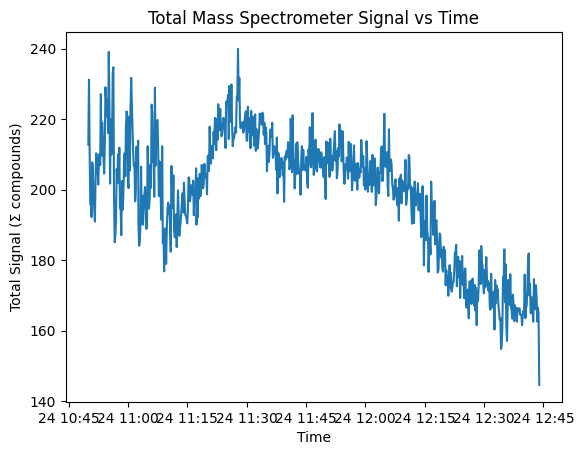

In [8]:
# Sum all compound signals at each time point
total_signal = df.select_dtypes(include='number').sum(axis=1)

# Time window
total_signal = total_signal.loc[
    "2025-02-24 10:50:00":"2025-02-24 12:44:00"
]

# Plot
plt.figure()
plt.plot(total_signal.index, total_signal.values)
plt.xlabel("Time")
plt.ylabel("Total Signal (Σ compounds)")
plt.title("Total Mass Spectrometer Signal vs Time")
plt.show()


In [9]:
# Define background window (first 20 minutes)
bg_df = df.loc[
    "2025-02-24 10:50:00":"2025-02-24 11:10:00"
]

# Keep only numeric compound columns
bg_df = bg_df.select_dtypes(include='number')

# Compute maximum value per compound during background period
bg_max = bg_df.max()

# Top 20 compounds contributing most strongly to background
top20_bg = bg_max.sort_values(ascending=False).head(20)

top20_bg


,0
C3H9O2+,36.245262
H5NO2+,16.502058
H7N2O+,10.405775
C5H5N+,10.239102
CH4NO+,9.665874
C3H10NO+,9.533158
C2H5O2+,7.867979
CH7O2+,7.658666
H2NO3+,7.027381
C6H17OSi2+,6.128052


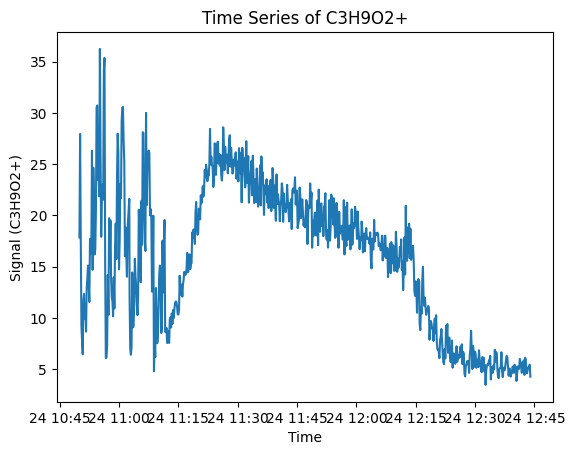

In [10]:
# Select the compound
compound = "C3H9O2+"

# Time window
compound_ts = df.loc[
    "2025-02-24 10:50:00":"2025-02-24 12:44:00",
    compound
]

# Plot
plt.figure()
plt.plot(compound_ts.index, compound_ts.values)
plt.xlabel("Time")
plt.ylabel("Signal (C3H9O2+)")
plt.title("Time Series of C3H9O2+")
plt.show()


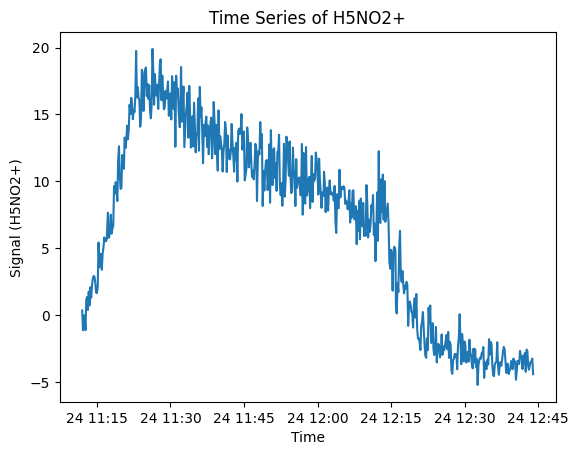

In [11]:

# Select the compound
compound = "C3H9O2+"

# Time window
compound_ts = HDV1Ma_df.loc[
    "2025-02-24 11:12:00":"2025-02-24 12:44:00",
    compound
]

# Plot
plt.figure()
plt.plot(compound_ts.index, compound_ts.values)
plt.xlabel("Time")
plt.ylabel("Signal (H5NO2+)")
plt.title("Time Series of H5NO2+")
plt.show()


## **HDV1 MILD REPEAT**

In [12]:
# Step 1: Split data into background and experiment time windows
HDV1Mb_background = df[(df.index >= "2025-02-27 09:58:00") & (df.index <= "2025-02-27 10:18:59")]
HDV1Mb_experiment = df[(df.index > "2025-02-27 10:19:00") & (df.index <= "2025-02-27 11:50:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Mb_background_mean = HDV1Mb_background.mean()

# Subtract background mean from both background and experiment data
HDV1Mb_background_subtracted = HDV1Mb_background.subtract(HDV1Mb_background_mean, axis='columns')
HDV1Mb_experiment_subtracted = HDV1Mb_experiment.subtract(HDV1Mb_background_mean, axis='columns')

# Merge the two dataframes
HDV1Mb_df = pd.concat([HDV1Mb_background_subtracted, HDV1Mb_experiment_subtracted])

#HDV1Mb_df.head()


## **HDV 2 MILD FIRST TEST**

In [13]:
# Step 1: Split data into background and experiment time windows
HDV2Ma_background = df[(df.index >= "2025-02-24 16:31:00") & (df.index <= "2025-02-24 16:51:59")]
HDV2Ma_experiment = df[(df.index > "2025-02-24 16:52:00") & (df.index <= "2025-02-24 18:12:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Ma_background_mean = HDV2Ma_background.mean()

# Subtract background mean from both background and experiment data
HDV2Ma_background_subtracted = HDV2Ma_background.subtract(HDV2Ma_background_mean, axis='columns')
HDV2Ma_experiment_subtracted = HDV2Ma_experiment.subtract(HDV2Ma_background_mean, axis='columns')

# Merge the two dataframes
HDV2Ma_df = pd.concat([HDV2Ma_background_subtracted, HDV2Ma_experiment_subtracted])

#HDV2Ma_df.head()

## **HDV2 MILD REPEAT**

In [14]:
# Step 1: Split data into background and experiment time windows
HDV2Mb_background = df[(df.index >= "2025-02-27 15:42:00") & (df.index <= "2025-02-27 16:03:59")]
HDV2Mb_experiment = df[(df.index > "2025-02-27 16:04:00") & (df.index <= "2025-02-27 17:34:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Mb_background_mean = HDV2Mb_background.mean()

# Subtract background mean from both background and experiment data
HDV2Mb_background_subtracted = HDV2Mb_background.subtract(HDV2Mb_background_mean, axis='columns')
HDV2Mb_experiment_subtracted = HDV2Mb_experiment.subtract(HDV2Mb_background_mean, axis='columns')

# Merge the two dataframes
HDV2Mb_df = pd.concat([HDV2Mb_background_subtracted, HDV2Mb_experiment_subtracted])

#HDV2Mb_df.head()


## **HDV1 MEDIUM FIRST TEST**

In [15]:
# Step 1: Split data into background and experiment time windows
HDV1La_background = df[(df.index >= "2025-02-11 10:56:00") & (df.index <= "2025-02-11 11:27:50")]
HDV1La_experiment = df[(df.index > "2025-02-11 11:28:00") & (df.index <= "2025-02-11 18:23:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1La_background_mean = HDV1La_background.mean()

# Subtract background mean from both background and experiment data
HDV1La_background_subtracted = HDV1La_background.subtract(HDV1La_background_mean, axis='columns')
HDV1La_experiment_subtracted = HDV1La_experiment.subtract(HDV1La_background_mean, axis='columns')

# Merge the two dataframes
HDV1La_df = pd.concat([HDV1La_background_subtracted, HDV1La_experiment_subtracted])

HDV1La_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-11 10:56:06,0.038016,0.063227,1.241037,0.002346,0.779395,0.518252,-0.125840,0.997913,0.024061,-0.040220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-11 10:56:16,0.020062,0.012551,-0.052823,0.325216,0.290511,-0.102633,0.136062,-0.129913,0.075951,0.089463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-11 10:56:26,0.127111,0.086338,0.168983,-0.106814,0.118630,0.043753,-0.107011,0.551886,-0.117202,1.028982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-11 10:56:36,-0.056478,-0.041678,0.505682,0.544458,0.110438,-0.415985,0.104611,-0.054233,0.166946,-0.052805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-11 10:56:46,-0.041162,0.108150,0.710515,0.069338,1.055849,0.679162,0.048569,-0.129877,-0.189581,0.551086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **HDV1 MEDIUM 2ND REPEAT**

In [16]:
# Step 1: Split data into background and experiment time windows
HDV1Lb_background = df[(df.index >= "2025-02-19 10:07:00") & (df.index <= "2025-02-19 10:33:50")]
HDV1Lb_experiment = df[(df.index > "2025-02-19 10:34:00") & (df.index <= "2025-02-19 17:08:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Lb_background_mean = HDV1Lb_background.mean()

# Subtract background mean from both background and experiment data
HDV1Lb_background_subtracted = HDV1Lb_background.subtract(HDV1Lb_background_mean, axis='columns')
HDV1Lb_experiment_subtracted = HDV1Lb_experiment.subtract(HDV1Lb_background_mean, axis='columns')

# Merge the two dataframes
HDV1Lb_df = pd.concat([HDV1Lb_background_subtracted, HDV1Lb_experiment_subtracted])

HDV1Lb_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-19 10:07:05,-0.037043,-0.058942,0.198677,0.542951,-0.391219,-1.200260,-0.200958,-0.515878,0.413495,0.812460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-19 10:07:15,-0.066215,-0.058258,0.297804,0.016440,-0.120376,-0.988341,-0.221853,-0.018516,0.170964,1.960323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-19 10:07:25,0.055655,0.018928,0.549750,-0.076116,0.417889,-0.487187,-0.017561,-0.010201,-0.238747,2.560827,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-19 10:07:35,-0.057725,0.143372,0.974990,-1.021178,-0.137507,0.383828,-0.014120,-0.766296,-0.108507,2.210184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-19 10:07:45,0.008969,-0.021295,0.858852,-0.163549,0.499848,-0.079165,-0.076667,0.273342,-0.054129,0.215541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **HDV1 MEDIUM 3RD REPEAT**

In [17]:
# Step 1: Split data into background and experiment time windows
HDV1Lc_background = df[(df.index >= "2025-02-06 10:14:00") & (df.index <= "2025-02-06 10:23:50")]
HDV1Lc_experiment = df[(df.index > "2025-02-06 10:24:00") & (df.index <= "2025-02-06 17:24:00")]
# Experiment was 1 hour; but some extra time afterwards is included to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Lc_background_mean = HDV1Lc_background.mean()

# Step 3: Subtract background mean from both background and experiment data
HDV1Lc_background_subtracted = HDV1Lc_background.subtract(HDV1Lc_background_mean, axis='columns')
HDV1Lc_experiment_subtracted = HDV1Lc_experiment.subtract(HDV1Lc_background_mean, axis='columns')

# Step 4: Merge the two dataframes
HDV1Lc_df = pd.concat([HDV1Lc_background_subtracted, HDV1Lc_experiment_subtracted])

HDV1Lc_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,0.131895,-0.081294,-0.101430,0.737645,0.200799,5.722333,0.034011,-0.231627,0.281640,-0.688478,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.040980,-0.068726,-0.300955,0.169562,2.679206,2.196388,-0.065446,0.304185,0.829880,0.807667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-0.039272,-0.079875,0.550204,0.042363,0.856917,2.005485,0.183585,0.215904,-0.264834,1.587870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.064829,0.219718,-0.093662,0.256715,-0.002950,1.273795,-0.114776,-0.505247,-0.146043,1.100427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,0.004664,-0.081294,0.195730,0.184738,0.317758,2.228563,-0.110793,0.439791,-0.297786,0.464405,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


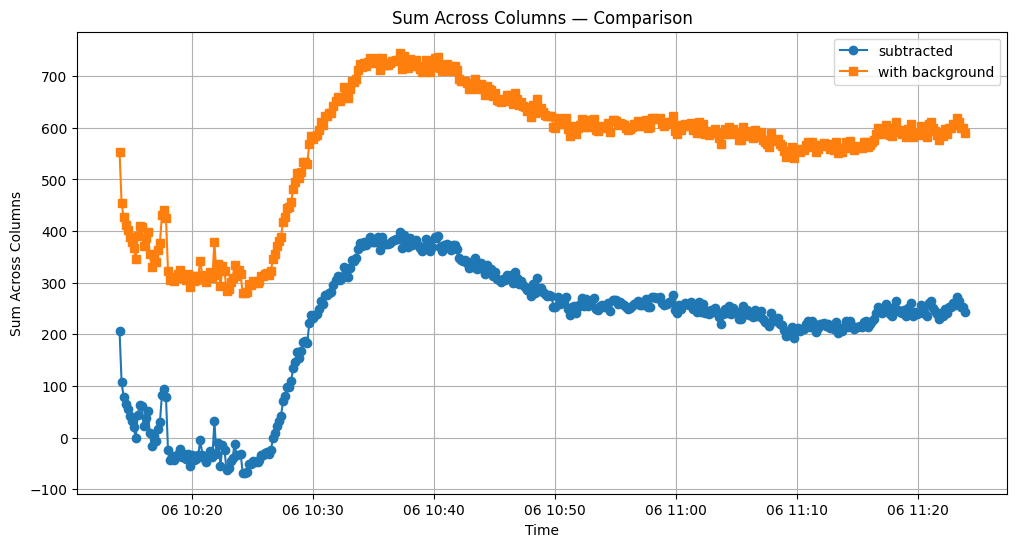

In [18]:
HDV1Lc_df.index = pd.to_datetime(HDV1Lc_df.index)
df.index = pd.to_datetime(df.index)   # ensure datetime index

# Sum across columns
ts_sum = HDV1Lc_df.sum(axis=1)
ts_sum_other = df.sum(axis=1)  # second dataframe

# Slice the desired time window
start_time = "2025-02-06 10:14:00"
end_time   = "2025-02-06 11:24:00"

ts_window       = ts_sum.loc[start_time:end_time]
ts_window_other = ts_sum_other.loc[start_time:end_time]

# Plot
plt.figure(figsize=(12,6))

plt.plot(ts_window.index, ts_window.values, marker="o", linestyle="-", label="subtracted")
plt.plot(ts_window_other.index, ts_window_other.values, marker="s", linestyle="-", label="with background")

plt.title("Sum Across Columns — Comparison")
plt.xlabel("Time")
plt.ylabel("Sum Across Columns")
plt.grid(True)
plt.legend()
plt.show()


df['C3H7O+'].loc['2025-02-06 09:20:00':'2025-02-06 11:24:00'].plot()

## **HDV2 MEDIUM FIRST TEST**

In [19]:

# Step 1: Split data into background and experiment time windows
HDV2La_background = df[(df.index >= "2025-02-12 10:35:00") & (df.index <= "2025-02-12 11:05:50")]
HDV2La_experiment = df[(df.index > "2025-02-12 11:06:00") & (df.index <= "2025-02-12 17:39:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2La_background_mean = HDV2La_background.mean()

# Subtract background mean from both background and experiment data
HDV2La_background_subtracted = HDV2La_background.subtract(HDV2La_background_mean, axis='columns')
HDV2La_experiment_subtracted = HDV2La_experiment.subtract(HDV2La_background_mean, axis='columns')

# Merge the two dataframes
HDV2La_df = pd.concat([HDV2La_background_subtracted, HDV2La_experiment_subtracted])

#HDV2La_df.head()


## **HDV2 MEDIUM SECOND REPEAT**

In [20]:
# Step 1: Split data into background and experiment time windows
HDV2Lb_background = df[(df.index >= "2025-02-13 11:26:00") & (df.index <= "2025-02-13 11:56:50")]
HDV2Lb_experiment = df[(df.index > "2025-02-13 11:57:00") & (df.index <= "2025-02-13 18:30:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Lb_background_mean = HDV2Lb_background.mean()

# Subtract background mean from both background and experiment data
HDV2Lb_background_subtracted = HDV2Lb_background.subtract(HDV2Lb_background_mean, axis='columns')
HDV2Lb_experiment_subtracted = HDV2Lb_experiment.subtract(HDV2Lb_background_mean, axis='columns')

# Merge the two dataframes
HDV2Lb_df = pd.concat([HDV2Lb_background_subtracted, HDV2Lb_experiment_subtracted])

#HDV2Lb_df.head()


## **HDV2 MEDIUM THIRD REPEAT**


In [21]:
# Step 1: Split data into background and experiment time windows
HDV2Lc_background = df[(df.index >= "2025-02-18 10:43:00") & (df.index <= "2025-02-18 10:53:00")]
HDV2Lc_experiment = df[(df.index > "2025-02-18 10:53:50") & (df.index <= "2025-02-18 17:08:00")]
# Experiment was 1 hour; but some extra time afterwards is included to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Lc_background_mean = HDV2Lc_background.mean()

# Step 3: Subtract background mean from both background and experiment data
HDV2Lc_background_subtracted = HDV2Lc_background.subtract(HDV2Lc_background_mean, axis='columns')
HDV2Lc_experiment_subtracted = HDV2Lc_experiment.subtract(HDV2Lc_background_mean, axis='columns')

# Step 4: Merge the two dataframes
HDV2Lc_df = pd.concat([HDV2Lc_background_subtracted, HDV2Lc_experiment_subtracted])

HDV2Lc_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-18 10:43:08,0.002510,-0.062753,-0.405154,0.757751,-0.073798,3.131910,-0.098023,-0.322742,0.000356,-1.020002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-18 10:43:18,0.033253,0.115323,0.229393,0.319818,-0.330118,2.791206,0.409709,-0.074172,0.066637,-0.417806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-18 10:43:28,-0.016911,0.022414,0.784742,1.159989,-0.390542,7.441288,-0.081826,-0.301918,0.262919,-1.491869,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-18 10:43:38,-0.042742,-0.056561,0.840512,-0.264398,0.018147,6.936700,0.294158,-0.014144,0.097320,1.028037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-18 10:43:48,0.014030,0.021645,-0.740543,-0.242345,-0.346251,11.748865,0.277532,0.151130,-0.096840,0.109475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## **HDV1 HARSH FIRST TEST**

In [22]:
# Step 1: Split data into background and experiment time windows
HDV1Ha_background = df[(df.index >= "2025-02-25 09:20:00") & (df.index <= "2025-02-25 09:41:49")]
HDV1Ha_experiment = df[(df.index > "2025-02-25 09:42:50") & (df.index <= "2025-02-25 11:03:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Ha_background_mean = HDV1Ha_background.mean()

# Subtract background mean from both background and experiment data
HDV1Ha_background_subtracted = HDV1Ha_background.subtract(HDV1Ha_background_mean, axis='columns')
HDV1Ha_experiment_subtracted = HDV1Ha_experiment.subtract(HDV1Ha_background_mean, axis='columns')

# Merge the two dataframes
HDV1Ha_df = pd.concat([HDV1Ha_background_subtracted, HDV1Ha_experiment_subtracted])

#HDV1Ha_df.head()


## **HDV1 HARSH REPEAT**

In [23]:
# Step 1: Split data into background and experiment time windows
HDV1Hb_background = df[(df.index >= "2025-03-04 09:45:00") & (df.index <= "2025-03-04 10:06:00")]
HDV1Hb_experiment = df[(df.index > "2025-03-04 10:06:35") & (df.index <= "2025-03-04 11:37:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV1Hb_background_mean = HDV1Hb_background.mean()

# Subtract background mean from both background and experiment data
HDV1Hb_background_subtracted = HDV1Hb_background.subtract(HDV1Hb_background_mean, axis='columns')
HDV1Hb_experiment_subtracted = HDV1Hb_experiment.subtract(HDV1Hb_background_mean, axis='columns')

# Merge the two dataframes
HDV1Hb_df = pd.concat([HDV1Hb_background_subtracted, HDV1Hb_experiment_subtracted])

#HDV1Hb_df.head()



## **HDV2 HARSH FIRST TEST**

In [24]:
# Step 1: Split data into background and experiment time windows
HDV2Ha_background = df[(df.index >= "2025-02-25 14:54:00") & (df.index <= "2025-02-25 15:24:59")]
HDV2Ha_experiment = df[(df.index > "2025-02-25 15:25:00") & (df.index <= "2025-02-25 16:55:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Ha_background_mean = HDV2Ha_background.mean()

# Subtract background mean from both background and experiment data
HDV2Ha_background_subtracted = HDV2Ha_background.subtract(HDV2Ha_background_mean, axis='columns')
HDV2Ha_experiment_subtracted = HDV2Ha_experiment.subtract(HDV2Ha_background_mean, axis='columns')

# Merge the two dataframes
HDV2Ha_df = pd.concat([HDV2Ha_background_subtracted, HDV2Ha_experiment_subtracted])

#HDV2Ha_df.head()


## **HDV2 HARSH REPEAT**

In [25]:
# Step 1: Split data into background and experiment time windows
HDV2Hb_background = df[(df.index >= "2025-03-04 15:44:00") & (df.index <= "2025-03-04 16:04:59")]
HDV2Hb_experiment = df[(df.index > "2025-03-04 16:05:00") & (df.index <= "2025-03-04 17:35:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
HDV2Hb_background_mean = HDV2Hb_background.mean()

# Subtract background mean from both background and experiment data
HDV2Hb_background_subtracted = HDV2Hb_background.subtract(HDV2Hb_background_mean, axis='columns')
HDV2Hb_experiment_subtracted = HDV2Hb_experiment.subtract(HDV2Hb_background_mean, axis='columns')

# Merge the two dataframes
HDV2Hb_df = pd.concat([HDV2Hb_background_subtracted, HDV2Hb_experiment_subtracted])

#HDV2Hb_df.head()


## **LDV**

## **LDV1 FIRST**

In [26]:
LDV1La_background = df[(df.index >= "2025-03-10 11:20:00") & (df.index <= "2025-03-10 11:46:00")]
LDV1La_experiment = df[(df.index > "2025-03-10 11:46:15") & (df.index <= "2025-03-10 18:18:00")]

LDV1La_background_mean = LDV1La_background.mean()

LDV1La_background_subtracted = LDV1La_background.subtract(LDV1La_background_mean, axis='columns')
LDV1La_experiment_subtracted = LDV1La_experiment.subtract(LDV1La_background_mean, axis='columns')

LDV1La_df = pd.concat([LDV1La_background_subtracted, LDV1La_experiment_subtracted])

LDV1La_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-03-10 11:20:07,NaN,NaN,NaN,0.313277,0.089672,0.058082,-0.202881,0.000357,0.393494,1.430423,...,-0.031986,0.224845,0.065262,-0.024151,0.073714,-0.045148,0.010393,-0.132777,-0.033833,-0.033423
2025-03-10 11:20:17,NaN,NaN,NaN,0.062040,0.048462,-0.024914,-0.068169,-0.525155,0.364839,0.416849,...,-0.049954,-0.118393,-0.027281,-0.021395,0.037792,-0.134005,0.041316,-0.015206,0.150463,-0.032578
2025-03-10 11:20:27,NaN,NaN,NaN,-0.744222,-0.155690,0.687401,-0.053935,-0.151209,-0.009752,0.334142,...,-0.099060,-0.198588,0.083188,-0.024151,-0.093947,0.120819,-0.055569,0.033920,-0.019074,0.074505
2025-03-10 11:20:37,NaN,NaN,NaN,0.061273,-0.012886,0.749977,-0.181902,0.204480,-0.173642,2.500920,...,-0.053375,0.307015,0.006966,-0.024151,0.466609,0.069089,-0.055569,-0.019580,-0.033833,0.020311
2025-03-10 11:20:47,NaN,NaN,NaN,0.454264,-0.076026,-0.201258,-0.195491,-0.287273,0.146420,-0.401319,...,-0.002221,0.015131,-0.027281,-0.024151,0.023776,-0.045496,-0.055569,0.029475,-0.033833,0.028295


## **LDV1 REPEAT**

In [27]:
# Step 1: Split data into background and experiment time windows
LDV1Lb_background = df[(df.index >= "2025-03-11 10:10:00") & (df.index <= "2025-03-11 10:34:00")]
LDV1Lb_experiment = df[(df.index > "2025-03-11 10:34:05") & (df.index <= "2025-03-11 16:56:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
LDV1Lb_background_mean = LDV1Lb_background.mean()

# Subtract background mean from both background and experiment data
LDV1Lb_background_subtracted = LDV1Lb_background.subtract(LDV1Lb_background_mean, axis='columns')
LDV1Lb_experiment_subtracted = LDV1Lb_experiment.subtract(LDV1Lb_background_mean, axis='columns')

# Merge the two dataframes
LDV1Lb_df = pd.concat([LDV1Lb_background_subtracted, LDV1Lb_experiment_subtracted])

# Display the first few rows
LDV1Lb_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-03-11 10:10:04,NaN,NaN,NaN,-0.182259,-0.166895,-0.516260,0.322170,0.374090,0.085917,0.129904,...,-0.050202,0.053343,0.005816,-0.024503,0.008537,-0.058953,0.042030,-0.048879,-0.038686,-0.025774
2025-03-11 10:10:14,NaN,NaN,NaN,-0.026345,-0.276728,0.430768,-0.184939,-0.113653,-0.010003,0.262852,...,0.153641,-0.218916,-0.036389,0.153428,0.046494,-0.009744,-0.024184,0.004864,0.098214,-0.025774
2025-03-11 10:10:24,NaN,NaN,NaN,-0.166397,-0.054086,-0.138724,-0.177239,-0.123323,0.016503,-0.154059,...,-0.070465,-0.137863,0.003833,-0.024503,-0.063334,0.145310,0.027053,-0.144427,0.133257,-0.025774
2025-03-11 10:10:34,NaN,NaN,NaN,0.116166,0.056024,0.335157,-0.180225,0.004573,-0.045946,-0.719793,...,0.172352,-0.074237,0.002473,-0.024503,0.084314,-0.062392,-0.026537,0.053661,-0.039785,-0.014031
2025-03-11 10:10:44,NaN,NaN,NaN,-0.294204,-0.031728,0.474640,-0.069276,0.060605,-0.019580,-1.103804,...,-0.107609,0.188488,-0.036389,-0.008246,-0.040094,0.073973,0.013381,0.013597,-0.000597,0.021557


## **LDV2 FIRST**

In [28]:
# Step 1: Split data into background and experiment time windows
LDV2La_background = df[(df.index >= "2025-03-31 09:50:00") & (df.index <= "2025-03-31 10:14:00")]
LDV2La_experiment = df[(df.index > "2025-03-31 10:14:50") & (df.index <= "2025-03-31 16:50:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
LDV2La_background_mean = LDV2La_background.mean()

# Subtract background mean from both background and experiment data
LDV2La_background_subtracted = LDV2La_background.subtract(LDV2La_background_mean, axis='columns')
LDV2La_experiment_subtracted = LDV2La_experiment.subtract(LDV2La_background_mean, axis='columns')

# Merge the two dataframes
LDV2La_df = pd.concat([LDV2La_background_subtracted, LDV2La_experiment_subtracted])

# Display the first few rows
#LDV2La_df.head()


## **LDV2 REPEAT**

In [29]:
# Step 1: Split data into background and experiment time windows
LDV2Lb_background = df[(df.index >= "2025-04-01 10:00:00") & (df.index <= "2025-04-01 10:25:00")]
LDV2Lb_experiment = df[(df.index > "2025-04-01 10:25:05") & (df.index <= "2025-04-01 16:56:00")]
# Experiment was 1 hour; but I add some time afterwards as post experiments to see how VOCs drop

# Step 2: Compute mean background value for each compound (column)
LDV2Lb_background_mean = LDV2Lb_background.mean()

# Subtract background mean from both background and experiment data
LDV2Lb_background_subtracted = LDV2Lb_background.subtract(LDV2Lb_background_mean, axis='columns')
LDV2Lb_experiment_subtracted = LDV2Lb_experiment.subtract(LDV2Lb_background_mean, axis='columns')

# Merge the two dataframes
LDV2Lb_df = pd.concat([LDV2Lb_background_subtracted, LDV2Lb_experiment_subtracted])

# Display the first few rows
#LDV2Lb_df.head()


## **COMBINED HDV 1&2 MILD, MEDIUM AND HARSH**

In [30]:
# Concatenate the DataFrames and sort by the datetime index
comb_HDV_df = pd.concat([HDV1La_df, HDV2La_df, HDV1Lb_df, HDV2Lb_df, HDV1Lc_df, HDV2Lc_df,
                         HDV1Ma_df, HDV2Ma_df, HDV1Ha_df, HDV2Ha_df, HDV1Mb_df, HDV2Mb_df,
                         HDV1Hb_df, HDV2Hb_df])

# Sort the combined DataFrame by its index (time)
comb_HDV_df = comb_HDV_df.sort_index()

# Display the first few rows of the combined DataFrame
comb_HDV_df.head()


,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,0.131895,-0.081294,-0.101430,0.737645,0.200799,5.722333,0.034011,-0.231627,0.281640,-0.688478,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.040980,-0.068726,-0.300955,0.169562,2.679206,2.196388,-0.065446,0.304185,0.829880,0.807667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-0.039272,-0.079875,0.550204,0.042363,0.856917,2.005485,0.183585,0.215904,-0.264834,1.587870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.064829,0.219718,-0.093662,0.256715,-0.002950,1.273795,-0.114776,-0.505247,-0.146043,1.100427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,0.004664,-0.081294,0.195730,0.184738,0.317758,2.228563,-0.110793,0.439791,-0.297786,0.464405,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **COMBINED LDV1 MEDIUM**

we combine LDV 1 and 2 separately since we shall apply differeny calibration results on them. LDV1 with calibration 1 and LDV2 with calibration 2. This is because they were done close to these calibrations more so with a SIS performed in between, meaning the voltage was stepped up

In [31]:
# Concatenate the DataFrames
comb_LDV1_df = pd.concat([LDV1La_df, LDV1Lb_df])
comb_LDV1_df.index = pd.to_datetime(comb_LDV1_df.index)

comb_LDV1_df = comb_LDV1_df.sort_index()

# Display the first few rows of the combined DataFrame
comb_LDV1_df.head()

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-03-10 11:20:07,NaN,NaN,NaN,0.313277,0.089672,0.058082,-0.202881,0.000357,0.393494,1.430423,...,-0.031986,0.224845,0.065262,-0.024151,0.073714,-0.045148,0.010393,-0.132777,-0.033833,-0.033423
2025-03-10 11:20:17,NaN,NaN,NaN,0.062040,0.048462,-0.024914,-0.068169,-0.525155,0.364839,0.416849,...,-0.049954,-0.118393,-0.027281,-0.021395,0.037792,-0.134005,0.041316,-0.015206,0.150463,-0.032578
2025-03-10 11:20:27,NaN,NaN,NaN,-0.744222,-0.155690,0.687401,-0.053935,-0.151209,-0.009752,0.334142,...,-0.099060,-0.198588,0.083188,-0.024151,-0.093947,0.120819,-0.055569,0.033920,-0.019074,0.074505
2025-03-10 11:20:37,NaN,NaN,NaN,0.061273,-0.012886,0.749977,-0.181902,0.204480,-0.173642,2.500920,...,-0.053375,0.307015,0.006966,-0.024151,0.466609,0.069089,-0.055569,-0.019580,-0.033833,0.020311
2025-03-10 11:20:47,NaN,NaN,NaN,0.454264,-0.076026,-0.201258,-0.195491,-0.287273,0.146420,-0.401319,...,-0.002221,0.015131,-0.027281,-0.024151,0.023776,-0.045496,-0.055569,0.029475,-0.033833,0.028295


## **COMBINED LDV 2 MEDIUM**

In [32]:
# Concatenate the DataFrames
comb_LDV2_df = pd.concat([LDV2La_df, LDV2Lb_df])
comb_LDV2_df.index = pd.to_datetime(comb_LDV2_df.index)

comb_LDV2_df = comb_LDV2_df.sort_index()

# Display the first few rows of the combined DataFrame
comb_LDV2_df.tail()

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-04-01 16:55:19,NaN,NaN,NaN,0.133847,-0.522818,1.061380,-0.112815,-0.017008,-0.017953,-1.115131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:29,NaN,NaN,NaN,0.057411,-0.040305,1.484410,0.087880,0.283418,0.066671,-0.768446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:39,NaN,NaN,NaN,-0.019225,-0.151258,1.058597,0.288467,-0.415097,-0.198369,-0.749410,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:49,NaN,NaN,NaN,-0.511337,-0.031769,1.051179,0.099532,0.381423,-0.020480,0.665283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:59,NaN,NaN,NaN,0.222665,-0.256013,0.674301,0.007897,0.267652,0.010101,0.271364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **VOC VOLUME MIXING RATIOS  FROM KPTR AND TRANSMISSION CURVES**

The sensitivity of R, Sexp(kPTR) (in cps/ppbv) is defined as the number of ions produced per unit mixing ratio of the trace gas, as described by equation below

$$
S_{\mathrm{exp}}\left(k_{\mathrm{PTR}}\right) = \frac{\left[\mathrm{RH}^{+}\right]}{\left[R\right]} = \left[\mathrm{H}_3\mathrm{O}^{+}\right]_0 \times k_{\mathrm{PTR}} \times t
$$

From a plot of measured sensitivity Vs kPTR, the expected sensitivity is the product of the above equation.  
y=mx + c implies that sensitivity = slope x kPTR + y-intercept

## **HDV1, HDV2 and LDV1**

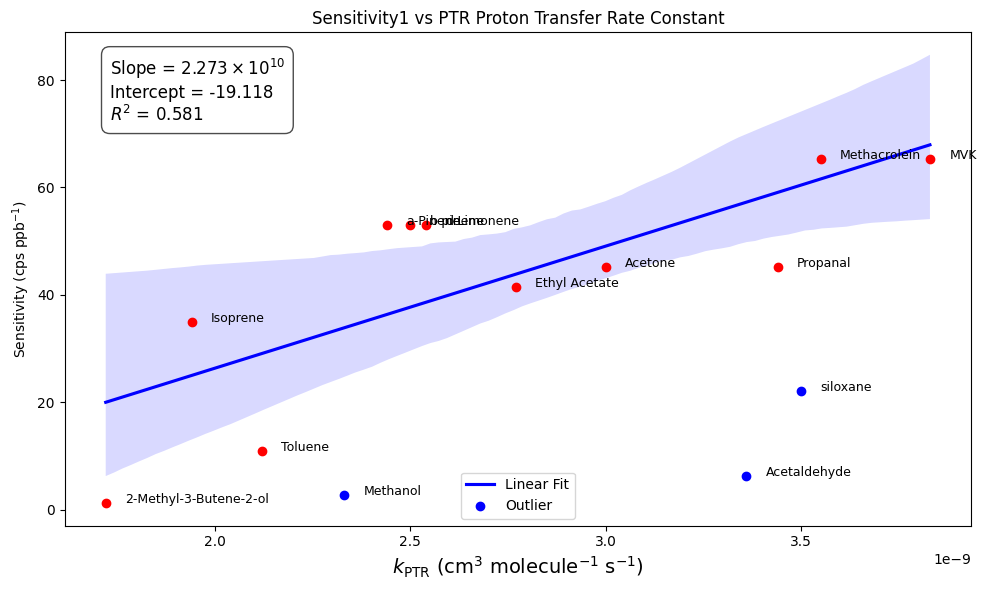

Figure above shows the correlation between the measured sensitivities and their proton transfer rate coefficients.  By using the VOC standards from the has cylinder, we established the relationship between sensitivity and proton transfer rate coefficients, which was used to calculate the sensitivity of other compounds whose standards were unavailable.
From the above graph, the Sensitivity expected  = 74 cps/ppbv



The equation below, incorporating the instrument's transmission function, can be used to estimate the sensitivity of different compounds

$$
S_{\mathrm{est}} = S_{\mathrm{exp}}\left(k_{\mathrm{PTR}}\right) \times T\left(\frac{m}{Q}\right)
$$

Here, we shall assume an average of expected sensitivity of 72 cps/ppbv and a mass dependent transmission of 1.0

In [33]:
# Expected sensitivity from the correlation plot
#S_exp_kPTR = 31.738870010985423  # cps/ppbv: from calibration 2
S_exp_kPTR_HDV = 17.90296299313625 #From calibration 1

# Mass dependent transmission (from trnamission curve)
T_m_Q = 1.0

# Estimated sensitivity
S_est = S_exp_kPTR_HDV * T_m_Q

print(f"Estimated Sensitivity (S_est): {S_est} cps/ppbv")

Estimated Sensitivity (S_est): 17.90296299313625 cps/ppbv


In [34]:
# Calculate VMR for HDV1_df by dividing by the estimated sensitivity
VMR_HDVT_df = comb_HDV_df / S_est
VMR_HDVT_df.head()

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,0.007367,-0.004541,-0.005666,0.041202,0.011216,0.319630,0.001900,-0.012938,0.015731,-0.038456,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.002289,-0.003839,-0.016810,0.009471,0.149652,0.122683,-0.003656,0.016991,0.046354,0.045114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-0.002194,-0.004462,0.030733,0.002366,0.047865,0.112020,0.010254,0.012060,-0.014793,0.088693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.003621,0.012273,-0.005232,0.014339,-0.000165,0.071150,-0.006411,-0.028221,-0.008157,0.061466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,0.000261,-0.004541,0.010933,0.010319,0.017749,0.124480,-0.006189,0.024565,-0.016633,0.025940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **LDV 1**

In [35]:
# Expected sensitivity from the correlation plot
#S_exp_kPTR = 31.738870010985423  # cps/ppbv: from calibration 2
S_exp_kPTR_LDV = 17.90296299313625  #From calibration 1

# Mass dependent transmission (from trnamission curve)
T_m_Q = 1.0

# Estimated sensitivity
S_est = S_exp_kPTR_LDV * T_m_Q

print(f"Estimated Sensitivity (S_est): {S_est} cps/ppbv")

Estimated Sensitivity (S_est): 17.90296299313625 cps/ppbv


In [36]:
# Calculate VMR for LDV1_df by dividing by the estimated sensitivity
VMR_LDV1T_df = comb_LDV1_df / S_est
VMR_LDV1T_df.head()

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-03-10 11:20:07,NaN,NaN,NaN,0.017499,0.005009,0.003244,-0.011332,0.000020,0.021979,0.079899,...,-0.001787,0.012559,0.003645,-0.001349,0.004117,-0.002522,0.000581,-0.007416,-0.001890,-0.001867
2025-03-10 11:20:17,NaN,NaN,NaN,0.003465,0.002707,-0.001392,-0.003808,-0.029333,0.020379,0.023284,...,-0.002790,-0.006613,-0.001524,-0.001195,0.002111,-0.007485,0.002308,-0.000849,0.008404,-0.001820
2025-03-10 11:20:27,NaN,NaN,NaN,-0.041570,-0.008696,0.038396,-0.003013,-0.008446,-0.000545,0.018664,...,-0.005533,-0.011092,0.004647,-0.001349,-0.005248,0.006749,-0.003104,0.001895,-0.001065,0.004162
2025-03-10 11:20:37,NaN,NaN,NaN,0.003423,-0.000720,0.041891,-0.010160,0.011422,-0.009699,0.139693,...,-0.002981,0.017149,0.000389,-0.001349,0.026063,0.003859,-0.003104,-0.001094,-0.001890,0.001134
2025-03-10 11:20:47,NaN,NaN,NaN,0.025374,-0.004247,-0.011242,-0.010919,-0.016046,0.008179,-0.022416,...,-0.000124,0.000845,-0.001524,-0.001349,0.001328,-0.002541,-0.003104,0.001646,-0.001890,0.001580


## **LDV 2**

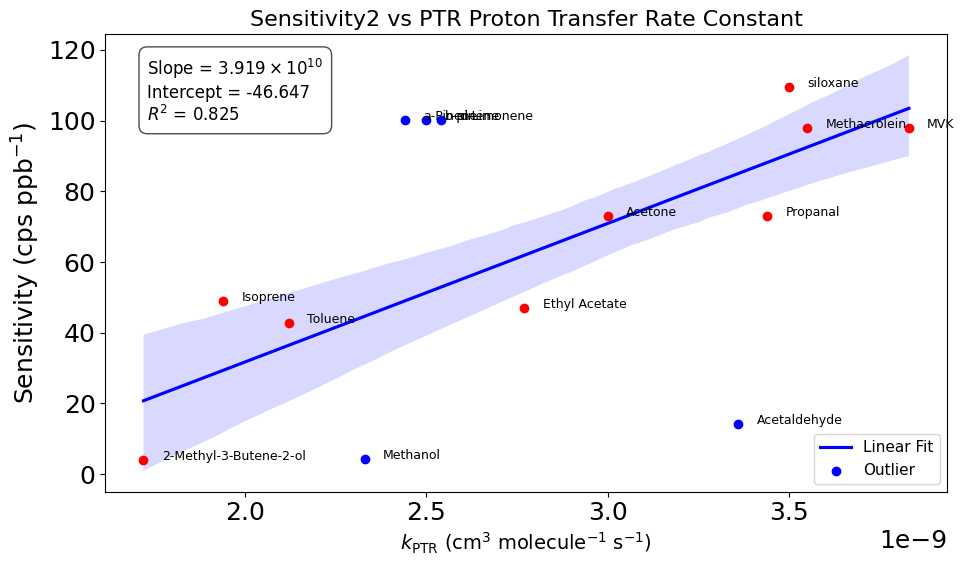

In [37]:
# Expected sensitivity from the correlation plot
#S_exp_kPTR = 31.738870010985423  # cps/ppbv: from calibration 2
S_exp_kPTR_LDV2 = 31.738870010985423  #cps/ppbv: from calibration 2

# Mass dependent transmission (from trnamission curve)
T_m_Q = 1.0

# Estimated sensitivity
S_est_LDV2 = S_exp_kPTR_LDV2 * T_m_Q

print(f"Estimated Sensitivity (S_est): {S_est_LDV2} cps/ppbv")

Estimated Sensitivity (S_est): 31.738870010985423 cps/ppbv


In [38]:
# Calculate VMR for HDV1_df by dividing by the estimated sensitivity
VMR_LDV2T_df = comb_LDV2_df / S_est_LDV2
VMR_LDV2T_df.tail()

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-04-01 16:55:19,NaN,NaN,NaN,0.004217,-0.016472,0.033441,-0.003554,-0.000536,-0.000566,-0.035135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:29,NaN,NaN,NaN,0.001809,-0.001270,0.046769,0.002769,0.008930,0.002101,-0.024212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:39,NaN,NaN,NaN,-0.000606,-0.004766,0.033353,0.009089,-0.013079,-0.006250,-0.023612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:49,NaN,NaN,NaN,-0.016111,-0.001001,0.033120,0.003136,0.012018,-0.000645,0.020961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:59,NaN,NaN,NaN,0.007016,-0.008066,0.021245,0.000249,0.008433,0.000318,0.008550,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **COMBINE VMR FOR HDV & LDV**

In [39]:

# Concatenate row-wise, keeping all columns
VMR_HDV_df = pd.concat([VMR_HDVT_df, VMR_LDV1T_df, VMR_LDV2T_df], axis=0)

# If the time column is the index, you may want to sort it:
VMR_HDV_df = VMR_HDV_df.sort_index()

VMR_HDV_df

,CH2N+,C2H4+,CH5O+,C3H5+,C2H4N+,C2H3O+,C3H7+,C2H4O+,C2H6N+,CH4NO+,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H18+,C5H18N7+,C8H8N3O2+,C4H16N7O+
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,0.007367,-0.004541,-0.005666,0.041202,0.011216,0.319630,0.001900,-0.012938,0.015731,-0.038456,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.002289,-0.003839,-0.016810,0.009471,0.149652,0.122683,-0.003656,0.016991,0.046354,0.045114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-0.002194,-0.004462,0.030733,0.002366,0.047865,0.112020,0.010254,0.012060,-0.014793,0.088693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.003621,0.012273,-0.005232,0.014339,-0.000165,0.071150,-0.006411,-0.028221,-0.008157,0.061466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,0.000261,-0.004541,0.010933,0.010319,0.017749,0.124480,-0.006189,0.024565,-0.016633,0.025940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01 16:55:19,NaN,NaN,NaN,0.004217,-0.016472,0.033441,-0.003554,-0.000536,-0.000566,-0.035135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:29,NaN,NaN,NaN,0.001809,-0.001270,0.046769,0.002769,0.008930,0.002101,-0.024212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 16:55:39,NaN,NaN,NaN,-0.000606,-0.004766,0.033353,0.009089,-0.013079,-0.006250,-0.023612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **TEMPERATURE DATA & COOL PLOTS TEMPERATURE**

**TC Pin was not connected, but it was left inside the tribometer chamber, so we use it to represent air temperature inside the chamber. TC Disc was the one used to record the temperature at the disc-pin interface!**

**Note: To plot the temperature data against the actual time of day, the
experimental logbook (provided in Excel format) is required. The thermocouple
data contain elapsed time(in seconds) rather than the actual time of day. Therefore, the
logbook must be used to identify the exact time when the sliding contact
between the pin and disc started. This time may differ from the thermocouple
recording start time, as the thermocouple could have started recording before
the tribometer was running and the pindisc contact was established**

## **HDV1 MILD CONDITIONS**

In [40]:
HDV1_MTemp_raw = pd.read_csv(
    "/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test53_HDV1_Mild.txt",
    sep='\t', skiprows=7, header=None
)

# Rename columns
HDV1_MTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 2, 2025 at 12:01:00 PM, 1-second intervals
start_time = pd.to_datetime("2025-04-02 12:01:00")
time_index = pd.date_range(start=start_time, periods=len(HDV1_MTemp_raw), freq='s')

# Assign as index
HDV1_MTemp_raw.index = time_index
HDV1_MTemp_raw.index.name = "Time"

# Define the filter start time

# Correct filtering — keep all rows where index >= 12:04:00
filter_start = pd.to_datetime("2025-04-02 12:03:30")
HDV1_MTemp = HDV1_MTemp_raw.loc[filter_start:]


# Display first few rows of the filtered DataFrame
#HDV1_MTemp.head()


## **HDV2 MILD CONDITIONS**

In [41]:
HDV2_MTemp_raw = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test55_HDV2_Mild.txt", sep='\t', skiprows=7, header=None)

# Rename columns
HDV2_MTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 2, 2025 at 12:01:00 PM, 1-second intervals
start_time = pd.to_datetime("2025-04-04 08:37:51")
time_index = pd.date_range(start=start_time, periods=len(HDV2_MTemp_raw), freq='s')

# Assign as index
HDV2_MTemp_raw.index = time_index
HDV2_MTemp_raw.index.name = "Time"

# Define the filter start time
#filter_start = pd.to_datetime("2025-04-04 08:38:00")

# Filter HDV2_MTemp_raw to start from 12:04:00
#HDV2_MTemp = HDV2_MTemp_raw.loc[filter_start:]
HDV2_MTemp = HDV2_MTemp_raw[HDV2_MTemp_raw.index >= pd.to_datetime("2025-04-04 08:38:00")]

# Display first few rows of the filtered DataFrame
#HDV2_MTemp.head()


## **HDV1 MEDIUM CONDITIONS**
Test 52: 2 m/s, 1 MPa  

In [42]:
## Read the file, skip metadata, no headers
HDV1_LTemp_raw = pd.read_csv(
    "/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test52_HDV1_Low2h.txt",
    sep='\t',
    skiprows=7,
    header=None
)

# Rename columns
HDV1_LTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 2, 2025 at 14:03:07, 1-second intervals
start_time = pd.to_datetime("2025-03-28 14:21:00")
time_index = pd.date_range(start=start_time, periods=len(HDV1_LTemp_raw), freq='s')

# Assign as index
HDV1_LTemp_raw.index = time_index
HDV1_LTemp_raw.index.name = "Time"

# Define the filter start time
filter_start = pd.to_datetime("2025-03-28 14:39:30")

# Filter HDV1_LTemp to start from 14:03:00
HDV1_LTemp = HDV1_LTemp_raw.loc[filter_start:]

# Display first few rows of the filtered DataFrame
HDV1_LTemp.head()


,TC Pin,TC Disc
Time,,
2025-03-28 14:39:30,25.61766,26.16281
2025-03-28 14:39:31,25.62422,26.31280
2025-03-28 14:39:32,25.63466,26.45840
2025-03-28 14:39:33,25.61893,26.64080
2025-03-28 14:39:34,25.60732,26.82752


## **HDV2 MEDIUM CONDITIONS**
Test 57: 2 m/s, 1 MPa  

In [43]:
# Read the file, skip metadata, no headers
HDV2_LTemp_raw = pd.read_csv(
    "/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test57_HDV2_Low2h.txt",
    sep='\t',
    skiprows=7,
    header=None
)

# Rename columns
HDV2_LTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from March 28, 2025 at 14:21:00, 1-second intervals
start_time = pd.to_datetime("2025-04-04 14:27:51")
time_index = pd.date_range(start=start_time, periods=len(HDV2_LTemp_raw), freq='s')

# Assign as index
HDV2_LTemp_raw.index = time_index
HDV2_LTemp_raw.index.name = "Time"

# Define the filter start time
filter_start = pd.to_datetime("2025-04-04 14:30:00")

# Filter HDV2_LTemp to start from 14:21:00
HDV2_LTemp = HDV2_LTemp_raw.loc[filter_start:]

# Display first few rows of the filtered DataFrame
#HDV2_LTemp.head()


## **HDV1 HARSH CONDITIONS**
Test 54: 2.5 m/s, 1.5 MPa  

In [44]:
# Read the file, skip metadata, no headers
HDV1_HTemp_raw = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test54_HDV1_Harsh.txt", sep='\t', skiprows=7, header=None)

# Rename columns
HDV1_HTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 2, 2025 at 14:03:10, 1-second intervals
start_time = pd.to_datetime("2025-04-02 14:03:07")
time_index = pd.date_range(start=start_time, periods=len(HDV1_HTemp_raw), freq='s')

# Assign as index
HDV1_HTemp_raw.index = time_index
HDV1_HTemp_raw.index.name = "Time"

# Define the filter start time
#filter_start = pd.to_datetime("2025-04-02 14:03:00")

# Filter HDV1_MTemp to start from 12:04:00
HDV1_HTemp = HDV1_HTemp_raw.loc[filter_start:]
HDV1_HTemp = HDV1_HTemp_raw[HDV1_HTemp_raw.index >= pd.to_datetime("2025-04-02 14:03:00")]

# Display first few rows of the filtered DataFrame
#HDV1_HTemp.head()



## **HDV2 HARSH CONDITIONS**
Test 56: 2.5 m/s, 1.5 MPa

In [45]:
HDV2_HTemp_raw = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test56_HDV2_Harsh.txt", sep='\t', skiprows=7, header=None)

# Rename columns
HDV2_HTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 4, 2025 at 10:46:00 AM, 1-second intervals
start_time = pd.to_datetime("2025-04-04 10:44:11")
time_index = pd.date_range(start=start_time, periods=len(HDV2_HTemp_raw), freq='s')

# Assign as index
HDV2_HTemp_raw.index = time_index
HDV2_HTemp_raw.index.name = "Time"


# Filter HDV1_MTemp to start from 12:04:00
#HDV2_HTemp = HDV2_HTemp_raw.loc[filter_start:]
#HDV2_HTemp = HDV2_HTemp_raw[HDV2_HTemp_raw.index >= pd.to_datetime("2025-04-04 10:45:00")]

# Display first few rows of the filtered DataFrame
#HDV2_HTemp.head()

# Correct filtering — keep all rows where index >= 12:04:00
filter_start = pd.to_datetime("2025-04-04 10:47:30")
HDV2_HTemp = HDV2_HTemp_raw.loc[filter_start:]


# Display first few rows of the filtered DataFrame
#HDV2_HTemp.head()

## **LDV1 MEDIUM CONDITIONS**
Test 58: 2 m/s, 1 MPa  

In [46]:
# Read the file, skip metadata, no headers
LDV1_LTemp_raw = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test58_LDV1_Low2h.txt", sep='\t', skiprows=7, header=None)

# Rename columns
LDV1_LTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 2, 2025 at 14:03:10, 1-second intervals
start_time = pd.to_datetime("2025-04-07 10:26:31")
time_index = pd.date_range(start=start_time, periods=len(LDV1_LTemp_raw), freq='s')

# Assign as index
LDV1_LTemp_raw.index = time_index
LDV1_LTemp_raw.index.name = "Time"

# Define the filter start time
filter_start = pd.to_datetime("2025-04-07 10:30:00")

# Filter LDV1_LTemp to start from 14:03:10
LDV1_LTemp = LDV1_LTemp_raw.loc[filter_start:]

# Display first few rows of the filtered DataFrame
#LDV1_LTemp.head()


## **LDV2 MEDIUM CONDITIONS**
Test 60: 2 m/s, 1 MPa

In [47]:
# Read the file, skip metadata, no headers
LDV2_LTemp_raw = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/TEMPERATURE/Temp_Test60_LDV2_Low2h.txt", sep='\t', skiprows=7, header=None)

# Rename columns
LDV2_LTemp_raw.rename(columns={0: "TC Pin", 1: "TC Disc"}, inplace=True)

# Create datetime index starting from April 4, 2025 at 10:46:00 AM, 1-second intervals
start_time = pd.to_datetime("2025-04-08 12:31:00")
time_index = pd.date_range(start=start_time, periods=len(LDV2_LTemp_raw), freq='s')

# Assign as index
LDV2_LTemp_raw.index = time_index
LDV2_LTemp_raw.index.name = "Time"

# Define the filter start time
filter_start = pd.to_datetime("2025-04-08 12:37:00")

# Filter LDV2_LTemp to start from 10:45:00
LDV2_LTemp = LDV2_LTemp_raw.loc[filter_start:]

# Display first few rows of the filtered DataFrame
#LDV2_LTemp.head()



## **COOL PLOTS TEMPERATURE**

In [48]:
# Reset any previous style to defaults
mpl.rcdefaults()

# Set global matplotlib parameters with no bold
mpl.rcParams.update({
    # Font settings
    "font.size": 16,               # Base font size
    "axes.titlesize": 20,          # Title font size
    "axes.labelsize": 16,          # X/Y axis label font size
    "xtick.labelsize": 16,         # X tick label size
    "ytick.labelsize": 16,         # Y tick label size
    "legend.fontsize": 13,         # Legend font size
    "font.weight": "normal",       # Ensure no bold anywhere
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",

    # Line & marker settings
    "lines.linewidth": 2.2,
    "lines.markersize": 6,

    # Grid and layout
    "axes.grid": True,             # Show grid by default
    "grid.alpha": 0.3,             # Grid transparency
    "figure.autolayout": True      # Automatically adjust layout
})


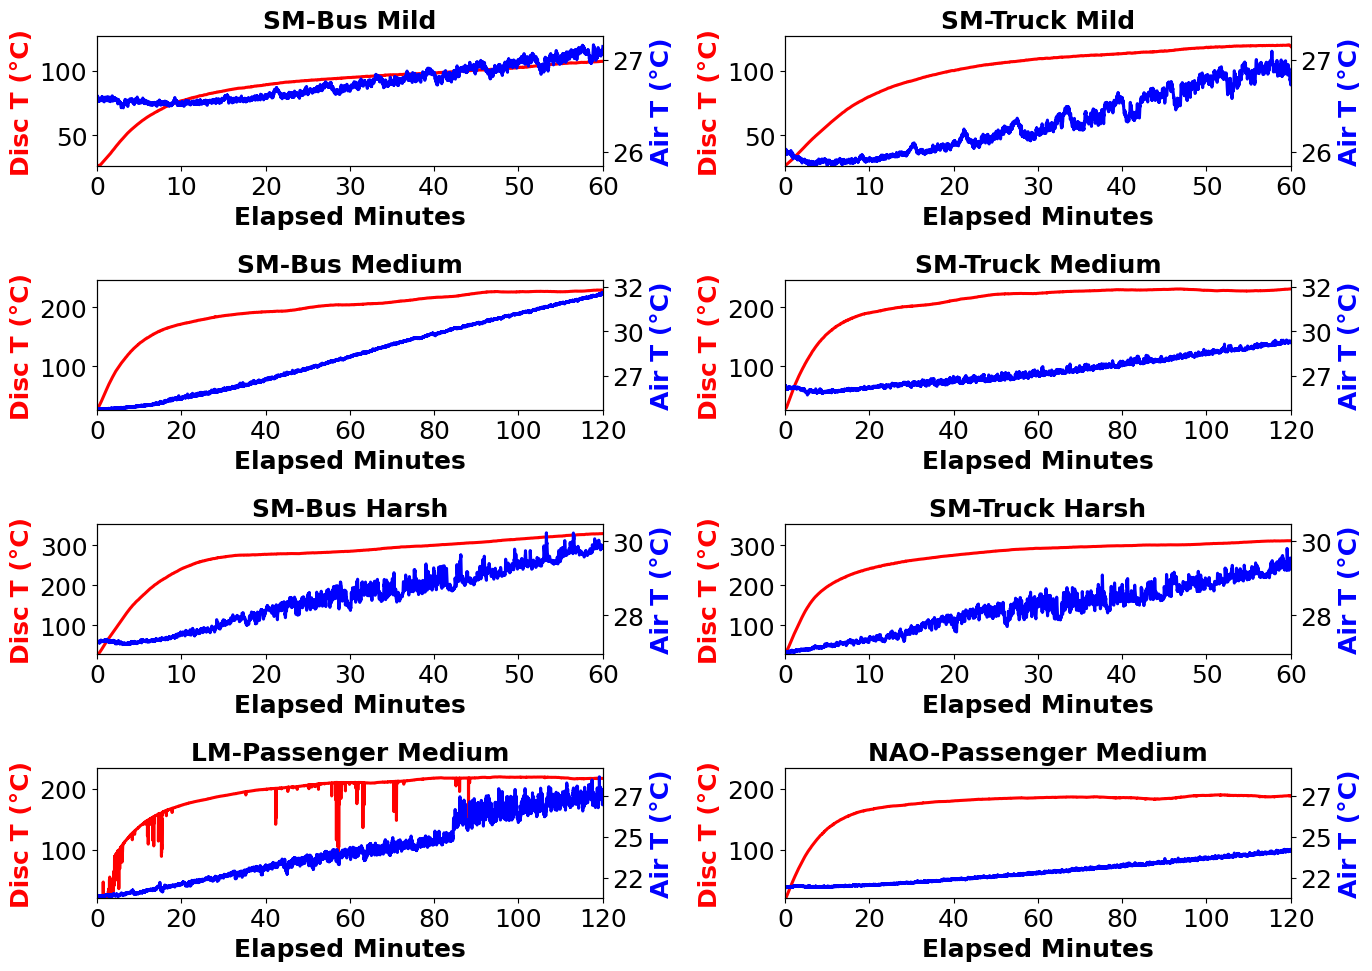

In [49]:
# ✅ Add new dataframes to the list
dfs = [HDV1_LTemp, HDV2_LTemp, HDV1_HTemp, HDV2_HTemp, HDV1_MTemp, HDV2_MTemp, LDV1_LTemp, LDV2_LTemp]

names = ['HDV1_LTemp', 'HDV2_LTemp', 'HDV1_HTemp', 'HDV2_HTemp', 'HDV1_MTemp', 'HDV2_MTemp', 'LDV1_LTemp', 'LDV2_LTemp']

# ✅ Add 'Elapsed Minutes' to all dataframes
for i, DF in enumerate(dfs):
    DF_copy = DF.copy()
    DF_copy["Elapsed Minutes"] = (DF_copy.index - DF_copy.index[0]).total_seconds() / 60
    globals()[names[i]] = DF_copy  # Update variable by name

# ✅ Function to get shared y-axis limits (with padding only at the top)
def get_shared_limits(df1, df2, col, pad_ratio=0.07):
    ymin = min(df1[col].min(), df2[col].min())
    ymax = max(df1[col].max(), df2[col].max())
    pad = (ymax - ymin) * pad_ratio
    return ymin, ymax + pad

# ✅ Get shared limits for each pair
low_disc_ylim   = get_shared_limits(HDV1_LTemp, HDV2_LTemp, "TC Disc")
low_pin_ylim    = get_shared_limits(HDV1_LTemp, HDV2_LTemp, "TC Pin")

harsh_disc_ylim = get_shared_limits(HDV1_HTemp, HDV2_HTemp, "TC Disc")
harsh_pin_ylim  = get_shared_limits(HDV1_HTemp, HDV2_HTemp, "TC Pin")

mild_disc_ylim  = get_shared_limits(HDV1_MTemp, HDV2_MTemp, "TC Disc")
mild_pin_ylim   = get_shared_limits(HDV1_MTemp, HDV2_MTemp, "TC Pin")

# ✅ New shared limits for LDVs
ldv_disc_ylim   = get_shared_limits(LDV1_LTemp, LDV2_LTemp, "TC Disc")
ldv_pin_ylim    = get_shared_limits(LDV1_LTemp, LDV2_LTemp, "TC Pin")

# ✅ Plotting function
def plot_temp(ax, df, title, disc_ylim, pin_ylim, xlim_max):
    ax2 = ax.twinx()
    ax.plot(df["Elapsed Minutes"], df["TC Disc"], 'r-', label="TC Disc")
    ax2.plot(df["Elapsed Minutes"], df["TC Pin"], 'b-', label="TC Pin")

    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel("Elapsed Minutes", fontsize=18, fontweight='bold')
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylabel("Disc T (°C)", color='r', fontsize=18, fontweight='bold')
    ax2.set_ylabel("Air T (°C)", color='b', fontsize=18, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=18)

    ax.set_ylim(disc_ylim)
    ax2.set_ylim(pin_ylim)
    ax.set_xlim(0, xlim_max)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.grid(False)
    ax2.grid(False)

# ✅ Create 4x2 subplots
fig, axs = plt.subplots(4, 2, figsize=(14, 10))

plot_temp(axs[0, 0], HDV1_MTemp, "SM-Bus Mild", mild_disc_ylim, mild_pin_ylim, xlim_max=60)
plot_temp(axs[0, 1], HDV2_MTemp, "SM-Truck Mild", mild_disc_ylim, mild_pin_ylim, xlim_max=60)

plot_temp(axs[1, 0], HDV1_LTemp, "SM-Bus Medium", low_disc_ylim, low_pin_ylim, xlim_max=120)
plot_temp(axs[1, 1], HDV2_LTemp, "SM-Truck Medium", low_disc_ylim, low_pin_ylim, xlim_max=120)

plot_temp(axs[2, 0], HDV1_HTemp, "SM-Bus Harsh", harsh_disc_ylim, harsh_pin_ylim, xlim_max=60)
plot_temp(axs[2, 1], HDV2_HTemp, "SM-Truck Harsh", harsh_disc_ylim, harsh_pin_ylim, xlim_max=60)

plot_temp(axs[3, 0], LDV1_LTemp, "LM-Passenger Medium", ldv_disc_ylim, ldv_pin_ylim, xlim_max=120)
plot_temp(axs[3, 1], LDV2_LTemp, "NAO-Passenger Medium", ldv_disc_ylim, ldv_pin_ylim, xlim_max=120)

plt.tight_layout()
plt.show()


In [50]:
# Determine the maximum, average temperature for the pin and disc
tests = [
    ("SM-Bus Mild",         HDV1_MTemp),
    ("SM-Truck Mild",       HDV2_MTemp),
    ("SM-Bus Medium",       HDV1_LTemp),
    ("SM-Truck Medium",     HDV2_LTemp),
    ("SM-Bus Harsh",        HDV1_HTemp),
    ("SM-Truck Harsh",      HDV2_HTemp),
    ("LM-Passenger Medium", LDV1_LTemp),
    ("NAO-Passenger Medium", LDV2_LTemp),
]

summary = []

for name, df in tests:

    start_time = df.index[0]

    window = df.loc[
        start_time + pd.Timedelta(minutes=40):
        start_time + pd.Timedelta(minutes=60)
    ]

    summary.append({
        "Test Condition": name,
        "Max Disc Temp (°C)": df["TC Disc"].max(),
        "Max Pin Temp (°C)": df["TC Pin"].max(),
        "Avg Disc (30–60 min)": window["TC Disc"].mean(),
        "Avg Pin (30–60 min)": window["TC Pin"].mean()
    })

max_temp_table = pd.DataFrame(summary)

max_temp_table

,Test Condition,Max Disc Temp (°C),Max Pin Temp (°C),Avg Disc (30–60 min),Avg Pin (30–60 min)
0,SM-Bus Mild,107.2596,27.16418,102.672023,26.955909
1,SM-Truck Mild,119.9199,27.09472,117.154529,26.727530
2,SM-Bus Medium,228.9575,32.37706,198.454866,27.909777
3,SM-Truck Medium,231.0236,29.66897,219.681709,27.366264
4,SM-Bus Harsh,331.5332,30.23170,315.486535,29.347240
5,SM-Truck Harsh,311.7762,29.80840,304.716158,28.891227
6,LM-Passenger Medium,219.6612,28.63817,204.413503,23.583390
7,NAO-Passenger Medium,190.9715,24.23609,183.459198,22.594935


# **FAMILIES**

## **CORRECT THE NAMING OF COMPOUNDS**

Since the compounds now contain H+, we want to remove this and have the real VOC formula. Unknown compounds in the format m/Q should not be altered

In [51]:
def correct_formula(formula):
    # Skip m/Q names or anything that doesn't look like a chemical formula
    if "m/Q" in formula or re.search(r"\d+\.\d+", formula):
        return formula  # leave as-is

    # remove + if present
    formula = formula.replace("+", "")

    # parse elements and counts
    elements = re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    corrected = {}
    for el, count in elements:
        corrected[el] = corrected.get(el, 0) + (int(count) if count else 1)

    # subtract exactly one H
    if "H" in corrected:
        corrected["H"] -= 1
        if corrected["H"] == 0:
            del corrected["H"]

    # rebuild corrected formula (C first, H second, then alphabetically)
    def sort_key(el):
        if el == "C": return "0"
        if el == "H": return "1"
        return el

    return "".join(
        f"{el}{corrected[el] if corrected[el] > 1 else ''}"
        for el in sorted(corrected.keys(), key=sort_key)
    )


## **CLASSIFY COMPOUNDS**

In [52]:
def classify_compound(formula):
    """
    Classify chemical formulas into families:

    - CHNO: contain N and O
    - CHN: contain N but no O
    - CHSO: contain S and O
    - CHS: contain S but no O
    - Si-compounds: contain Si
    - OVOCs: contain C, H, and O only
    - CH: contain C and H only (aromatic or not)
    """

    # Skip non-formula entries like 'm/Q 171.169438'
    if not re.search(r'[A-Z]', formula):
        return None  # previously "Other"

    # Parse elements
    elements = re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    elems = {el: int(count) if count else 1 for el, count in elements}

    C  = elems.get("C", 0)
    H  = elems.get("H", 0)
    N  = elems.get("N", 0)
    O  = elems.get("O", 0)
    S  = elems.get("S", 0)
    Si = elems.get("Si", 0)

    # If nothing meaningful detected
    if all(v == 0 for v in [C, H, N, O, S, Si]):
        return None  # previously "Other"

    # ---- Classification ----
    # 1. Nitrogen-containing compounds
    if N > 0:
        if O > 0:
            return "CHNO"
        else:
            return "CHN"

    # 2. Sulfur-containing compounds
    if S > 0:
        if O > 0:
            return "CHSO"
        else:
            return "CHS"

    # 3. Silicon-containing compounds
    if Si > 0:
        return "Si-compounds"

    # 4. Oxygenated VOCs (C, H, O only)
    if C > 0 and H > 0 and O > 0:
        return "OVOCs"

    # 5. Hydrocarbons (C and H only)
    if C > 0 and H > 0:
        return "CH"

    # 6. Anything else: do not classify
    return None

## **TEST THE CLASSIFICATION OUTPUT**

In [53]:
test_formulas = [
    "C6H6",      # Benzene
    "C2H6",      # Ethane
    "C2H5OH",    # Ethanol
    "CH3COOH",   # Acetic acid
    "CH3CHO",    # Acetaldehyde
    "C2H5NH2",   # Ethylamine
    "CH3SH",     # Methanethiol
    "Si2O5",     # Siloxane
    "C7H8O",     # Cresol (aromatic + oxygen)
    "C10H22"     # Decane (aliphatic hydrocarbon)
    "C2H5OH",
    "CHNO"
]

for f in test_formulas:
    print(f"{f:10s} → {classify_compound(f)}")


C6H6       → CH
C2H6       → CH
C2H5OH     → OVOCs
CH3COOH    → OVOCs
CH3CHO     → OVOCs
C2H5NH2    → CHN
CH3SH      → CHS
Si2O5      → Si-compounds
C7H8O      → OVOCs
C10H22C2H5OH → OVOCs
CHNO       → CHNO


## **APPLYING THE ABOVE**

In [54]:
# Correct formulas
corrected_columns = {col: correct_formula(col) for col in VMR_HDV_df.columns} # original data with fixed chemical formulas.
VMR_HDV_corrected = VMR_HDV_df.rename(columns=corrected_columns)

# Map each compound to a family
compound_classes = {c: classify_compound(c) for c in VMR_HDV_corrected.columns}

# Group columns by family and sum concentrations
VMR_HDV_family = VMR_HDV_corrected.groupby(by=compound_classes, axis=1).sum()

# optional: keep a lookup table of compound → family
compound_classes_df = pd.DataFrame.from_dict(compound_classes, orient="index", columns=["Family"])


/tmp/ipykernel_44098/85116564.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  VMR_HDV_family = VMR_HDV_corrected.groupby(by=compound_classes, axis=1).sum()


In [55]:
VMR_HDV_corrected.head()

,CHN,C2H3,CH4O,C3H4,C2H3N,C2H2O,C3H6,C2H3O,C2H5N,CH3NO,...,m/Q 157.116647,m/Q 157.152931,m/Q 157.174543,m/Q 167.136816,m/Q 169.188274,m/Q 171.167655,C13H17,C5H17N7,C8H7N3O2,C4H15N7O
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,0.007367,-0.004541,-0.005666,0.041202,0.011216,0.319630,0.001900,-0.012938,0.015731,-0.038456,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.002289,-0.003839,-0.016810,0.009471,0.149652,0.122683,-0.003656,0.016991,0.046354,0.045114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-0.002194,-0.004462,0.030733,0.002366,0.047865,0.112020,0.010254,0.012060,-0.014793,0.088693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.003621,0.012273,-0.005232,0.014339,-0.000165,0.071150,-0.006411,-0.028221,-0.008157,0.061466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,0.000261,-0.004541,0.010933,0.010319,0.017749,0.124480,-0.006189,0.024565,-0.016633,0.025940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
VMR_HDV_family.head()

,CH,CHN,CHNO,CHS,CHSO,OVOCs,Si-compounds
Time,,,,,,,
2025-02-06 10:14:03,0.062083,0.938742,2.605582,0.012219,-0.011096,7.862074,0.052309
2025-02-06 10:14:13,0.029503,0.546740,1.489440,0.012474,-0.004602,3.974421,-0.023431
2025-02-06 10:14:23,0.071900,0.459334,0.785702,-0.007698,-0.004651,3.078796,0.047423
2025-02-06 10:14:33,-0.055203,0.272883,0.749352,-0.000804,0.016204,2.730035,-0.131914
2025-02-06 10:14:43,-0.016619,0.203490,0.827736,0.010943,-0.002557,2.123515,-0.107823


## **FAMILY PLOTS**

In [57]:
#defining the time frames when experiment was done. VOC_zero is the time where experiments started
datasets = [
    # HARSH HDV1
    {"label": "HARSH HDV1 - Original", "voc_zero": "2025-02-25 09:42:50"},
    {"label": "HARSH HDV1 - Repeat",   "voc_zero": "2025-03-04 10:06:00"},
    # HARSH HDV2
    {"label": "HARSH HDV2 - Original", "voc_zero": "2025-02-25 15:25:00"},
    {"label": "HARSH HDV2 - Repeat",   "voc_zero": "2025-03-04 16:05:00"},
    # MILD HDV1
    {"label": "MILD HDV1 - Original",  "voc_zero": "2025-02-24 11:11:00"},
    {"label": "MILD HDV1 - Repeat",    "voc_zero": "2025-02-27 10:19:00"},
    # MILD HDV2
    {"label": "MILD HDV2 - Original",  "voc_zero": "2025-02-24 16:52:00"},
    {"label": "MILD HDV2 - Repeat",    "voc_zero": "2025-02-27 16:04:00"},
    # MEDIUM HDV1
    {"label": "MEDIUM HDV1 - Original", "voc_zero": "2025-02-11 11:28:00"},
    {"label": "MEDIUM HDV1 - Repeat",   "voc_zero": "2025-02-19 10:34:00"},
    # MEDIUM HDV2
    {"label": "MEDIUM HDV2 - Original", "voc_zero": "2025-02-12 11:06:00"},
    {"label": "MEDIUM HDV2 - Repeat",   "voc_zero": "2025-02-13 11:57:00"},
    # MEDIUM LDV1
    {"label": "MEDIUM LDV1 - Original", "voc_zero": "2025-03-10 11:46:00"},
    {"label": "MEDIUM LDV1 - Repeat",   "voc_zero": "2025-03-11 10:34:00"},
    # MEDIUM LDV2
    {"label": "MEDIUM LDV2 - Original", "voc_zero": "2025-03-31 10:14:50"},
    {"label": "MEDIUM LDV2 - Repeat",   "voc_zero": "2025-04-01 10:25:05"},
]


In [58]:
# Helper: average over 40-60-minutes window from VOC_zero
def avg_family_60min(df, voc_zero):
    voc_zero = pd.to_datetime(voc_zero)
    mask = (df.index >= voc_zero + pd.Timedelta(minutes=40)) & (df.index < voc_zero + pd.Timedelta(minutes=60))
    return df.loc[mask].mean()  # ✅ average over 20 min

def get_condition_hdv(label):
    label_upper = label.upper()

    # Condition
    if "MILD" in label_upper:
        condition = "Mild"
    elif "HARSH" in label_upper:
        condition = "Harsh"
    elif "MEDIUM" in label_upper:
        condition = "Medium"
    else:
        condition = "Unknown"

    # Vehicle type
    if "HDV1" in label_upper:
        vehicle = "HDV1"
    elif "HDV2" in label_upper:
        vehicle = "HDV2"
    elif "LDV1" in label_upper:
        vehicle = "LDV1"
    elif "LDV2" in label_upper:
        vehicle = "LDV2"
    else:
        vehicle = "Unknown"

    return condition, vehicle


# --- Collect results for both Original and Repeat
results = []
for d in datasets:  # <--- use full dataset list
    voc_zero = d["voc_zero"]
    condition, hdv = get_condition_hdv(d["label"])
    family_avg = avg_family_60min(VMR_HDV_family, voc_zero)

    results.append(pd.DataFrame({
        "Family": family_avg.index,
        "Average": family_avg.values,
        "Condition": condition,
        "HDV": hdv,
        "Type": "Original" if "Original" in d["label"] else "Repeat"
    }))

results_df = pd.concat(results, ignore_index=True)

results_df["Cond_HDV"] = (
    results_df["Condition"] + " " + results_df["HDV"] + " " + results_df["Type"]
)

pivot_df = results_df.pivot(
    index="Family",
    columns="Cond_HDV",
    values="Average"
)
pivot_df





Cond_HDV,Harsh HDV1 Original,Harsh HDV1 Repeat,Harsh HDV2 Original,Harsh HDV2 Repeat,Medium HDV1 Original,Medium HDV1 Repeat,Medium HDV2 Original,Medium HDV2 Repeat,Medium LDV1 Original,Medium LDV1 Repeat,Medium LDV2 Original,Medium LDV2 Repeat,Mild HDV1 Original,Mild HDV1 Repeat,Mild HDV2 Original,Mild HDV2 Repeat
Family,,,,,,,,,,,,,,,,
CH,3.477276,2.733819,2.303046,2.973492,0.465114,0.342712,0.707462,0.562681,1.125337,1.367469,2.163982,0.335403,-0.112487,-0.032521,0.077735,0.037220
CHN,12.572044,7.939873,6.345801,8.552171,1.333261,0.491567,1.127688,1.267947,5.909125,5.536600,4.876961,1.644882,0.324334,0.101163,0.373352,0.376565
CHNO,18.922829,12.569888,10.838088,16.075040,1.818769,1.107123,2.444051,1.916028,6.798839,8.148580,6.766548,1.000117,0.373685,0.154035,0.801894,0.618548
CHS,0.074700,0.056360,0.038209,0.050001,0.006773,0.000816,0.006140,0.008778,0.076468,0.086412,0.084592,0.011292,-0.002965,-0.001343,0.001846,0.000086
CHSO,0.067115,0.036021,0.023125,0.036875,0.003411,0.000845,0.003672,0.003368,0.224341,0.153313,0.190378,0.032602,0.004332,0.000262,0.000632,0.000742
OVOCs,21.767891,19.248627,15.524032,19.108727,4.670334,2.600104,4.890059,5.039250,5.620932,8.290517,4.796193,0.864291,0.604628,-0.146944,1.117377,1.022456
Si-compounds,1.366171,1.018231,0.656999,0.993765,0.192256,0.101923,0.202062,0.246405,0.727768,0.531584,0.570078,0.116532,-0.094131,-0.035729,0.019676,0.026984


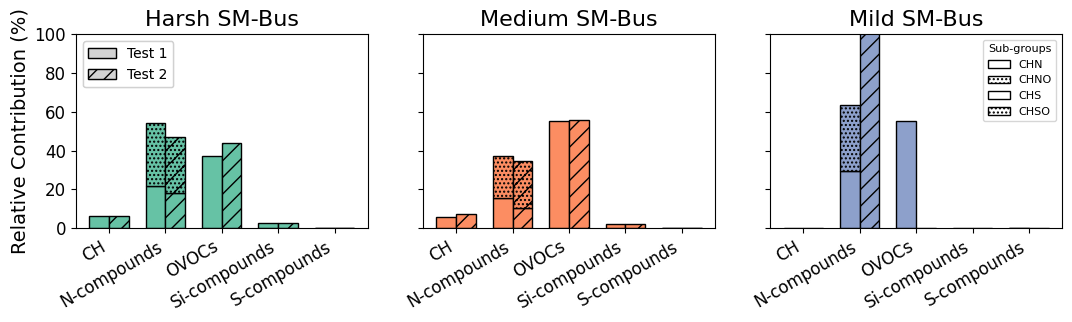

In [59]:
conditions = ["Harsh", "Medium", "Mild"]
runs = ["Original", "Repeat"]   # HDV1 only
bar_width, gap = 0.35, 0.3
colors = sns.color_palette("Set2", n_colors=len(conditions))

# Hatch styles for runs
RUN_HATCH = {
    "Original": "",
    "Repeat": "//"
}

DOT_HATCH = "...."   # dense dots for sub-groups

# ------------------ DATA ------------------
# Keep ONLY HDV1 Original and HDV1 Repeat
df_full = pivot_df[
    [c for c in pivot_df.columns
     if ("HDV1 Original" in c) or ("HDV1 Repeat" in c)]
].copy()

# ------------------ MERGE FAMILIES ------------------
df = df_full.copy()
df.loc["N-compounds"] = df.loc["CHN"] + df.loc["CHNO"]
df.loc["S-compounds"] = df.loc["CHS"] + df.loc["CHSO"]
df = df.drop(index=["CHN", "CHNO", "CHS", "CHSO"])

# ------------------ ORDER FAMILIES ------------------
threshold = df.max().max() * 0.1
dwarfed = df.index[df.max(axis=1) < threshold]
big = df.index.difference(dwarfed)

ordered_fams = list(big) + list(dwarfed)
if "Other" in ordered_fams:
    ordered_fams.remove("Other")
    ordered_fams.append("Other")

df = df.loc[ordered_fams]
num_fam = len(df.index)

# ------------------ RELATIVE CONTRIBUTIONS ------------------
def compute_rel(df, cond):
    rel_df = df[
        [f"{cond} HDV1 {run}"
         for run in runs
         if f"{cond} HDV1 {run}" in df.columns]
    ].copy()

    for col in rel_df.columns:
        total = df[col].sum()
        rel_df[col] = (df[col] / total * 100) if total != 0 else 0

    return rel_df


# ------------------ VEHICLE LABEL FIX (ONLY ADDITION) ------------------
vehicle_map = {
    "HDV1": "SM-Bus",
    "HDV2": "SM-Truck",
    "LDV1": "LM",
    "LDV2": "NAO"
}


# ------------------ PLOTTING ------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

for ax, cond in zip(axes, conditions):

    rel_df = compute_rel(df, cond)

    for i, fam in enumerate(rel_df.index):
        base = i * (len(runs) * bar_width + gap)

        for k, run in enumerate(runs):
            col = f"{cond} HDV1 {run}"
            x = base + k * bar_width
            total_h = rel_df.loc[fam, col]
            hatch = RUN_HATCH[run]
            color = colors[conditions.index(cond)]

            # -------- N-COMPOUNDS --------
            if fam == "N-compounds":
                chn = df_full.loc["CHN", col]
                chno = df_full.loc["CHNO", col]
                s = chn + chno

                h_chn = total_h * chn / s if s != 0 else 0
                h_chno = total_h * chno / s if s != 0 else 0

                ax.bar(x, h_chn, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

                ax.bar(x, h_chno, width=bar_width, bottom=h_chn,
                       color=color, edgecolor='black',
                       hatch=hatch + DOT_HATCH)

            # -------- S-COMPOUNDS --------
            elif fam == "S-compounds":
                chs = df_full.loc["CHS", col]
                chso = df_full.loc["CHSO", col]
                s = chs + chso

                h_chs = total_h * chs / s if s != 0 else 0
                h_chso = total_h * chso / s if s != 0 else 0

                ax.bar(x, h_chs, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

                ax.bar(x, h_chso, width=bar_width, bottom=h_chs,
                       color=color, edgecolor='black',
                       hatch=hatch + DOT_HATCH)

            # -------- OTHER FAMILIES --------
            else:
                ax.bar(x, total_h, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

    xt = [
        i * (len(runs) * bar_width + gap)
        + (len(runs) * bar_width) / 2 - bar_width / 2
        for i in range(num_fam)
    ]

    ax.set_xticks(xt)
    ax.set_xticklabels(rel_df.index, rotation=30, ha='right')

    # ---------------- ONLY LABEL CHANGE ----------------
    vehicle_label = vehicle_map["HDV1"]

    ax.set_title(
        f"{cond} {vehicle_label}",
        fontsize=16
    )

    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(False)

axes[0].set_ylabel("Relative Contribution (%)", fontsize=14)

# ------------------ LEGEND 1: RUN TYPE ------------------
run_handles = [
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='', label='Test 1'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='//', label='Test 2')
]

leg1 = axes[0].legend(
    handles=run_handles,
    fontsize=10,
    title_fontsize=10,
    loc='upper left'
)
axes[0].add_artist(leg1)

# ------------------ LEGEND 2: CHEMICAL SUB-GROUPS ------------------
subgroup_handles = [
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch='', label='CHN'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch=DOT_HATCH, label='CHNO'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch='', label='CHS'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch=DOT_HATCH, label='CHSO')
]

axes[2].legend(
    handles=subgroup_handles,
    title="Sub-groups",
    fontsize=8,
    title_fontsize=8,
    loc='upper right'
)

plt.tight_layout()
plt.show()

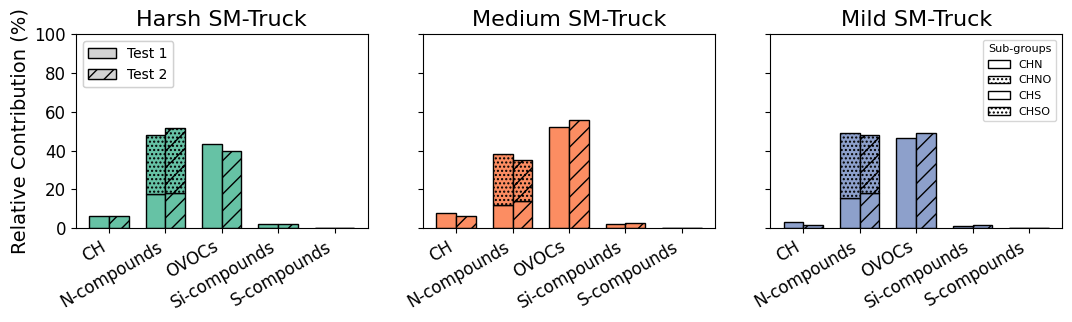

In [60]:
conditions = ["Harsh", "Medium", "Mild"]
runs = ["Original", "Repeat"]   # HDV2 only
bar_width, gap = 0.35, 0.3
colors = sns.color_palette("Set2", n_colors=len(conditions))

# Hatch styles for runs
RUN_HATCH = {
    "Original": "",
    "Repeat": "//"
}

DOT_HATCH = "...."   # dense dots for sub-groups

# ------------------ DATA ------------------
# Keep ONLY HDV2 Original and HDV2 Repeat
df_full = pivot_df[
    [c for c in pivot_df.columns
     if ("HDV2 Original" in c) or ("HDV2 Repeat" in c)]
].copy()

# ------------------ MERGE FAMILIES ------------------
df = df_full.copy()
df.loc["N-compounds"] = df.loc["CHN"] + df.loc["CHNO"]
df.loc["S-compounds"] = df.loc["CHS"] + df.loc["CHSO"]
df = df.drop(index=["CHN", "CHNO", "CHS", "CHSO"])

# ------------------ ORDER FAMILIES ------------------
threshold = df.max().max() * 0.1
dwarfed = df.index[df.max(axis=1) < threshold]
big = df.index.difference(dwarfed)

ordered_fams = list(big) + list(dwarfed)
if "Other" in ordered_fams:
    ordered_fams.remove("Other")
    ordered_fams.append("Other")

df = df.loc[ordered_fams]
num_fam = len(df.index)

# ------------------ RELATIVE CONTRIBUTIONS ------------------
def compute_rel(df, cond):
    rel_df = df[
        [f"{cond} HDV2 {run}"
         for run in runs
         if f"{cond} HDV2 {run}" in df.columns]
    ].copy()

    for col in rel_df.columns:
        total = df[col].sum()
        rel_df[col] = (df[col] / total * 100) if total != 0 else 0

    return rel_df


# ------------------ PLOTTING ------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

for ax, cond in zip(axes, conditions):
    rel_df = compute_rel(df, cond)

    for i, fam in enumerate(rel_df.index):
        base = i * (len(runs) * bar_width + gap)

        for k, run in enumerate(runs):
            col = f"{cond} HDV2 {run}"
            x = base + k * bar_width
            total_h = rel_df.loc[fam, col]
            hatch = RUN_HATCH[run]
            color = colors[conditions.index(cond)]

            # -------- N-COMPOUNDS --------
            if fam == "N-compounds":
                chn = df_full.loc["CHN", col]
                chno = df_full.loc["CHNO", col]
                s = chn + chno

                h_chn = total_h * chn / s if s != 0 else 0
                h_chno = total_h * chno / s if s != 0 else 0

                ax.bar(x, h_chn, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

                ax.bar(x, h_chno, width=bar_width, bottom=h_chn,
                       color=color, edgecolor='black',
                       hatch=hatch + DOT_HATCH)

            # -------- S-COMPOUNDS --------
            elif fam == "S-compounds":
                chs = df_full.loc["CHS", col]
                chso = df_full.loc["CHSO", col]
                s = chs + chso

                h_chs = total_h * chs / s if s != 0 else 0
                h_chso = total_h * chso / s if s != 0 else 0

                ax.bar(x, h_chs, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

                ax.bar(x, h_chso, width=bar_width, bottom=h_chs,
                       color=color, edgecolor='black',
                       hatch=hatch + DOT_HATCH)

            # -------- OTHER FAMILIES --------
            else:
                ax.bar(x, total_h, width=bar_width,
                       color=color, edgecolor='black',
                       hatch=hatch)

    xt = [
        i * (len(runs) * bar_width + gap)
        + (len(runs) * bar_width) / 2 - bar_width / 2
        for i in range(num_fam)
    ]

    ax.set_xticks(xt)
    ax.set_xticklabels(rel_df.index, rotation=30, ha='right')

    # ---------------- ONLY LABEL CHANGE ----------------
    ax.set_title(f"{cond} SM-Truck", fontsize=16)

    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(False)

axes[0].set_ylabel("Relative Contribution (%)", fontsize=14)

# ------------------ LEGEND 1: RUN TYPE ------------------
run_handles = [
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='', label='Test 1'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='//', label='Test 2')
]

leg1 = axes[0].legend(
    handles=run_handles,
    fontsize=10,
    title_fontsize=10,
    loc='upper left'
)
axes[0].add_artist(leg1)

# ------------------ LEGEND 2: CHEMICAL SUB-GROUPS ------------------
subgroup_handles = [
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch='', label='CHN'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch=DOT_HATCH, label='CHNO'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch='', label='CHS'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch=DOT_HATCH, label='CHSO')
]

axes[2].legend(
    handles=subgroup_handles,
    title="Sub-groups",
    fontsize=8,
    title_fontsize=8,
    loc='upper right'
)

plt.tight_layout()
plt.show()

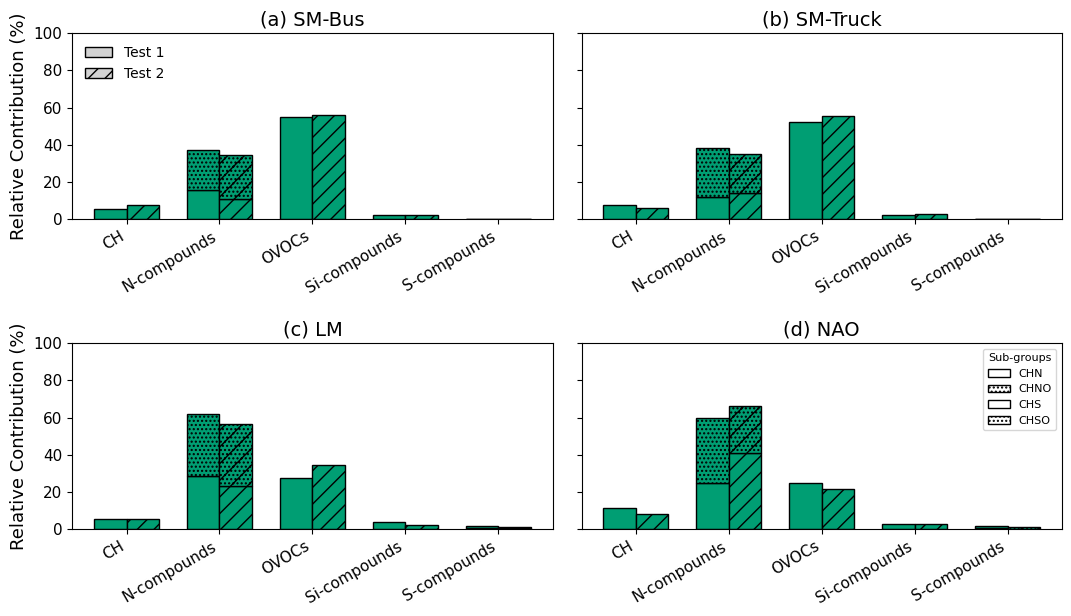

In [61]:
import matplotlib.patches as mpatches

# ------------------ PARAMETERS ------------------
vehicles = ["HDV1", "HDV2", "LDV1", "LDV2"]
vehicle_map = {"HDV1": "SM-Bus", "HDV2": "SM-Truck", "LDV1": "LM", "LDV2": "NAO"}
condition = "Medium"
runs = ["Original", "Repeat"]

bar_width, gap = 0.35, 0.3
UNIFORM_COLOR = "#009E73"  # Updated color
RUN_HATCH = {"Original": "", "Repeat": "//"}
DOT_HATCH = "...."

# ------------------ DATA ------------------
df_full = pivot_df[
    [c for c in pivot_df.columns
     if condition in c and any(v in c for v in vehicles)]
].copy()

# ------------------ MERGE FAMILIES ------------------
df = df_full.copy()
df.loc["N-compounds"] = df.loc["CHN"] + df.loc["CHNO"]
df.loc["S-compounds"] = df.loc["CHS"] + df.loc["CHSO"]
df = df.drop(index=["CHN", "CHNO", "CHS", "CHSO"])

# ------------------ ORDER FAMILIES ------------------
threshold = df.max().max() * 0.1
dwarfed = df.index[df.max(axis=1) < threshold]
big = df.index.difference(dwarfed)

ordered_fams = list(big) + list(dwarfed)
if "Other" in ordered_fams:
    ordered_fams.remove("Other")
    ordered_fams.append("Other")

df = df.loc[ordered_fams]
num_fam = len(df.index)

# ------------------ RELATIVE CONTRIBUTIONS ------------------
def compute_rel(df, veh):
    rel_df = df[
        [f"{condition} {veh} {run}"
         for run in runs
         if f"{condition} {veh} {run}" in df.columns]
    ].copy()

    for col in rel_df.columns:
        total = df[col].sum()
        rel_df[col] = (df[col] / total * 100) if total != 0 else 0

    return rel_df

# ------------------ PLOTTING ------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.flatten()

subplot_labels = ["(a) SM-Bus", "(b) SM-Truck", "(c) LM", "(d) NAO"]

for ax, veh, sublabel in zip(axes, vehicles, subplot_labels):
    rel_df = compute_rel(df, veh)
    for i, fam in enumerate(rel_df.index):
        base = i * (len(runs) * bar_width + gap)
        for k, run in enumerate(runs):
            col = f"{condition} {veh} {run}"
            x = base + k * bar_width
            total_h = rel_df.loc[fam, col]
            hatch = RUN_HATCH[run]

            # -------- N-COMPOUNDS --------
            if fam == "N-compounds":
                chn = df_full.loc["CHN", col]
                chno = df_full.loc["CHNO", col]
                s = chn + chno
                h_chn = total_h * chn / s if s != 0 else 0
                h_chno = total_h * chno / s if s != 0 else 0

                ax.bar(x, h_chn, width=bar_width,
                       color=UNIFORM_COLOR, edgecolor='black', hatch=hatch)
                ax.bar(x, h_chno, width=bar_width, bottom=h_chn,
                       color=UNIFORM_COLOR, edgecolor='black', hatch=hatch + DOT_HATCH)

            # -------- S-COMPOUNDS --------
            elif fam == "S-compounds":
                chs = df_full.loc["CHS", col]
                chso = df_full.loc["CHSO", col]
                s = chs + chso
                h_chs = total_h * chs / s if s != 0 else 0
                h_chso = total_h * chso / s if s != 0 else 0

                ax.bar(x, h_chs, width=bar_width,
                       color=UNIFORM_COLOR, edgecolor='black', hatch=hatch)
                ax.bar(x, h_chso, width=bar_width, bottom=h_chs,
                       color=UNIFORM_COLOR, edgecolor='black', hatch=hatch + DOT_HATCH)

            # -------- OTHER FAMILIES --------
            else:
                ax.bar(x, total_h, width=bar_width,
                       color=UNIFORM_COLOR, edgecolor='black', hatch=hatch)

    # X-ticks
    xt = [
        i * (len(runs) * bar_width + gap)
        + (len(runs) * bar_width) / 2 - bar_width / 2
        for i in range(num_fam)
    ]
    ax.set_xticks(xt)
    ax.set_xticklabels(rel_df.index, rotation=30, ha='right')

    # Title with subplot label
    ax.set_title(sublabel, fontsize=14)

    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(False)

axes[0].set_ylabel("Relative Contribution (%)", fontsize=13)
axes[2].set_ylabel("Relative Contribution (%)", fontsize=13)

# ------------------ LEGEND 1: RUN TYPE ------------------
run_handles = [
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='', label='Test 1'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black',
                   hatch='//', label='Test 2')
]

axes[0].legend(
    handles=run_handles,
    fontsize=10,
    title_fontsize=10,
    loc='upper left',
    frameon=False
)

# ------------------ LEGEND 2: SUB-GROUPS ------------------
subgroup_handles = [
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='', label='CHN'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch=DOT_HATCH, label='CHNO'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='', label='CHS'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch=DOT_HATCH, label='CHSO')
]

axes[3].legend(
    handles=subgroup_handles,
    title="Sub-groups",
    fontsize=8,
    title_fontsize=8,
    loc='upper right'
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [62]:
# @title
CH = compound_classes_df[compound_classes_df['Family'] == 'CH']
print("CH:")
#display(CH.index.tolist())

CH:


In [63]:
def classify_compound(formula):
    if not re.search(r'[A-Z]', formula):
        return "Other"

    elements = re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    elems = {el: int(count) if count else 1 for el, count in elements}

    C = elems.get("C", 0)
    H = elems.get("H", 0)
    N = elems.get("N", 0)
    O = elems.get("O", 0)

    if C == 0 or H == 0:
        return "Other"

    # Double Bond Equivalent
    DBE = C - H / 2 + N / 2 + 1

    # ---- Classification ----

    # Aromatics (including phenols)
    if C >= 6 and DBE >= 4:
        return "Aromatic"

    # Carboxylic acids
    if C >= 2 and O >= 2 and DBE >= 1:
        return "Carboxylic acid"

    # Aldehydes / Ketones
    if C >= 2 and O == 1 and DBE >= 1:
        return "Aldehyde/Ketone"

    # Alcohols (aliphatic)
    if O == 1 and DBE == 0:
        return "Alcohol"

    return "Other"


In [64]:
# Build a mapping: column → chemical family
family_map = {
    col: classify_compound(str(col))
    for col in VMR_HDV_corrected.columns
}

# Optional: view how many columns fall in each family
#pd.Series(family_map).value_counts()


In [65]:
from collections import defaultdict

families = defaultdict(list)

for formula, family in family_map.items():
    families[family].append(formula)

for family, compounds in families.items():
    print(f"\n=== {family} ({len(compounds)}) ===")
    print(compounds)



=== Other (552) ===
['CHN', 'C2H3', 'C3H4', 'C2H3N', 'C3H6', 'C2H5N', 'CH3NO', 'H4NO2', 'CH6O2', 'H6N2O', 'CH3NO2', 'HNO3', 'CH5NO2', 'C2H9NO', 'C5H6', 'C2HN3', 'C4H5N', 'C5H7', 'C3H4N2', 'C4H6N', 'C5H8', 'C3H6N2', 'C5H10', 'C3H9Si', 'C3H8O2', 'C2H7NO2', 'C3H9O2', 'C5H4N', 'C2H7OS', 'C6H7', 'C2H9NO2', 'C4H4N2', 'C2H8O3', 'C6H8', 'C5H7N', 'C6H9', 'C5H8N', 'C6H10', 'H5NO4', 'C6H11', 'C6H12', 'C5H11N', 'C3H9NSi', 'C4H10O2', 'C3H9NO2', 'C2H11N4', 'C3H8O3', 'C4H12O2', 'C3H11NO2', 'C3H10O3', 'C7H10', 'C3H4N4', 'C7H12', 'C3H5N4', 'C2H11NOS', 'C3H13OS', 'C2H13N2S', 'C6H11N', 'C7H13', 'C7H14', 'C4H9N3', 'C6H13N', 'C3H10Si2', 'C5H2N3', 'C5H12O2', 'C4H10O3', 'C5H14O2', 'C8H12', 'C3H10O4', 'C7H12N', 'C8H14', 'C4H7N2Si', 'C5H9NSi', 'H15O6', 'C3H17NOSi', 'C8H15', 'C4H8Si2', 'C8H16', 'C4H12N3O', 'C3H9NSSi', 'C4H11N2O2', 'C3H11N4O', 'C3H10N3O2', 'C2H9N4O2', 'C2H8N3O3', 'C9H14', 'C8H13N', 'C9H15', 'C9H16', 'C4H7NSi2', 'C4H7N5', 'C8H15N', 'C9H18', 'C5H12Si2', 'C5H10SSi', 'C4H13NSi2', 'C3H12N2Si2', 'C7H

In [66]:
#families["Aromatic"]
#families["Alcohol"]
#families["Aldehyde/Ketone"]
#families["Carboxylic acid"]


## **AROMATIC COMPOUNDS**

In [67]:
#defining the time frames when experiment was done. VOC_zero is the time where experiments started
datasets = [
    # HARSH HDV1
    {"label": "HARSH HDV1 - Original", "voc_zero": "2025-02-25 09:42:50"},
    {"label": "HARSH HDV1 - Repeat",   "voc_zero": "2025-03-04 10:06:00"},
    # HARSH HDV2
    {"label": "HARSH HDV2 - Original", "voc_zero": "2025-02-25 15:25:00"},
    {"label": "HARSH HDV2 - Repeat",   "voc_zero": "2025-03-04 16:05:00"},
    # MILD HDV1
    {"label": "MILD HDV1 - Original",  "voc_zero": "2025-02-24 11:11:00"},
    {"label": "MILD HDV1 - Repeat",    "voc_zero": "2025-02-27 10:19:00"},
    # MILD HDV2
    {"label": "MILD HDV2 - Original",  "voc_zero": "2025-02-24 16:52:00"},
    {"label": "MILD HDV2 - Repeat",    "voc_zero": "2025-02-27 16:04:00"},
    # MEDIUM HDV1
    {"label": "MEDIUM HDV1 - Original", "voc_zero": "2025-02-11 11:28:00"},
    {"label": "MEDIUM HDV1 - Repeat",   "voc_zero": "2025-02-19 10:34:00"},
    # MEDIUM HDV2
    {"label": "MEDIUM HDV2 - Original", "voc_zero": "2025-02-12 11:06:00"},
    {"label": "MEDIUM HDV2 - Repeat",   "voc_zero": "2025-02-13 11:57:00"},
    # MEDIUM LDV1
    {"label": "MEDIUM LDV1 - Original", "voc_zero": "2025-03-10 11:46:00"},
    {"label": "MEDIUM LDV1 - Repeat",   "voc_zero": "2025-03-11 10:34:00"},
    # MEDIUM LDV2
    {"label": "MEDIUM LDV2 - Original", "voc_zero": "2025-03-31 10:14:50"},
    {"label": "MEDIUM LDV2 - Repeat",   "voc_zero": "2025-04-01 10:25:05"},
]


In [68]:
# --- Helper: calculate DBE and detect aromatic compounds ---

def is_aromatic(formula):
    """
    Determine whether a compound is aromatic using DBE.
    DBE = C - H/2 + N/2 + 1

    Rule used:
    Aromatic if DBE >= 4  (captures benzene-like systems)

    Returns:
        True / False
    """

    # Parse elements
    elements = re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    elems = {el: int(count) if count else 1 for el, count in elements}

    C = elems.get("C", 0)
    H = elems.get("H", 0)
    N = elems.get("N", 0)

    # If no carbon → cannot be aromatic
    if C == 0:
        return False

    # Calculate DBE
    DBE = C - H/2 + N/2 + 1

    return DBE >= 4


In [69]:
# --- Classify all compounds as aromatic or non-aromatic ---

aromatic_flags = {
    col: "Aromatic" if is_aromatic(col) else "Non-aromatic"
    for col in VMR_HDV_corrected.columns
}

aromatic_df = pd.DataFrame.from_dict(
    aromatic_flags,
    orient="index",
    columns=["Aromatic_Class"]
)

#aromatic_df.tail(100)


In [70]:
# --- List of aromatic compounds ---

aromatic_compounds = [
    comp for comp, cls in aromatic_flags.items()
    if cls == "Aromatic"
]

print(f"Number of aromatic compounds: {len(aromatic_compounds)}")
#aromatic_compounds[:20]   # preview first 20


Number of aromatic compounds: 250


In [71]:
# --- DataFrame containing only aromatic compounds ---

VMR_aromatic = VMR_HDV_corrected[aromatic_compounds]

VMR_aromatic.head()


,C2HN3,C5H4N,C6H6,C5H4O,C4H4N2,C7H7,C7H8,C6H5O,C6H7N,C6H6O,...,C6H6Si,C5H3N3O,C5H4N2S,C4H3N3O2,C3H5N5O,C5HN5,C8H7NSi,C7H4N2S,C13H17,C8H7N3O2
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,-0.001599,0.615046,0.023472,0.006797,-0.000559,-0.00386,0.002968,-0.002981,-0.002732,0.029556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-0.010236,0.288775,-0.004310,-0.014420,-0.002882,-0.00386,-0.005136,-0.006678,-0.004413,-0.018575,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,0.024603,0.190142,-0.004310,0.005893,-0.002882,-0.00386,0.016272,0.002556,0.010371,-0.009017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-0.010236,0.210645,0.002835,0.010764,-0.002882,-0.00386,-0.012146,0.012908,0.019537,-0.019337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,-0.008880,0.202095,-0.004310,0.017034,-0.002882,-0.00386,0.001408,-0.012293,-0.004413,0.016325,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
# --- Calculate aromatic fraction for each experiment ---

aromatic_results = []

for experiment in datasets:

    label = experiment["label"]
    voc_zero = pd.to_datetime(experiment["voc_zero"])

    condition, vehicle = get_condition_hdv(label)

    # Define 40–60 min window
    time_window = (
        (VMR_HDV_corrected.index >= voc_zero + pd.Timedelta(minutes=40)) &
        (VMR_HDV_corrected.index <  voc_zero + pd.Timedelta(minutes=60))
    )

    # Total VOC average (all compounds)
    total_mean = (
        VMR_HDV_corrected.loc[time_window]
        .sum(axis=1)
        .mean()
    )

    # Aromatic VOC average
    aromatic_mean = (
        VMR_aromatic.loc[time_window]
        .sum(axis=1)
        .mean()
    )

    if total_mean == 0:
        aromatic_fraction = 0
    else:
        aromatic_fraction = aromatic_mean / total_mean

    aromatic_results.append({
        "Condition": condition,
        "Vehicle": vehicle,
        "Type": "Original" if "Original" in label else "Repeat",
        "Aromatic_Fraction": aromatic_fraction,
        "Aromatic_%": aromatic_fraction * 100
    })

aromatic_fraction_df = pd.DataFrame(aromatic_results)

aromatic_fraction_df


,Condition,Vehicle,Type,Aromatic_Fraction,Aromatic_%
0,Harsh,HDV1,Original,0.230692,23.069170
1,Harsh,HDV1,Repeat,0.204094,20.409440
2,Harsh,HDV2,Original,0.166670,16.667002
3,Harsh,HDV2,Repeat,0.178607,17.860710
4,Mild,HDV1,Original,0.069550,6.955023
5,Mild,HDV1,Repeat,0.156067,15.606660
6,Mild,HDV2,Original,0.087154,8.715389
7,Mild,HDV2,Repeat,0.082161,8.216119
8,Medium,HDV1,Original,0.154805,15.480530
9,Medium,HDV1,Repeat,0.192331,19.233096


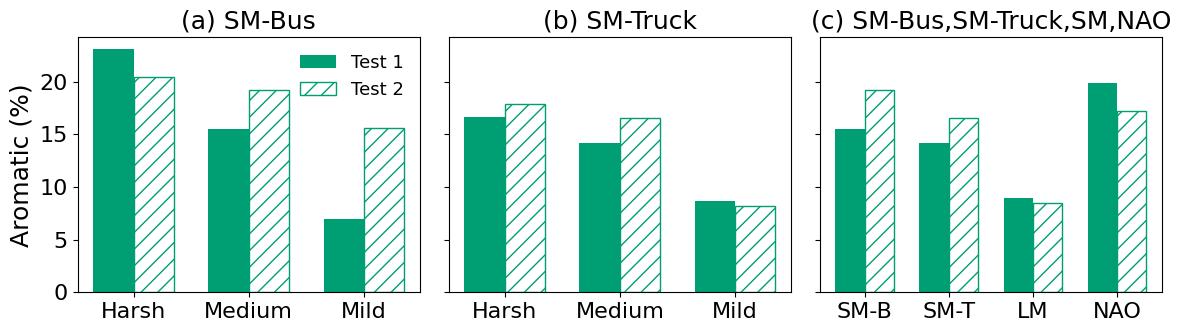

In [73]:
# --- Define experiments per subplot ---
groups = {
    "SM-Bus": ["HARSH HDV1", "MEDIUM HDV1", "MILD HDV1"],
    "SM-Truck": ["HARSH HDV2", "MEDIUM HDV2", "MILD HDV2"],
    "Medium Braking": ["MEDIUM HDV1", "MEDIUM HDV2", "MEDIUM LDV1", "MEDIUM LDV2"]
}

# Mapping for x-axis labels for subplot C
vehicle_map = {"MEDIUM HDV1": "SM-B", "MEDIUM HDV2": "SM-T",
               "MEDIUM LDV1": "LM", "MEDIUM LDV2": "NAO"}

# --- Function to extract Aromatic_% for Original and Repeat ---
def get_aromatic_percent(group_list):
    # Helper to find value with case-insensitive matching to avoid IndexError
    def find_val(g_str, r_type):
        mask = (
            (aromatic_fraction_df["Condition"].str.upper() + " " +
             aromatic_fraction_df["Vehicle"].str.upper() == g_str.upper()) &
            (aromatic_fraction_df["Type"] == r_type)
        )
        result = aromatic_fraction_df.loc[mask, "Aromatic_%"]
        return result.iloc[0] if not result.empty else 0

    return (
        [find_val(g, "Original") for g in group_list],
        [find_val(g, "Repeat") for g in group_list]
    )

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
bar_w, color = 0.35, "#009E73"  # use custom green for all bars

for ax, (title, g) in zip(axs, groups.items()):

    aromatic_o, aromatic_r = get_aromatic_percent(g)
    x = np.arange(len(g))

    # Original bars
    ax.bar(x - bar_w/2, aromatic_o, bar_w, color=color, label="Test 1")

    # Repeat bars
    ax.bar(x + bar_w/2, aromatic_r, bar_w, facecolor="none",
           edgecolor=color, hatch="//", label="Test 2")

    ax.set_xticks(x)

    # Set x-tick labels
    if title == "Medium Braking":
        ax.set_xticklabels([vehicle_map[s] for s in g])
    else:
        ax.set_xticklabels([s.split()[0].capitalize() for s in g])  # HARSH, MEDIUM, MILD

    # Titles with (a), (b), (c)
    if title == "SM-Bus":
        ax.set_title("(a) SM-Bus", fontsize=18)
    elif title == "SM-Truck":
        ax.set_title("(b) SM-Truck", fontsize=18)
    else:
        ax.set_title("(c) SM-Bus,SM-Truck,SM,NAO", fontsize=18)

    ax.grid(False)

# Y-axis label
axs[0].set_ylabel("Aromatic (%)", fontsize=18)

axs[0].legend(frameon=False, loc="upper right")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# **PPB TO MG/CM3 & COOL PLOTS**

In [74]:
#VMR_HDV_corrected # this corrected df has the proton and charge removed from FAMILIES above

In [75]:
duplicates = VMR_HDV_corrected.columns[VMR_HDV_corrected.columns.duplicated()]
print(duplicates)


Index([], dtype='object')


**VOC mass concentration calculation:**  
Corrected VOC mixing ratios reported in ppb were converted to mass concentrations (mg m⁻³) using the ideal gas law. Molecular weights were
calculated from the chemical formulas of the measured compounds using the
specified atomic weights. The conversion was performed at 101325 Pa using
the chamber temperature corresponding to each experimental date. Temperature
was converted from °C to K, resulting in a row-specific ppb-to-mg m⁻³
conversion factor. The calculated molecular weights and temperature-dependent
conversion factors were then applied to each VOC time series to obtain mass
concentrations in mg m⁻³.

In [76]:
# Atomic weights (g/mol)
atom_weights = {
    'C': 12.000,
    'H': 1.008,
    'O': 15.995,
    'N': 14.003,
    'S': 31.972,
    'Si': 27.977
}

# Function to calculate molecular weight from a chemical formula string
def mol_weight(formula):
    parts = re.findall(r'([A-Z][a-z]*)(\d*)', str(formula).strip())
    if not parts:
        return None

    mw = 0.0
    for elem, cnt in parts:
        if elem not in atom_weights:
            return None
        mw += atom_weights[elem] * (int(cnt) if cnt else 1)

    return mw

# Compute molecular weights for each column
mw_series = pd.Series(
    {col: mol_weight(col) for col in VMR_HDV_corrected.columns}
).dropna()

if mw_series.empty:
    raise ValueError("No valid molecular-formula columns found.")

# -------------------------------------------------------------------------
# Constants
# -------------------------------------------------------------------------
R = 8.31446261      # J/(mol·K)
P = 101325          # Pa

# CHAMBER Temperature (°C) assigned by experiment date
temperature_map = {
    # 26.8 °C
    "2025-02-24": 26.8,
    "2025-02-27": 26.8,

    # 27.64 °C
    "2025-02-06": 27.64,
    "2025-02-11": 27.64,
    "2025-02-12": 27.64,
    "2025-02-13": 27.64,
    "2025-02-18": 27.64,
    "2025-02-19": 27.64,

    # 23.1 °C
    "2025-03-10": 23.1,
    "2025-03-11": 23.1,
    "2025-03-31": 23.1,
    "2025-04-01": 23.1,

    # 29.1 °C
    "2025-02-25": 29.1,
    "2025-03-04": 29.1,
}

# -------------------------------------------------------------------------
# Assign temperature to each row based on its date
# -------------------------------------------------------------------------

# Ensure datetime index
VMR_HDV_corrected.index = pd.to_datetime(VMR_HDV_corrected.index)

# Create a Series of temperatures (°C)
temperature_C = (
    VMR_HDV_corrected.index.strftime("%Y-%m-%d")
    .map(temperature_map)
)

# Raise an error if any date is missing
if pd.isna(temperature_C).any():
    missing_dates = (
        VMR_HDV_corrected.index[pd.isna(temperature_C)]
        .strftime("%Y-%m-%d")
        .unique()
    )
    raise ValueError(f"No temperature specified for dates: {missing_dates}")

# Convert to Kelvin
temperature_K = pd.Series(
    temperature_C + 273.15,
    index=VMR_HDV_corrected.index
)

# Row-specific ppb → mg/m³ conversion factor
conv_factor = (P / (R * temperature_K)) * 1e-6

# -------------------------------------------------------------------------
# Apply conversion
# -------------------------------------------------------------------------

VMR_mg = (
    VMR_HDV_corrected[mw_series.index]
    .mul(mw_series, axis=1)          # Multiply by molecular weight
    .mul(conv_factor, axis=0)        # Multiply by row-specific conversion factor
)

VMR_mg.head()

,CHN,C2H3,CH4O,C3H4,C2H3N,C2H2O,C3H6,C2H3O,C2H5N,CH3NO,...,C7H4N2S,CH8N8O,C7H9Si2,C2H13N6Si,CH10N8O,C2H9N4O2S,C13H17,C5H17N7,C8H7N3O2,C4H15N7O
Time,,,,,,,,,,,,,,,,,,,,,
2025-02-06 10:14:03,8.062370e-06,-0.000005,-0.000007,0.000067,1.864343e-05,0.000544,0.000003,-0.000023,0.000027,-0.000070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:13,-2.504976e-06,-0.000004,-0.000022,0.000015,2.487540e-04,0.000209,-0.000006,0.000030,0.000081,0.000082,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:23,-2.400596e-06,-0.000005,0.000040,0.000004,7.956140e-05,0.000191,0.000017,0.000021,-0.000026,0.000162,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:33,-3.962801e-06,0.000013,-0.000007,0.000023,-2.738499e-07,0.000121,-0.000011,-0.000049,-0.000014,0.000112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-06 10:14:43,2.851121e-07,-0.000005,0.000014,0.000017,2.950259e-05,0.000212,-0.000011,0.000043,-0.000029,0.000047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **DATA SETS FOR TEMEPRATURETURE AND VOCS**

In [77]:
# Define datasets, zero times, and temperature data for the VOC–temperature plots.
# The "row" label groups tests that share common y-axis limits.

# ==========================================================
# DATASETS
# ==========================================================

datasets = [
    {"row": "mild", "title": "SM-Bus Mild",
     "voc_zero": "2025-02-24 11:11:00", "rep_zero": "2025-02-27 10:19:00",
     "temp_df": HDV1_MTemp, "temp_zero": "2025-04-02 12:04:00"},

    {"row": "mild", "title": "SM-Truck Mild",
     "voc_zero": "2025-02-24 16:52:00", "rep_zero": "2025-02-27 16:04:00",
     "temp_df": HDV2_MTemp, "temp_zero": "2025-04-04 08:38:00"},

    {"row": "harsh", "title": "SM-Bus Harsh",
     "voc_zero": "2025-02-25 09:42:50", "rep_zero": "2025-03-04 10:06:00",
     "temp_df": HDV1_HTemp, "temp_zero": "2025-04-02 14:03:10"},

    {"row": "harsh", "title": "SM-Truck Harsh",
     "voc_zero": "2025-02-25 15:25:00", "rep_zero": "2025-03-04 16:05:00",
     "temp_df": HDV2_HTemp, "temp_zero": "2025-04-04 10:45:00"},

    {"row": "medium_hdv", "title": "SM-Bus Medium",
     "voc_zero": "2025-02-11 11:28:00", "rep_zero": "2025-02-19 10:34:00",
     "temp_df": HDV1_LTemp, "temp_zero": "2025-03-28 14:41:00"},

    {"row": "medium_hdv", "title": "SM-Truck Medium",
     "voc_zero": "2025-02-12 11:06:00", "rep_zero": "2025-02-13 11:57:00",
     "temp_df": HDV2_LTemp, "temp_zero": "2025-04-04 14:30:00"},

    {"row": "medium_ldv", "title": "LM Medium",
     "voc_zero": "2025-03-10 11:46:00", "rep_zero": "2025-03-11 10:34:00",
     "temp_df": LDV1_LTemp, "temp_zero": "2025-04-07 10:30:00"},

    {"row": "medium_ldv", "title": "NAO Medium",
     "voc_zero": "2025-03-31 10:14:50", "rep_zero": "2025-04-01 10:25:05",
     "temp_df": LDV2_LTemp, "temp_zero": "2025-04-08 12:38:00"}
]


In [78]:
background_start, brake_end = -20, 60


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def get_voc(zero):
    """Extract total VOC concentration relative to the zero time."""
    zero = pd.to_datetime(zero)
    df = VMR_mg.loc[
        zero + pd.Timedelta(minutes=background_start):
        zero + pd.Timedelta(minutes=brake_end)
    ].select_dtypes(include="number")

    elapsed = (df.index - zero).total_seconds() / 60
    voc = df.sum(axis=1).clip(lower=0)

    return elapsed, voc


def get_temperature(temp_df, zero):
    """Extract disc temperature relative to the temperature zero time."""
    zero = pd.to_datetime(zero)
    temp = temp_df.loc[
        zero:zero + pd.Timedelta(minutes=brake_end)
    ]

    elapsed = (temp.index - zero).total_seconds() / 60

    return elapsed, temp["TC Disc"]


# ==========================================================
# COMPUTE COMMON AXIS LIMITS FOR EACH ROW
# ==========================================================

row_limits = {}

for row in {d["row"] for d in datasets}:
    group = [d for d in datasets if d["row"] == row]

    voc_values = [
        get_voc(d[z])[1]
        for d in group
        for z in ["voc_zero", "rep_zero"]
    ]

    temp_values = [
        get_temperature(d["temp_df"], d["temp_zero"])[1]
        for d in group
    ]

    all_voc = pd.concat(voc_values)
    all_temp = pd.concat(temp_values)

    row_limits[row] = {
        "voc": (all_voc.min(), all_voc.max() * 1.05),
        "temp": (all_temp.min(), all_temp.max() * 1.05)
    }


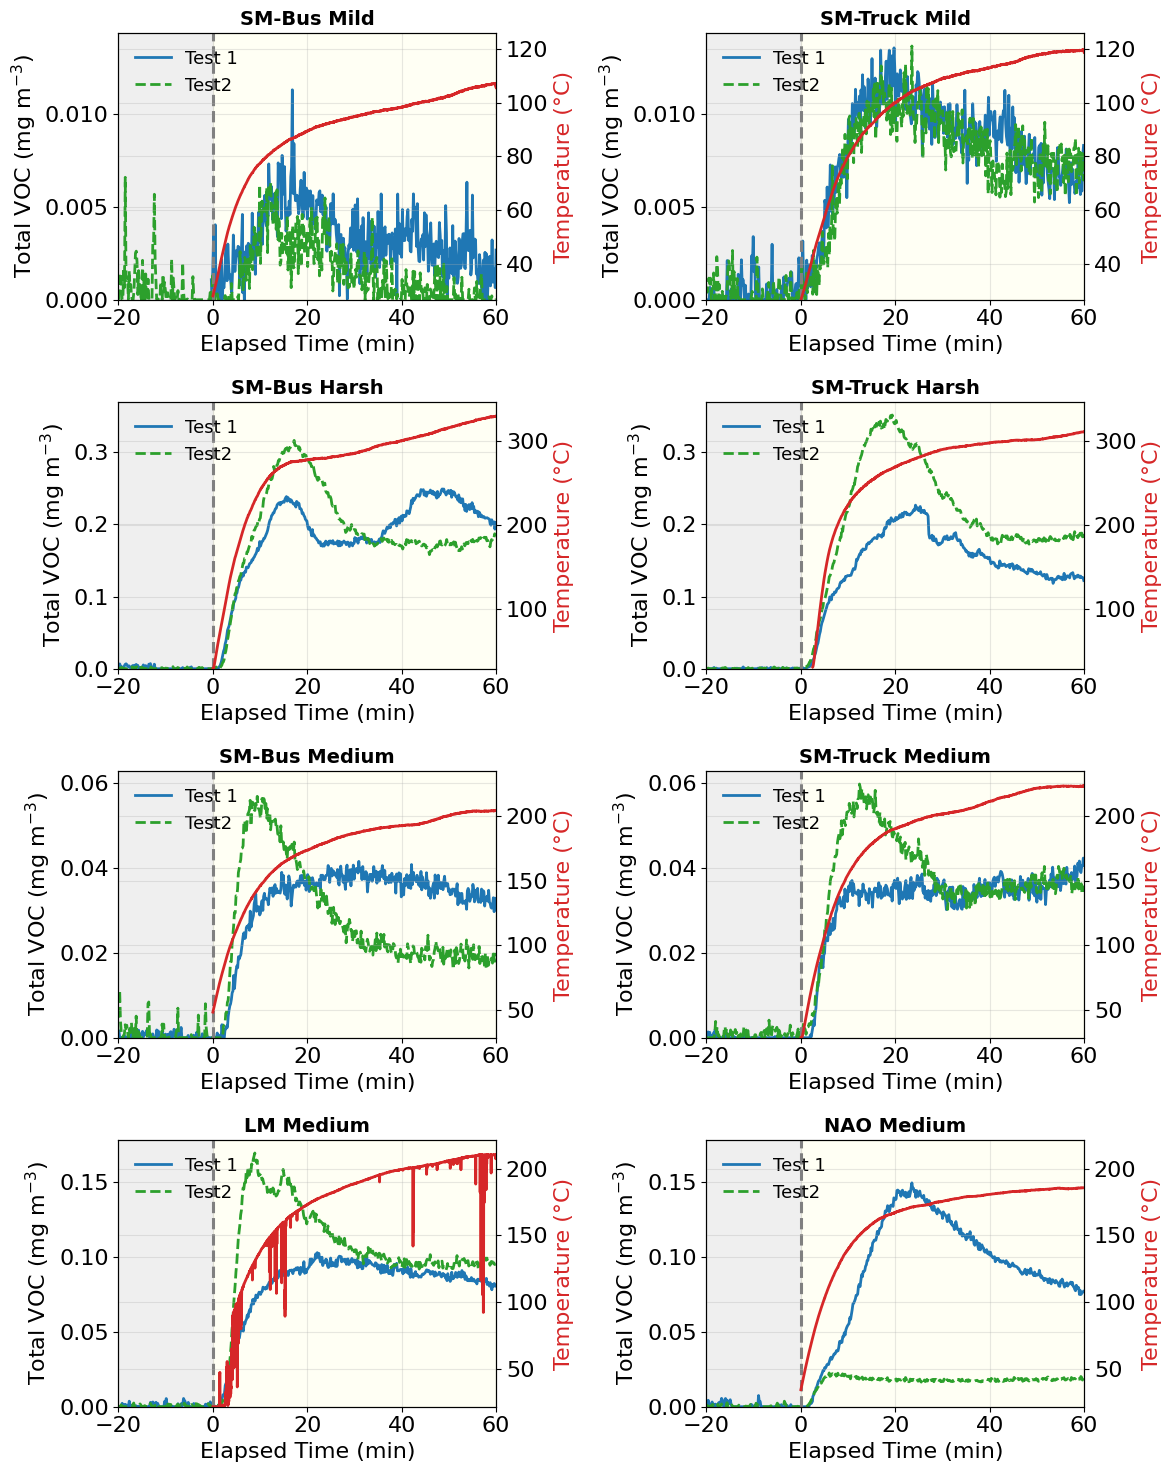

In [79]:
# ==========================================================
# PLOT
# ==========================================================

fig, axs = plt.subplots(4, 2, figsize=(12, 15))

for ax, d in zip(axs.flat, datasets):

    # VOC data
    elapsed1, voc1 = get_voc(d["voc_zero"])
    elapsed2, voc2 = get_voc(d["rep_zero"])

    # Temperature data
    temp_elapsed, temp = get_temperature(
        d["temp_df"], d["temp_zero"]
    )

    # Background and experiment regions
    ax.axvspan(-20, 0, color="lightgray", alpha=0.35)
    ax.axvspan(0, 60, color="lightyellow", alpha=0.35)

    # VOC
    ax.plot(
        elapsed1, voc1,
        color="tab:blue", linewidth=2, label="Test 1"
    )

    ax.plot(
        elapsed2, voc2,
        color="tab:green", linestyle="--",
        linewidth=2, label="Test2"
    )

    ax.set_xlim(-20, 60)
    ax.set_ylim(row_limits[d["row"]]["voc"])
    ax.axvline(0, color="gray", linestyle="--")

    ax.set_title(
        d["title"], fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Elapsed Time (min)")
    ax.set_ylabel(r"Total VOC (mg m$^{-3}$)")

    # Temperature
    ax2 = ax.twinx()
    ax2.plot(
        temp_elapsed, temp,
        color="tab:red", linewidth=2
    )

    ax2.set_ylim(row_limits[d["row"]]["temp"])
    ax2.set_ylabel("Temperature (°C)", color="tab:red")

    ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

## **VOCs TIME PROFILES & BRAKE ENERGY**

In [80]:
# --- Dataset configuration --- #
datasets = [
    {"label": "Harsh", "voc_start": "2025-02-25 09:23:00", "voc_end": "2025-02-25 11:03:00", "voc_zero": "2025-02-25 09:43:50", "vehicle": "HDV1", "rep_start": "2025-03-04 09:50:00", "rep_end": "2025-03-04 11:26:00", "rep_zero": "2025-03-04 10:06:00"},
    {"label": "Medium", "voc_start": "2025-02-11 11:08:00", "voc_end": "2025-02-11 12:28:00", "voc_zero": "2025-02-11 11:28:00", "vehicle": "HDV1", "rep_start": "2025-02-19 10:14:00", "rep_end": "2025-02-19 11:34:00", "rep_zero": "2025-02-19 10:34:00"},
    {"label": "Mild", "voc_start": "2025-02-24 10:51:00", "voc_end": "2025-02-24 12:31:00", "voc_zero": "2025-02-24 11:11:00", "vehicle": "HDV1", "rep_start": "2025-02-27 09:49:00", "rep_end": "2025-02-27 11:39:00", "rep_zero": "2025-02-27 10:19:00"},

    {"label": "Harsh", "voc_start": "2025-02-25 15:05:00", "voc_end": "2025-02-25 16:45:00", "voc_zero": "2025-02-25 15:25:00", "vehicle": "HDV2", "rep_start": "2025-03-04 15:45:00", "rep_end": "2025-03-04 17:25:00", "rep_zero": "2025-03-04 16:05:00"},
    {"label": "Medium", "voc_start": "2025-02-12 10:46:00", "voc_end": "2025-02-12 12:06:00", "voc_zero": "2025-02-12 11:06:00", "vehicle": "HDV2", "rep_start": "2025-02-13 11:37:00", "rep_end": "2025-02-13 12:57:00", "rep_zero": "2025-02-13 11:57:00"},
    {"label": "Mild", "voc_start": "2025-02-24 16:32:00", "voc_end": "2025-02-24 18:12:00", "voc_zero": "2025-02-24 16:52:00", "vehicle": "HDV2", "rep_start": "2025-02-27 15:44:00", "rep_end": "2025-02-27 17:24:00", "rep_zero": "2025-02-27 16:04:00"},

    # LDV1 and LDV2 datasets
    {"label": "LDV2 Medium", "voc_start": "2025-03-31 09:54:00", "voc_end": "2025-03-31 11:14:00", "voc_zero": "2025-03-31 10:14:50", "vehicle": "LDV2", "rep_start": "2025-04-01 10:05:00", "rep_end": "2025-04-01 11:26:00", "rep_zero": "2025-04-01 10:25:05"},
     {"label": "LDV1 Medium", "voc_start": "2025-03-10 11:26:00", "voc_end": "2025-03-10 12:46:00", "voc_zero": "2025-03-10 11:46:00", "vehicle": "LDV1", "rep_start": "2025-03-11 10:14:00", "rep_end": "2025-03-11 11:34:00", "rep_zero": "2025-03-11 10:34:00"}


]

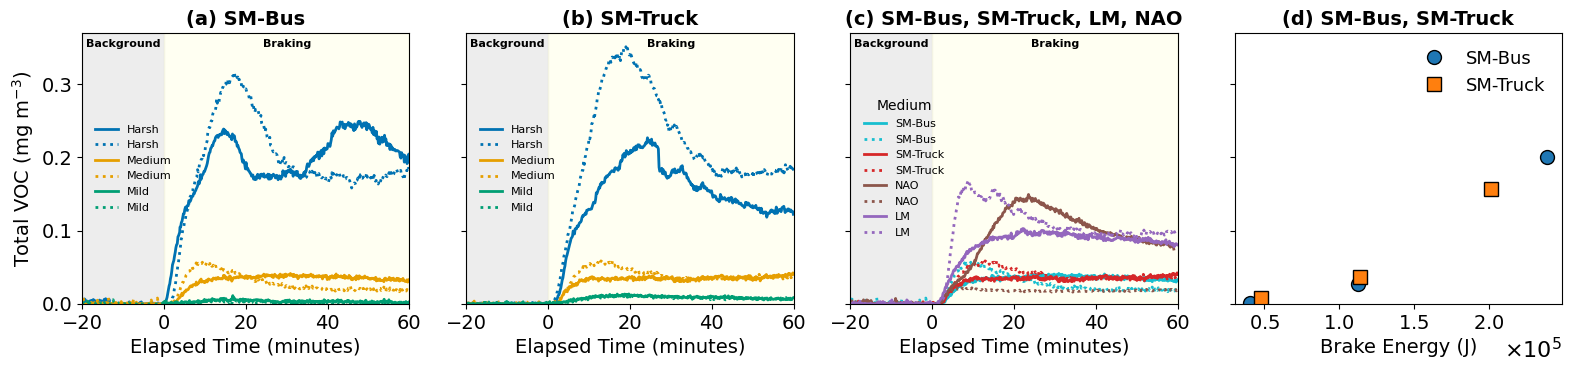

In [81]:
# --- Figure setup ---
fig, axs = plt.subplots(1, 4, figsize=(16,4), sharey=True)
fig.subplots_adjust(wspace=0.25)


# --- Plot time window ---
background_start = -20
brake_duration = 60

# --- Color maps ---
medium_colors = {"HDV1 Medium":"tab:cyan","HDV2 Medium":"tab:red",
                 "LDV1 Medium":"tab:purple","LDV2 Medium":"tab:brown"}

condition_colors = {"Harsh":"#0072B2","Medium":"#E69F00","Mild":"#009E73"}

vehicle_display = {"HDV1":"SM-Bus","HDV2":"SM-Truck","LDV1":"LM","LDV2":"NAO"}

global_yvals = []

# ---------------------------
# PLOTTING FUNCTION
# ---------------------------
def plot_vehicle(ax, veh_label, veh_datasets, custom_colors=None,
                 simplify_labels=False, show_ylabel=True):

    for d in veh_datasets:
        label_for_color = d["label"] if "LDV" in d["vehicle"] else f'{d["vehicle"]} Medium'
        color_map = custom_colors if custom_colors else condition_colors

        for kind, (s,e,z) in {"Test 1":(d["voc_start"],d["voc_end"],d["voc_zero"]),
                              "Test 2":(d["rep_start"],d["rep_end"],d["rep_zero"])}.items():

            if s is None or e is None or z is None:
                continue

            s,e,z = map(pd.to_datetime,(s,e,z))
            df = VMR_mg.loc[s:e].select_dtypes(include="number")

            elapsed = (df.index - z).total_seconds()/60
            voc = df.sum(axis=1).clip(lower=0)

            mask = (elapsed >= background_start) & (elapsed <= brake_duration)
            style = "dotted" if kind=="Test 2" else "solid"

            if simplify_labels:
                legend_label = f'{vehicle_display[d["vehicle"]]}'
                color = color_map[label_for_color]
            else:
                legend_label = f'{d["label"]}'
                color = color_map[d["label"]]

            ax.plot(elapsed[mask], voc[mask],
                    color=color, linestyle=style,
                    linewidth=2, label=legend_label)

            global_yvals.append(voc[mask])

    ax.axvspan(background_start,0,color="lightgray",alpha=0.4)
    ax.axvspan(0,brake_duration,color="lightyellow",alpha=0.4)

    ax.set_xlim(background_start,brake_duration)
    ax.set_title(veh_label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Elapsed Time (minutes)", fontsize=14)

    if show_ylabel:
        ax.set_ylabel(r"Total VOC (mg m$^{-3}$)", fontsize=14)

    ax.tick_params(labelsize=14)
    ax.grid(False)

    if custom_colors:
        ax.legend(fontsize=8, frameon=False, loc='center left',
                  bbox_to_anchor=(0.01, 0.5), title="Medium", title_fontsize=10)
    else:
        ax.legend(fontsize=8, frameon=False, loc='center left',
                  bbox_to_anchor=(0.01, 0.5))


# ---------------------------
# DATA GROUPS
# ---------------------------
veh_HDV1 = [d for d in datasets if d["vehicle"]=="HDV1"]
veh_HDV2 = [d for d in datasets if d["vehicle"]=="HDV2"]
veh_medium = [d for d in datasets if d["label"]=="Medium" or d["label"] in ("LDV1 Medium","LDV2 Medium")]

# ---------------------------
# PANELS (a–c)
# ---------------------------
plot_vehicle(axs[0], "(a) SM-Bus", veh_HDV1, show_ylabel=True)
plot_vehicle(axs[1], "(b) SM-Truck", veh_HDV2, show_ylabel=False)
plot_vehicle(axs[2], "(c) SM-Bus, SM-Truck, LM, NAO",
             veh_medium, custom_colors=medium_colors,
             simplify_labels=True, show_ylabel=False)

# ---------------------------
# PANEL (d) — ENERGY PLOT
# ---------------------------
conditions = ["Mild", "Medium", "Harsh"]
energy_bus = np.array([40165, 112891, 238745])     # SM-Bus (HDV1)
energy_truck = np.array([47778, 114156, 201087])  # SM-Truck (HDV2)

def mean_voc_40_60(df, start_time):
    df = df.select_dtypes(include="number")
    elapsed = (df.index - start_time).total_seconds() / 60
    mask = (elapsed >= 40) & (elapsed <= 60)
    return df.loc[mask].sum(axis=1).mean()

def get_vehicle_condition_value(vehicle, cond):
    filtered = [
        d for d in datasets
        if d["vehicle"] == vehicle
        and cond in d["label"]
        and d["voc_zero"] is not None
        and d["rep_zero"] is not None
    ]

    if not filtered:
        return np.nan

    d = filtered[0]

    t1_start = pd.to_datetime(d["voc_zero"])
    t2_start = pd.to_datetime(d["rep_zero"])

    t1 = mean_voc_40_60(VMR_mg.loc[t1_start:], t1_start)
    t2 = mean_voc_40_60(VMR_mg.loc[t2_start:], t2_start)

    return np.mean([t1, t2])

hdv1_vals = np.array([get_vehicle_condition_value("HDV1", c) for c in conditions])
hdv2_vals = np.array([get_vehicle_condition_value("HDV2", c) for c in conditions])

# Sort for proper plotting
bus_sort = np.argsort(energy_bus)
truck_sort = np.argsort(energy_truck)

energy_bus, hdv1_vals = energy_bus[bus_sort], hdv1_vals[bus_sort]
energy_truck, hdv2_vals = energy_truck[truck_sort], hdv2_vals[truck_sort]

ax4 = axs[3]

ax4.plot(energy_bus, hdv1_vals,
         marker='o', markersize=10,
         markeredgecolor='black', markeredgewidth=1,
         linestyle='None', label="SM-Bus")

ax4.plot(energy_truck, hdv2_vals,
         marker='s', markersize=10,
         markeredgecolor='black', markeredgewidth=1,
         linestyle='None', label="SM-Truck")

ax4.set_xlabel("Brake Energy (J)", fontsize=14)
#ax4.set_ylabel("Mean VOC (mg m$^{-3}$)", fontsize=14)
ax4.set_title("(d) SM-Bus, SM-Truck", fontsize=14, fontweight="bold")

ax4.legend(frameon=False)
ax4.grid(False)
ax4.tick_params(labelsize=14)

# ---------------------------
# GLOBAL Y-LIMITS (ONLY a–c)
# ---------------------------
if global_yvals:
    ymin = min(v.min() for v in global_yvals)
    ymax = max(v.max() for v in global_yvals) * 1.05

    for ax in axs[:3]:
        ax.set_ylim(ymin, ymax)

    for ax in axs[:3]:
        ax.text(background_start/2, ymax*0.95, "Background",
                ha="center", fontsize=8, fontweight="bold")
        ax.text(brake_duration/2, ymax*0.95, "Braking",
                ha="center", fontsize=8, fontweight="bold")
from matplotlib.ticker import ScalarFormatter

# Scientific notation for x-axis sublot d
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # always use scientific notation

ax4.xaxis.set_major_formatter(formatter)
ax4.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
# ---------------------------
# FINAL
# ---------------------------
plt.tight_layout()
plt.show()

# **BTEX COMPOUNDS**

In [82]:
# VOC compounds of interest
compounds = ["C6H6", "C8H10", "C7H8", "C6H6O"]

results = []

for ds in datasets:
    means = []

    # --- VOC window ---
    if ds["voc_zero"] is not None:
        voc_zero = pd.to_datetime(ds["voc_zero"])
        voc_slice = VMR_mg.loc[
            voc_zero + pd.Timedelta(minutes=40):
            voc_zero + pd.Timedelta(minutes=60),
            compounds
        ].where(lambda x: x > 0)

        means.append(voc_slice.mean())

    # --- REP window ---
    if ds["rep_zero"] is not None:
        rep_zero = pd.to_datetime(ds["rep_zero"])
        rep_slice = VMR_mg.loc[
            rep_zero + pd.Timedelta(minutes=40):
            rep_zero + pd.Timedelta(minutes=60),
            compounds
        ].where(lambda x: x > 0)

        means.append(rep_slice.mean())

    # --- Average VOC + REP means ---
    if len(means) > 0:
        combined_mean = pd.concat(means, axis=1).mean(axis=1)

        result_entry = {"label": f"{ds['vehicle']} {ds['label']}"}
        result_entry.update(combined_mean.to_dict())
        results.append(result_entry)

# Final dataframe
mean_results_df = pd.DataFrame(results)
mean_results_df.set_index("label", inplace=True)

print(mean_results_df)

                      C6H6     C8H10      C7H8     C6H6O
label                                                   
HDV1 Harsh        0.000698  0.000282  0.000465  0.001109
HDV1 Medium       0.000034  0.000031  0.000029  0.000520
HDV1 Mild         0.000030  0.000021  0.000026  0.000074
HDV2 Harsh        0.000228  0.000215  0.000313  0.001105
HDV2 Medium       0.000042  0.000037  0.000037  0.000710
HDV2 Mild         0.000029  0.000017  0.000049  0.000126
LDV2 LDV2 Medium  0.000159  0.000160  0.000231       NaN
LDV1 LDV1 Medium  0.000062  0.000049  0.000055       NaN


In [83]:
# Compute benzene ratios
# C6H6 / C7H8 and C6H6 / C8H10
mean_results_df["C6H6/C6H6"] = mean_results_df["C6H6"] / mean_results_df["C6H6"]
mean_results_df["C7H8/C6H6"] = mean_results_df["C7H8"] / mean_results_df["C6H6"]
mean_results_df["C8H10/C6H6"] = mean_results_df["C8H10"] / mean_results_df["C6H6"]
#mean_results_df["C7H6O/C6H6"] = mean_results_df["C7H6O"] / mean_results_df["C6H6"]

# Optionally, you can round for readability
ratio_df = mean_results_df[["C6H6/C6H6","C7H8/C6H6", "C8H10/C6H6"]].round(2) #"C7H6O/C6H6"

print(ratio_df)


                  C6H6/C6H6  C7H8/C6H6  C8H10/C6H6
label                                             
HDV1 Harsh              1.0       0.67        0.40
HDV1 Medium             1.0       0.86        0.93
HDV1 Mild               1.0       0.85        0.68
HDV2 Harsh              1.0       1.38        0.94
HDV2 Medium             1.0       0.89        0.90
HDV2 Mild               1.0       1.67        0.57
LDV2 LDV2 Medium        1.0       1.45        1.00
LDV1 LDV1 Medium        1.0       0.89        0.79


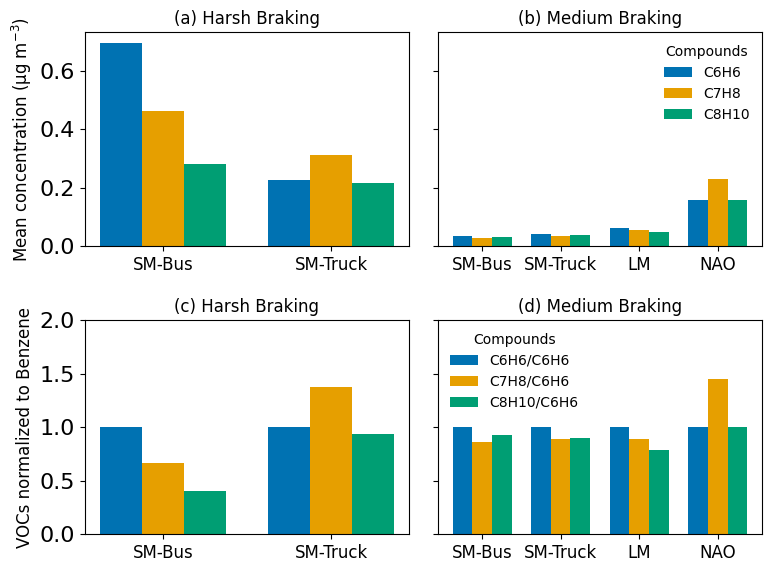

In [84]:
vehicle_labels = {
    "HDV1": "SM-Bus",
    "HDV2": "SM-Truck",
    "LDV1": "LM",
    "LDV2": "NAO"
}
# --- Settings ---
ratio_compounds = ["C6H6/C6H6", "C7H8/C6H6", "C8H10/C6H6"]
mean_compounds = ["C6H6", "C7H8", "C8H10"]
colors = ["#0072B2", "#E69F00", "#009E73"]

vehicles_med = ["HDV1", "HDV2", "LDV1", "LDV2"]
vehicles_harsh = ["HDV1", "HDV2"]

width = 0.25
fs = 12  # global font size

# --- Helper function ---
def plot_panel(ax, df, vehicles, compounds, title, ylabel=None, scale=1):
    x = np.arange(len(vehicles))

    for i, comp in enumerate(compounds):
        values = [
            (df[df.index.str.contains(v)][comp].values[0] * scale)
            if not df[df.index.str.contains(v)].empty else np.nan
            for v in vehicles
        ]
        ax.bar(x + i*width, values, width=width, color=colors[i], label=comp)

    ax.set_xticks(x + width)
    ax.set_xticklabels([vehicle_labels[v] for v in vehicles], fontsize=fs)
    ax.set_title(title, fontsize=fs)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fs)

    ax.grid(False)

# --- Data filtering ---
medium_mean = mean_results_df[mean_results_df.index.str.contains("Medium")]
harsh_mean = mean_results_df[mean_results_df.index.str.contains("Harsh")]
medium_ratio = ratio_df[ratio_df.index.str.contains("Medium")]
harsh_ratio = ratio_df[ratio_df.index.str.contains("Harsh")]

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey='row')

# Top row: Mean
plot_panel(
    axes[0, 0], harsh_mean, vehicles_harsh, mean_compounds,
    "(a) Harsh Braking",ylabel="Mean concentration (μg m$^{-3}$)", scale=1000
)
plot_panel(
    axes[0, 1], medium_mean, vehicles_med, mean_compounds,
    "(b) Medium Braking", scale=1000
)

# Bottom row: Ratios

plot_panel(
    axes[1, 0], harsh_ratio, vehicles_harsh, ratio_compounds,
    "(c) Harsh Braking", ylabel="VOCs normalized to Benzene"
)
plot_panel(
    axes[1, 1], medium_ratio, vehicles_med, ratio_compounds,
    "(d) Medium Braking"
)

# --- Shared y-limits for ratios ---
for ax in axes[1, :]:
    ax.set_ylim(0, 2.0)

# --- Legends (only right panels) ---
axes[0, 1].legend(title="Compounds", frameon=False, fontsize=10, title_fontsize=10)
axes[1, 1].legend(title="Compounds", frameon=False, fontsize=10, title_fontsize=10)

# --- Layout ---
plt.tight_layout()
plt.show()

# **TOP COMPOUNDS**

In [85]:
VMR_mg.index = pd.to_datetime(VMR_mg.index)

In [86]:
def top_40_compounds(df, voc_zero_time):
    voc_zero_time = pd.to_datetime(voc_zero_time)

    start_time = voc_zero_time + pd.Timedelta(minutes=40)
    end_time   = voc_zero_time + pd.Timedelta(minutes=60)

    window_df = df.loc[start_time:end_time]

    if window_df.empty:
        raise ValueError(f"No data between {start_time} and {end_time}")

    return window_df.mean(numeric_only=True).nlargest(40)

In [87]:
results = []

for d in datasets:
    # ORIGINAL
    label_orig = f"{d['vehicle']} Original ({d['label']})"
    print(f"\nTop 40 compounds — {label_orig}")

    top40_orig = top_40_compounds(VMR_mg, voc_zero_time=d["voc_zero"])
    print(top40_orig)

    for compound, value in top40_orig.items():
        results.append({
            "Vehicle": d["vehicle"],
            "Label": d["label"],
            "Test": "Original",
            "Compound": compound,
            "Mean_VMR": value
        })

    # REPEAT
    label_rep = f"{d['vehicle']} Repeat ({d['label']})"
    print(f"\nTop 40 compounds — {label_rep}")

    top40_rep = top_40_compounds(VMR_mg, voc_zero_time=d["rep_zero"])
    print(top40_rep)

    for compound, value in top40_rep.items():
        results.append({
            "Vehicle": d["vehicle"],
            "Label": d["label"],
            "Test": "Repeat",
            "Compound": compound,
            "Mean_VMR": value
        })

top40_df = pd.DataFrame(results)


Top 40 compounds — HDV1 Original (Harsh)
C2H5NO             0.016795
C5H4N              0.010385
C12H30N4O3S5Si4    0.010244
C7H5N              0.008347
C7H7NO             0.008138
C2H3N              0.006724
C2H4O2             0.005649
C2H7NO2            0.003696
C5H8O2             0.003535
C3H5NO             0.003313
C4H6O2             0.002603
C24H13N7O5SSi2     0.002451
C5H4O2             0.002394
C4H6O              0.002382
C12H31NO6S4Si5     0.002181
CH6O2              0.002054
C3H10Si2           0.002041
C8H8O              0.002012
C4H9NO             0.001942
C3H10N3O2          0.001787
C5H8O3             0.001738
C4H10O2            0.001631
C5H10O             0.001630
C5H10O3            0.001622
C3H9Si             0.001570
C7H6O2             0.001525
C7H6O              0.001444
C5H8O              0.001444
C18H8N2O12S        0.001384
C4H8O3             0.001332
C8H16O             0.001278
C7H14O             0.001257
C5H12O2            0.001234
C6H10O2            0.001226
C6H12O

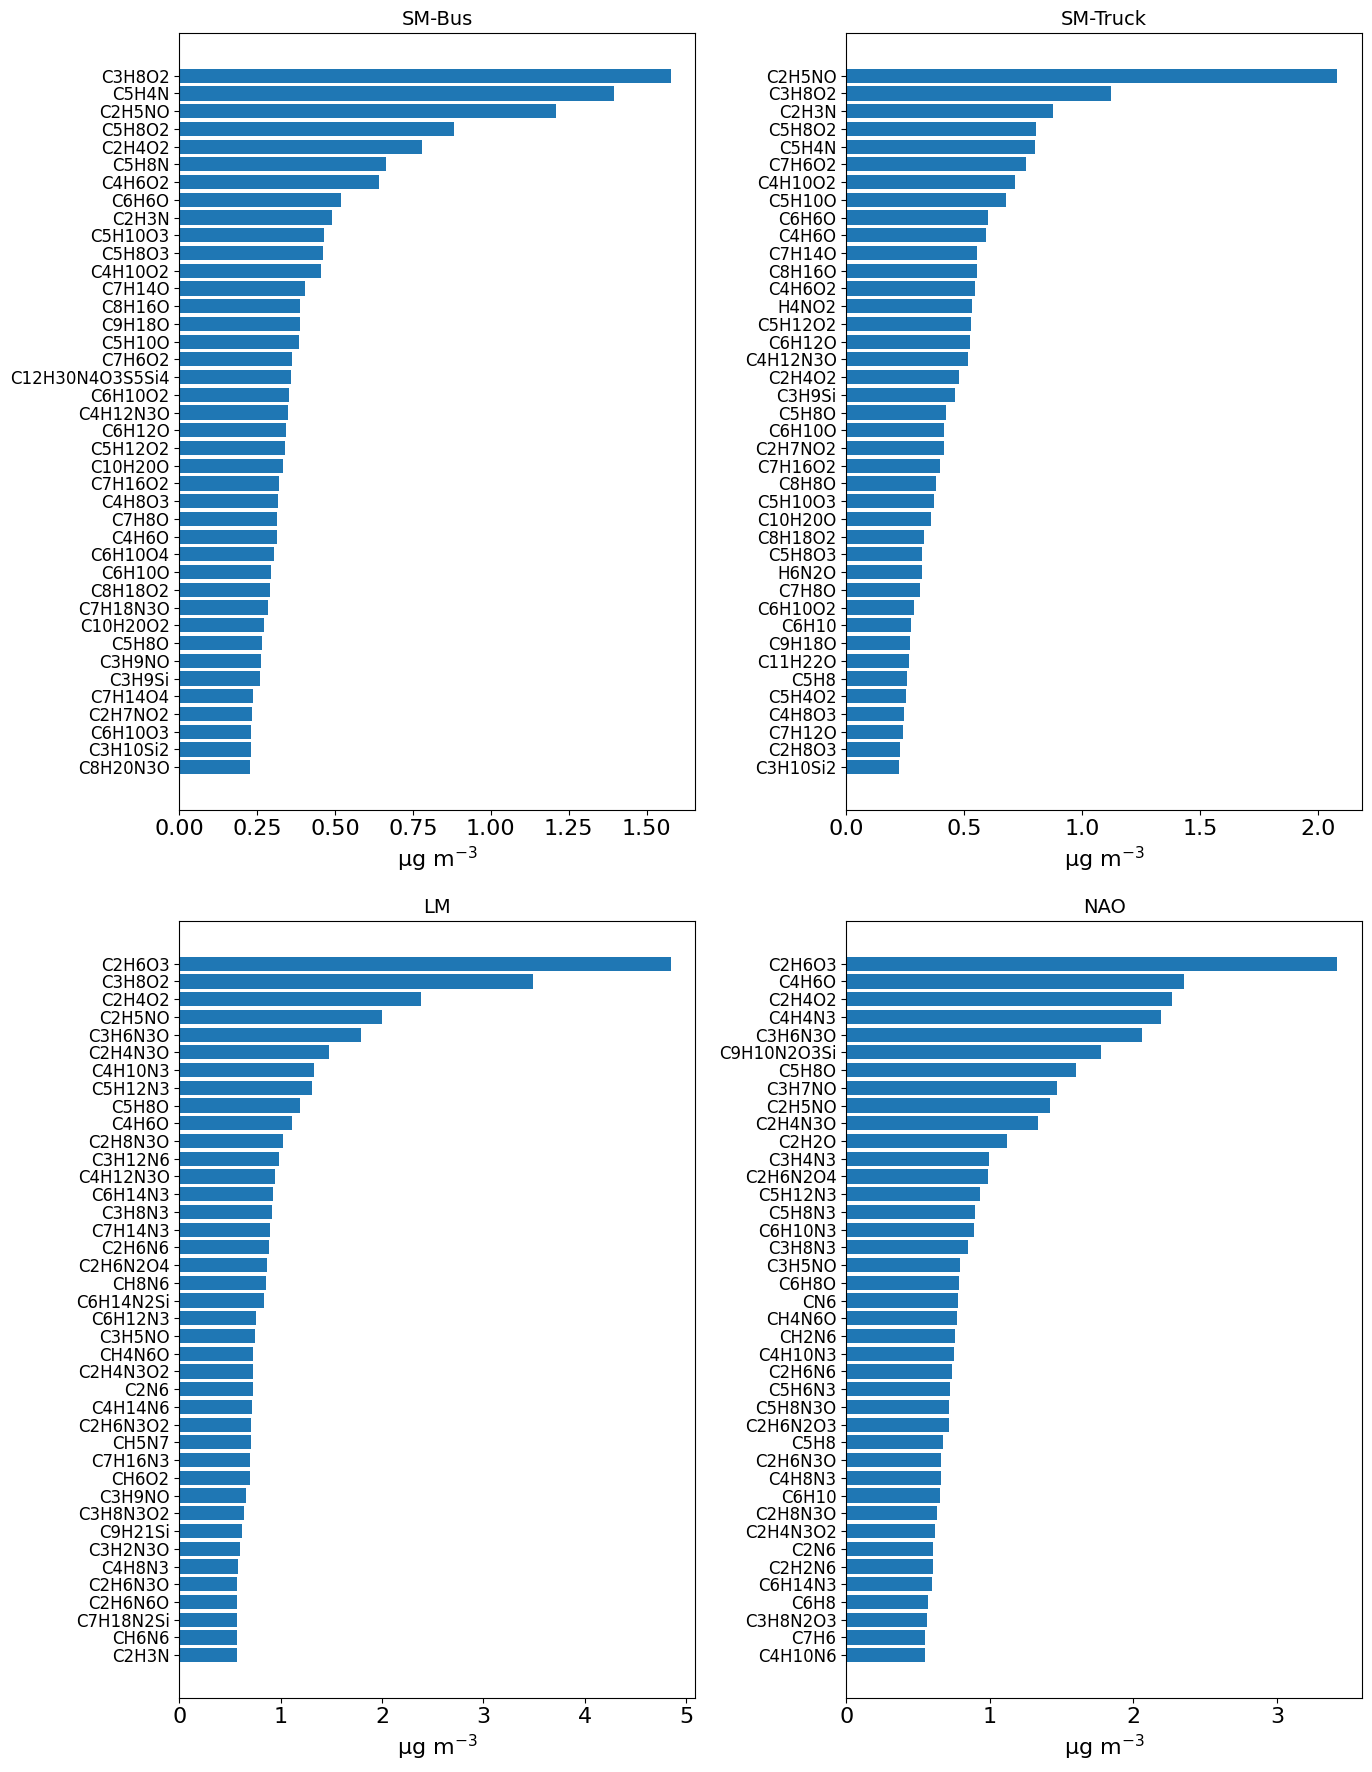

In [88]:
def plot_top40(ax, vehicle, label, title):
    df = top40_df[
        (top40_df["Vehicle"] == vehicle) &
        (top40_df["Label"] == label) &
        (top40_df["Test"] == "Original")
    ]

    top40 = df.sort_values("Mean_VMR", ascending=False).head(40)

    ax.barh(top40["Compound"], top40["Mean_VMR"] * 1000)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r"µg m$^{-3}$")
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)


fig, axs = plt.subplots(2, 2, figsize=(14, 18))

plot_top40(axs[0, 0], "HDV1", "Medium", "SM-Bus")
plot_top40(axs[0, 1], "HDV2", "Medium", "SM-Truck")
plot_top40(axs[1, 0], "LDV1", "LDV1 Medium", "LM")
plot_top40(axs[1, 1], "LDV2", "LDV2 Medium", "NAO")

plt.tight_layout()
plt.show()

# **PARTICLE SIZE DISTRIBUTION FROM THE GRIMM OPC & SAMPLING LOSS CORRECTION**

## **LOAD ALL PARTICLE DATA**

In [89]:
folder_path = '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM'
file_paths = sorted(glob.glob(os.path.join(folder_path, '*.opr')))

In [90]:
file_paths

['/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-06.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-11.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-12.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-13.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-18.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-19.opr',
 '/content/drive/My Drive/Colab Notebooks/BRAKE WEAR CAMPAIGN 2025/Vocus PTR/2025 Brake Wear Campaign/DATA/GRIMM/Tribo-1-2025-02-24.opr',
 '/content/drive/My Drive/Colab No

In [91]:

# Initial raw column names
raw_columns = ['Date', '0.28', '0.3', '0.35', '0.4', '0.45', '0.5', '0.58', '0.65', '0.7',
               '0.8', '1', '1.3', '1.6', '2', '2.5', '2.5R', '3', '3.5', '4', '5', '6.5', '7.5',
               '8.5', '10', '12.5', '15', '17.5', '20', '25', '30', '32', 'CF']

dfs = []

for path in file_paths:
    with open(path, 'r') as f:
        content = f.read()

    df = pd.read_csv(io.StringIO(content), sep='\t', header=None)
    df.columns = raw_columns

    # Extract '0.25' bin and new date renamed to 'Dates'
    df[['Dates', '0.25']] = df['Date'].str.rsplit(' ', n=1, expand=True)
    df['0.25'] = pd.to_numeric(df['0.25'], errors='coerce')

    # Reorder columns to put Dates and 0.25 after Date
    df.insert(1, 'Dates', df.pop('Dates'))
    df.insert(2, '0.25', df.pop('0.25'))

    # Drop unnecessary columns
    df = df.drop(['Date', '2.5R', 'CF'], axis=1)

    # Convert 'Dates' to datetime and set index
    df['Dates'] = pd.to_datetime(df['Dates'], format='%Y %m %d %H %M %S.%f').dt.round('1s')
    df = df.set_index('Dates')

    dfs.append(df)

# Concatenate all DataFrames and sort by datetime index
df_GRIMM = pd.concat(dfs).sort_index()

# Define bin edges
columns_lower = ['250', '280', '300', '350', '400', '450', '500', '580', '650', '700', '800', '1000', '1300',
                 '1600', '2000', '2500', '3000', '3500', '4000', '5000', '6500', '7500', '8500', '10000', '12500',
                 '15000', '17500', '20000', '25000', '30000', '32000']
columns_upper = ['280', '300', '350', '400', '450', '500', '580', '650', '700', '800', '1000', '1300', '1600',
                 '2000', '2500', '3000', '3500', '4000', '5000', '6500', '7500', '8500', '10000', '12500', '15000',
                 '17500', '20000', '25000', '30000', '32000', '36000']

midpoints = [(float(columns_lower[i]) + float(columns_upper[i])) / 2 for i in range(len(columns_lower))]
new_columns = [f"{mid:.2f}" for mid in midpoints]

df_GRIMM.columns = new_columns

df_GRIMM.head()

,265.00,290.00,325.00,375.00,425.00,475.00,540.00,615.00,675.00,750.00,...,8000.00,9250.00,11250.00,13750.00,16250.00,18750.00,22500.00,27500.00,31000.00,34000.00
Dates,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:58:28,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-06 09:58:34,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-06 09:58:40,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-06 09:58:46,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-06 09:58:52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **GET ACTUAL CONCETRATIONS IN BINS IN No/CM3**


The concentratios are cumulative, we need to get actual

In [92]:
# Convert column names (bin midpoints) to numeric
df_GRIMM.columns = pd.to_numeric(df_GRIMM.columns)

# Create a copy to store converted values in particles/cm³
df_GRIMM_actual = df_GRIMM.copy()
columns = df_GRIMM.columns

# Convert # particles per 100 mL to per cm³ by computing the difference between adjacent bins and dividing by 100.
#The initial concetrations were recorded as cumulative from larger bins towards smaller bins
#So the first bin is a sum of all the 31 bins. we subtract to get actual per bin
for i in range(len(columns) - 1):
    df_GRIMM_actual[columns[i]] = (df_GRIMM[columns[i]] - df_GRIMM[columns[i + 1]]) / 100

# For the last bin, just divide by 100
df_GRIMM_actual[columns[-1]] = df_GRIMM[columns[-1]] / 100

# Ensure datetime index
df_GRIMM_actual.index = pd.to_datetime(df_GRIMM_actual.index)
# Display final result
df_GRIMM_actual.head()


,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,8000.0,9250.0,11250.0,13750.0,16250.0,18750.0,22500.0,27500.0,31000.0,34000.0
Dates,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:58:28,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:34,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:40,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:46,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:52,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
#Slice to remain with PM10
df_GRIMM_actual = df_GRIMM_actual.drop(columns=df_GRIMM_actual.columns[df_GRIMM_actual.columns.get_loc(11250.0):])
df_GRIMM_actual

,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,1800.0,2250.0,2750.0,3250.0,3750.0,4500.0,5750.0,7000.0,8000.0,9250.0
Dates,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:58:28,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:34,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:40,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:46,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:52,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01 16:56:42,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-01 16:56:48,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-01 16:56:54,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
print(df_GRIMM_actual.columns.tolist())

[265.0, 290.0, 325.0, 375.0, 425.0, 475.0, 540.0, 615.0, 675.0, 750.0, 900.0, 1150.0, 1450.0, 1800.0, 2250.0, 2750.0, 3250.0, 3750.0, 4500.0, 5750.0, 7000.0, 8000.0, 9250.0]


## **Mass distribution BEFORE Sampling Losses Correction**

In [95]:
# Copy number distribution (already in #/cm³)
df_mass_pre = df_GRIMM_actual.copy()

# Convert diameters (nm → cm)
diameters = df_mass_pre.columns.values
diam_cm = diameters * 1e-7

# Particle volume (cm³ per particle)
particle_volumes = (np.pi / 6) * (diam_cm ** 3)

# Step 1: volume distribution (cm³ particles / cm³ air)
df_volume_pre = df_mass_pre * particle_volumes

# Step 2: convert cm³ particles / cm³ air to per m³ of air
df_volume_pre_m3 = df_volume_pre * 1e6

# Step 3: apply density (mg/cm³)
density = 750  # mg/cm3; this value is assumed from Ulf Ulofson paper, then we shall calculate the density correction factor based on this value
df_mass_pre = df_volume_pre_m3 * density

# Result: mass distribution in mg/m³
df_mass_pre.head()

,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,1800.0,2250.0,2750.0,3250.0,3750.0,4500.0,5750.0,7000.0,8000.0,9250.0
Dates,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:58:28,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:34,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:40,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:46,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:52,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **GRIMM PM10 LOSS CORRECTION**

First we determine the GRIMM particle loss using the Max Plank Institute Particle Loss Calculator. Then we use the GRIMM loss results from MPI calculator to correct the number concentration and reconstruct the "true" size distribution.

In [96]:
# Copy original dataframe to avoid overwriting raw data
df_GRIMM_corrected = df_GRIMM_actual.copy()

# Define loss (%) explicitly for EACH bin (nm)
loss_percent = {
    265.0: 1,
    290.0: 1,
    325.0: 1,
    375.0: 1,
    425.0: 1,
    475.0: 1,
    540.0: 1,
    615.0: 1,
    675.0: 1,
    750.0: 1,
    900.0: 1,
    1150.0: 2,
    1450.0: 2,
    1800.0: 2,
    2250.0: 5,
    2750.0: 5,
    3250.0: 10,
    3750.0: 10,
    4500.0: 12,
    5750.0: 20,
    7000.0: 25,
    8000.0: 30,
    9250.0: 40
}

# Apply correction: N_corrected = N_measured / (1 - Loss/100)
for col in df_GRIMM_corrected.columns:
    loss = loss_percent[col] / 100.0  # convert % → fraction
    df_GRIMM_corrected[col] = df_GRIMM_corrected[col] / (1 - loss)

# df_corrected now contains loss-corrected number concentrations
df_GRIMM_corrected

,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,1800.0,2250.0,2750.0,3250.0,3750.0,4500.0,5750.0,7000.0,8000.0,9250.0
Dates,,,,,,,,,,,,,,,,,,,,,
2025-02-06 09:58:28,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:34,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:40,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:46,0.151515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-02-06 09:58:52,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01 16:56:42,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-01 16:56:48,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-01 16:56:54,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
# verifying to see that the data has been corrected corrected. compare df_GRIMM_actual and df_corrected
# Slice the desired time range
df_subset1 = df_GRIMM_actual.loc["2025-02-25 15:30:00":"2025-02-25 16:25:00"]

# Display result
#df_subset1

In [98]:
# Slice the desired time range
df_subset2 = df_GRIMM_corrected.loc["2025-02-25 15:30:00":"2025-02-25 16:25:00"]

# Display result
#df_subset2

## **PM10 MASS CALCULATIONS**
We assume that the density of SM brake pads is 0.75g/cm3. However, this value should be determined later experimentally and changed.

In [99]:
#We recall the GRIMM data frame
#df_GRIMM_actual.head(10)

In [100]:
#Establish a separate PM10 volume data frame
df_volume = df_GRIMM_corrected.copy()
#df_volume[:1000]

#calculate volume of particles per cm3 of air
diameters = df_volume.columns
particle_volumes = (np.pi/6)*(diameters * 1e-7)**3 #volume in cm3 since the diameters were in nm
df_volume_distribution = df_volume*particle_volumes #units are cm3/cm3 of air

#convert the Volume distribution to per m3 of air. The units are cm3/m3 of air
df_volume_distribution_m3 = df_volume_distribution * 1e6
#df_volume_distribution_m3[:1000]

## **MASS CONCETRATION**

In [101]:
#Density of brake wear particles

density = 750 # mg/cm³. this value is assumed from Ulf Ulofson paper, then we shall calculate the density correction factor based on this value

#Mass distribution (mg)
df_mass_distribution = df_volume_distribution_m3 * density #cm3/m3 of air x mg/cm3 to get mg/m3
#df_mass_distribution[:1000]

## **DEKATI PM10 IMPACTOR MASS SAMPLING LOSS CORRECTION**

We correct the mass based on the correctd GRIMM data

In [102]:
# Copy original dataframe again (keep corrections independent)
df_Dekati_corrected = df_mass_distribution.copy() # we apply on the corrected GRIMM mass data to find mass loss in the impactor

# Define NEW loss (%) explicitly for EACH bin (nm)
loss_percent_v2 = {
    265.0: 1,
    290.0: 1,
    325.0: 1,
    375.0: 1,
    425.0: 1,
    475.0: 1,
    540.0: 1,
    615.0: 1,
    675.0: 1,
    750.0: 1,
    900.0: 1,
    1150.0: 4,
    1450.0: 4,
    1800.0: 4,
    2250.0: 9,
    2750.0: 9,
    3250.0: 15,
    3750.0: 15,
    4500.0: 20,
    5750.0: 30,
    7000.0: 35,
    8000.0: 40,
    9250.0: 60
}

# Apply correction
for col in df_Dekati_corrected.columns:
    loss = loss_percent_v2[col] / 100.0  # % → fraction
    df_Dekati_corrected[col] = df_Dekati_corrected[col] / (1 - loss)

#df_Dekati_corrected

In [103]:
# Ensure datetime index
df_mass_distribution.index = pd.to_datetime(df_mass_distribution.index)
df_Dekati_corrected.index = pd.to_datetime(df_Dekati_corrected.index)

# Define experiments
experiments = [
    {"label": "MEDIUM HDV1 - Original", "voc_zero": "2025-02-11 11:28:00"},
    {"label": "MEDIUM HDV1 - Repeat",   "voc_zero": "2025-02-19 10:34:00"},
    {"label": "MEDIUM HDV1 - Repeat 2", "voc_zero": "2025-02-06 10:24:00"},

    {"label": "MEDIUM HDV2 - Original", "voc_zero": "2025-02-12 11:06:00"},
    {"label": "MEDIUM HDV2 - Repeat",   "voc_zero": "2025-02-13 11:57:00"},
    {"label": "MEDIUM HDV2 - Repeat 2", "voc_zero": "2025-02-18 10:53:15"},

    {"label": "MEDIUM LDV1 - Original", "voc_zero": "2025-03-10 11:46:00"},
    {"label": "MEDIUM LDV1 - Repeat",   "voc_zero": "2025-03-11 10:34:00"},

    {"label": "MEDIUM LDV2 - Original", "voc_zero": "2025-03-31 10:14:50"},
    {"label": "MEDIUM LDV2 - Repeat",   "voc_zero": "2025-04-01 10:25:05"},
]

# Storage
results_grimm = []
results_dekati = []

# Loop through experiments
for exp in experiments:
    start = pd.to_datetime(exp["voc_zero"])
    end = start + pd.Timedelta(hours=6)

    # Slice data
    grimm_slice = df_mass_distribution.loc[start:end]
    dekati_slice = df_Dekati_corrected.loc[start:end]

    # Mean per bin
    grimm_mean = grimm_slice.mean()
    dekati_mean = dekati_slice.mean()

    # Convert to DataFrame row
    grimm_mean.name = exp["label"]
    dekati_mean.name = exp["label"]

    results_grimm.append(grimm_mean)
    results_dekati.append(dekati_mean)

# Combine into tables
df_grimm_summary = pd.DataFrame(results_grimm)
df_dekati_summary = pd.DataFrame(results_dekati)

# Optional: sort columns (bins) numerically
df_grimm_summary = df_grimm_summary.sort_index(axis=1)
df_dekati_summary = df_dekati_summary.sort_index(axis=1)

# Display
print("GRIMM Mass Distribution (Mean over 6 hours)")
display(df_grimm_summary)

print("\nDekati Mass Distribution (Mean over 6 hours)")
display(df_dekati_summary)

GRIMM Mass Distribution (Mean over 6 hours)


,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,1800.0,2250.0,2750.0,3250.0,3750.0,4500.0,5750.0,7000.0,8000.0,9250.0
MEDIUM HDV1 - Original,0.000007,0.000014,0.000069,0.000193,0.000173,0.000082,0.000219,0.000207,0.000113,0.000167,...,0.000489,0.000342,0.000446,0.001276,0.001139,0.002029,0.001431,0.000509,0.000298,0.000368
MEDIUM HDV1 - Repeat,0.000007,0.000013,0.000062,0.000167,0.000145,0.000068,0.000180,0.000171,0.000095,0.000139,...,0.000434,0.000337,0.000423,0.001180,0.001102,0.002012,0.001459,0.000519,0.000306,0.000327
MEDIUM HDV1 - Repeat 2,0.000007,0.000016,0.000079,0.000205,0.000173,0.000080,0.000205,0.000184,0.000096,0.000136,...,0.000351,0.000286,0.000334,0.000833,0.000773,0.001407,0.000994,0.000371,0.000228,0.000298
MEDIUM HDV2 - Original,0.000010,0.000024,0.000132,0.000358,0.000313,0.000150,0.000398,0.000366,0.000194,0.000276,...,0.000688,0.000432,0.000619,0.001828,0.001578,0.002636,0.001704,0.000542,0.000330,0.000331
MEDIUM HDV2 - Repeat,0.000012,0.000028,0.000153,0.000412,0.000355,0.000169,0.000444,0.000400,0.000209,0.000294,...,0.000710,0.000446,0.000651,0.001830,0.001501,0.002431,0.001535,0.000505,0.000290,0.000337
MEDIUM HDV2 - Repeat 2,0.000011,0.000024,0.000130,0.000354,0.000307,0.000147,0.000392,0.000361,0.000191,0.000271,...,0.000692,0.000436,0.000637,0.001852,0.001546,0.002531,0.001589,0.000540,0.000314,0.000348
MEDIUM LDV1 - Original,0.000006,0.000011,0.000044,0.000128,0.000123,0.000059,0.000157,0.000146,0.000079,0.000118,...,0.000386,0.000310,0.000364,0.000983,0.000931,0.001578,0.001074,0.000402,0.000259,0.000306
MEDIUM LDV1 - Repeat,0.000007,0.000011,0.000044,0.000117,0.000113,0.000058,0.000158,0.000158,0.000090,0.000138,...,0.000486,0.000359,0.000452,0.001269,0.001094,0.001742,0.001076,0.000361,0.000286,0.000368
MEDIUM LDV2 - Original,0.000014,0.000015,0.000038,0.000139,0.000242,0.000169,0.000560,0.000682,0.000417,0.000647,...,0.002179,0.001297,0.002209,0.007202,0.006194,0.011448,0.008712,0.002791,0.001522,0.001512
MEDIUM LDV2 - Repeat,0.000018,0.000024,0.000070,0.000257,0.000360,0.000205,0.000571,0.000569,0.000315,0.000461,...,0.001424,0.000911,0.001445,0.004576,0.003964,0.007240,0.005043,0.001321,0.000749,0.000662



Dekati Mass Distribution (Mean over 6 hours)


,265.0,290.0,325.0,375.0,425.0,475.0,540.0,615.0,675.0,750.0,...,1800.0,2250.0,2750.0,3250.0,3750.0,4500.0,5750.0,7000.0,8000.0,9250.0
MEDIUM HDV1 - Original,0.000007,0.000014,0.000070,0.000195,0.000174,0.000083,0.000221,0.000209,0.000114,0.000168,...,0.000510,0.000375,0.000490,0.001502,0.001340,0.002537,0.002045,0.000783,0.000496,0.000921
MEDIUM HDV1 - Repeat,0.000007,0.000013,0.000063,0.000169,0.000147,0.000069,0.000182,0.000173,0.000096,0.000141,...,0.000452,0.000370,0.000465,0.001388,0.001297,0.002515,0.002085,0.000799,0.000509,0.000817
MEDIUM HDV1 - Repeat 2,0.000007,0.000016,0.000080,0.000207,0.000175,0.000080,0.000208,0.000186,0.000097,0.000137,...,0.000365,0.000314,0.000367,0.000980,0.000909,0.001759,0.001421,0.000570,0.000380,0.000745
MEDIUM HDV2 - Original,0.000011,0.000024,0.000133,0.000362,0.000317,0.000151,0.000403,0.000370,0.000196,0.000279,...,0.000717,0.000475,0.000680,0.002151,0.001856,0.003295,0.002434,0.000834,0.000549,0.000827
MEDIUM HDV2 - Repeat,0.000012,0.000028,0.000154,0.000416,0.000359,0.000170,0.000449,0.000404,0.000211,0.000297,...,0.000739,0.000490,0.000716,0.002153,0.001766,0.003039,0.002194,0.000777,0.000484,0.000842
MEDIUM HDV2 - Repeat 2,0.000011,0.000024,0.000132,0.000357,0.000311,0.000149,0.000395,0.000364,0.000193,0.000274,...,0.000721,0.000479,0.000700,0.002179,0.001819,0.003163,0.002270,0.000831,0.000524,0.000871
MEDIUM LDV1 - Original,0.000006,0.000011,0.000045,0.000129,0.000124,0.000060,0.000158,0.000148,0.000080,0.000119,...,0.000402,0.000340,0.000400,0.001156,0.001096,0.001972,0.001535,0.000619,0.000431,0.000766
MEDIUM LDV1 - Repeat,0.000007,0.000011,0.000044,0.000118,0.000114,0.000058,0.000160,0.000159,0.000091,0.000139,...,0.000506,0.000394,0.000497,0.001493,0.001287,0.002177,0.001537,0.000555,0.000476,0.000921
MEDIUM LDV2 - Original,0.000014,0.000015,0.000038,0.000140,0.000245,0.000171,0.000566,0.000689,0.000421,0.000654,...,0.002270,0.001425,0.002427,0.008473,0.007287,0.014310,0.012446,0.004294,0.002537,0.003781
MEDIUM LDV2 - Repeat,0.000018,0.000024,0.000071,0.000260,0.000364,0.000207,0.000577,0.000575,0.000318,0.000466,...,0.001483,0.001001,0.001588,0.005384,0.004663,0.009050,0.007205,0.002032,0.001249,0.001655


In [104]:
# The Dekati and GRIMM masses are the total mass for all the bins for the 6 hour experimental window
# Sum mass across all bins (row-wise)
grimm_total_mass = df_grimm_summary.sum(axis=1)
dekati_total_mass = df_dekati_summary.sum(axis=1)

# Compute Integrated Mass Efficiency
Efficieny = dekati_total_mass / grimm_total_mass

# Convert to DataFrame for readability
df_efficiency = pd.DataFrame({
    "Dekati_mass (mg/m3)": dekati_total_mass,
    "GRIMM_mass (mg/m3)": grimm_total_mass,
    "Efficiency": Efficieny
})

# Optional: percentage form
#df_efficiency["eta_mass_%"] = df_efficiency["eta_mass"] * 100

# Display
display(df_efficiency)

,Dekati_mass (mg/m3),GRIMM_mass (mg/m3),Efficiency
MEDIUM HDV1 - Original,0.013024,0.010317,1.262336
MEDIUM HDV1 - Repeat,0.012420,0.009792,1.268477
MEDIUM HDV1 - Repeat 2,0.009583,0.007618,1.258009
MEDIUM HDV2 - Original,0.017222,0.014034,1.227201
MEDIUM HDV2 - Repeat,0.016901,0.013878,1.217881
MEDIUM HDV2 - Repeat 2,0.016919,0.013791,1.226832
MEDIUM LDV1 - Original,0.010174,0.008023,1.268076
MEDIUM LDV1 - Repeat,0.011452,0.009070,1.262633
MEDIUM LDV2 - Original,0.065419,0.051106,1.280068
MEDIUM LDV2 - Repeat,0.040334,0.032265,1.250098


In [105]:
# The Dekati and GRIMM masses are the total mass for all the bins for the 6 hour experimental window
#Masses converted from mg/m3 to ug/m3
# Sum mass across all bins (row-wise)
grimm_total_mass = df_grimm_summary.sum(axis=1)
dekati_total_mass = df_dekati_summary.sum(axis=1)

# Convert to ug/m3
grimm_total_mass_ug_m3 = grimm_total_mass * 1000
dekati_total_mass_ug_m3 = dekati_total_mass * 1000

# Compute Integrated Mass Efficiency
Efficiency = dekati_total_mass / grimm_total_mass

# Build DataFrame in consistent units (ug/m3)
df_efficiency = pd.DataFrame({
    "Dekati_mass (ug/m3)": dekati_total_mass_ug_m3,
    "GRIMM_mass (ug/m3)": grimm_total_mass_ug_m3,
    "Efficiency": Efficiency
})

display(df_efficiency)

,Dekati_mass (ug/m3),GRIMM_mass (ug/m3),Efficiency
MEDIUM HDV1 - Original,13.023545,10.317019,1.262336
MEDIUM HDV1 - Repeat,12.420447,9.791619,1.268477
MEDIUM HDV1 - Repeat 2,9.583078,7.617652,1.258009
MEDIUM HDV2 - Original,17.222014,14.033578,1.227201
MEDIUM HDV2 - Repeat,16.901311,13.877640,1.217881
MEDIUM HDV2 - Repeat 2,16.918973,13.790777,1.226832
MEDIUM LDV1 - Original,10.173644,8.022899,1.268076
MEDIUM LDV1 - Repeat,11.451949,9.069897,1.262633
MEDIUM LDV2 - Original,65.419304,51.106107,1.280068
MEDIUM LDV2 - Repeat,40.334438,32.265015,1.250098


## **MASS CORRECTION FACTOR**

In [106]:
# Start from a clean copy
df_GRIMM_correction_factor = df_efficiency.copy()

# Dekati filter masses (µg)
filter_masses = {
    "MEDIUM HDV1 - Original": 1761,
    "MEDIUM HDV1 - Repeat": 1577,
    "MEDIUM HDV2 - Repeat": 2741,
    "MEDIUM HDV2 - Repeat 2": 2589,
    "MEDIUM LDV1 - Original": 1305,
    "MEDIUM LDV1 - Repeat": 1720,
    "MEDIUM LDV2 - Original": 2104,
    "MEDIUM LDV2 - Repeat": 1661
}

# Add column
df_GRIMM_correction_factor["Dekati_filter (ug)"] = (df_GRIMM_correction_factor.index.map(filter_masses))
df_GRIMM_correction_factor["Dekati_filter_corrected (ug)"] = df_GRIMM_correction_factor["Dekati_filter (ug)"] / df_GRIMM_correction_factor["Efficiency"]

df_GRIMM_correction_factor

,Dekati_mass (ug/m3),GRIMM_mass (ug/m3),Efficiency,Dekati_filter (ug),Dekati_filter_corrected (ug)
MEDIUM HDV1 - Original,13.023545,10.317019,1.262336,1761.0,1395.032540
MEDIUM HDV1 - Repeat,12.420447,9.791619,1.268477,1577.0,1243.222894
MEDIUM HDV1 - Repeat 2,9.583078,7.617652,1.258009,NaN,NaN
MEDIUM HDV2 - Original,17.222014,14.033578,1.227201,NaN,NaN
MEDIUM HDV2 - Repeat,16.901311,13.877640,1.217881,2741.0,2250.630805
MEDIUM HDV2 - Repeat 2,16.918973,13.790777,1.226832,2589.0,2110.312616
MEDIUM LDV1 - Original,10.173644,8.022899,1.268076,1305.0,1029.118287
MEDIUM LDV1 - Repeat,11.451949,9.069897,1.262633,1720.0,1362.233000
MEDIUM LDV2 - Original,65.419304,51.106107,1.280068,2104.0,1643.662389
MEDIUM LDV2 - Repeat,40.334438,32.265015,1.250098,1661.0,1328.695605


In [107]:
# Start from your existing table
df_GRIMM_correction_factor = df_GRIMM_correction_factor.copy()

# -----------------------------
# 1. Sampling conditions
# -----------------------------
flow_L_min = 10
time_min = 6 * 60  # 6 hours

flow_m3_min = flow_L_min / 1000  # L → m³
sample_volume_m3 = flow_m3_min * time_min  # total air volume

print("Sample volume (m³):", sample_volume_m3)

# -----------------------------
# 2. Convert filter mass → ug/m³
# -----------------------------
df_GRIMM_correction_factor["Dekati_mass_conc (ug/m3)"] = (df_GRIMM_correction_factor["Dekati_filter_corrected (ug)"] / sample_volume_m3)
df_GRIMM_correction_factor["correction_factor"] = (df_GRIMM_correction_factor["Dekati_mass_conc (ug/m3)"] / df_GRIMM_correction_factor["GRIMM_mass (ug/m3)"])

df_GRIMM_correction_factor

Sample volume (m³): 3.6


,Dekati_mass (ug/m3),GRIMM_mass (ug/m3),Efficiency,Dekati_filter (ug),Dekati_filter_corrected (ug),Dekati_mass_conc (ug/m3),correction_factor
MEDIUM HDV1 - Original,13.023545,10.317019,1.262336,1761.0,1395.032540,387.509039,37.560177
MEDIUM HDV1 - Repeat,12.420447,9.791619,1.268477,1577.0,1243.222894,345.339693,35.268906
MEDIUM HDV1 - Repeat 2,9.583078,7.617652,1.258009,NaN,NaN,NaN,NaN
MEDIUM HDV2 - Original,17.222014,14.033578,1.227201,NaN,NaN,NaN,NaN
MEDIUM HDV2 - Repeat,16.901311,13.877640,1.217881,2741.0,2250.630805,625.175224,45.049103
MEDIUM HDV2 - Repeat 2,16.918973,13.790777,1.226832,2589.0,2110.312616,586.197949,42.506520
MEDIUM LDV1 - Original,10.173644,8.022899,1.268076,1305.0,1029.118287,285.866191,35.631285
MEDIUM LDV1 - Repeat,11.451949,9.069897,1.262633,1720.0,1362.233000,378.398056,41.720214
MEDIUM LDV2 - Original,65.419304,51.106107,1.280068,2104.0,1643.662389,456.572886,8.933822
MEDIUM LDV2 - Repeat,40.334438,32.265015,1.250098,1661.0,1328.695605,369.082113,11.439081


In [108]:
df = df_GRIMM_correction_factor

HDV1_CF = (
    df.loc["MEDIUM HDV1 - Original", "correction_factor"] +
    df.loc["MEDIUM HDV1 - Repeat", "correction_factor"]
) / 2

HDV2_CF = (
    df.loc["MEDIUM HDV2 - Repeat", "correction_factor"] +
    df.loc["MEDIUM HDV2 - Repeat 2", "correction_factor"]
) / 2

LDV1_CF = (
    df.loc["MEDIUM LDV1 - Original", "correction_factor"] +
    df.loc["MEDIUM LDV1 - Repeat", "correction_factor"]
) / 2

LDV2_Original_CF = df.loc["MEDIUM LDV2 - Original", "correction_factor"]

LDV2_Repeat_CF = df.loc["MEDIUM LDV2 - Repeat", "correction_factor"]

In [109]:
print("HDV1_CF:", HDV1_CF)
print("HDV2_CF:", HDV2_CF)
print("LDV1_CF:", LDV1_CF)
print("LDV2_Original_CF:", LDV2_Original_CF)
print("LDV2_Repeat_CF:", LDV2_Repeat_CF)

HDV1_CF: 36.41454113364831
HDV2_CF: 43.77781185396495
LDV1_CF: 38.6757495192731
LDV2_Original_CF: 8.93382241400217
LDV2_Repeat_CF: 11.439080628383639


In [110]:
print(HDV1_CF)

36.41454113364831


# **EMISSION RATIOS OF VOC /PM10 MASS (mg/mg)**

## **EMISSION RATIOS**

### **BOTH VOC AND PM AT STABLE STATE CONCENTRATIONS (40-60 MINUTES**

In [111]:
# time ranges
datasets = [

    # MILD HDV1
    {"label": "MILD HDV1 - Original", "voc_zero": "2025-02-24 11:11:00"},
    {"label": "MILD HDV1 - Repeat",   "voc_zero": "2025-02-27 10:19:00"},

    # MILD HDV2
    {"label": "MILD HDV2 - Original", "voc_zero": "2025-02-24 16:52:00"},
    {"label": "MILD HDV2 - Repeat",   "voc_zero": "2025-02-27 16:04:00"},

    # MEDIUM HDV1
    {"label": "MEDIUM HDV1 - Original", "voc_zero": "2025-02-11 11:28:00"},
    {"label": "MEDIUM HDV1 - Repeat",   "voc_zero": "2025-02-19 10:34:00"},
    #{"label": "MEDIUM HDV1 - Repeat 2", "voc_zero": "2025-02-06 10:24:00"},  # added new data

    # MEDIUM HDV2
    {"label": "MEDIUM HDV2 - Original", "voc_zero": "2025-02-12 11:06:00"},
    {"label": "MEDIUM HDV2 - Repeat",   "voc_zero": "2025-02-13 11:57:00"},
    #{"label": "MEDIUM HDV2 - Repeat 2", "voc_zero": "2025-02-18 10:53:15"},  # New data

    # MEDIUM LDV1
    {"label": "MEDIUM LDV1 - Original", "voc_zero": "2025-03-10 11:46:00"},
    {"label": "MEDIUM LDV1 - Repeat",   "voc_zero": "2025-03-11 10:34:00"},
    # MEDIUM LDV2
    {"label": "MEDIUM LDV2 - Original", "voc_zero": "2025-03-31 10:14:50"},
    {"label": "MEDIUM LDV2 - Repeat",   "voc_zero": "2025-04-01 10:25:05"},

    # HARSH HDV1
    {"label": "HARSH HDV1 - Original", "voc_zero": "2025-02-25 09:42:50"},
    {"label": "HARSH HDV1 - Repeat",   "voc_zero": "2025-03-04 10:06:00"},

    # HARSH HDV2
    {"label": "HARSH HDV2 - Original", "voc_zero": "2025-02-25 15:25:00"},
    {"label": "HARSH HDV2 - Repeat",   "voc_zero": "2025-03-04 16:05:00"},

]


In [112]:
# Emission Ratios in mg VOC/mg PM10
results = []

for exp in datasets:
    label = exp["label"]
    voc_zero = pd.to_datetime(exp["voc_zero"])

    # ------------------------------------------------------
    # Time window selection
    # Default: 40–60 minutes after VOC_zero
    # Exception: HARSH HDV1 ORIGINAL → 25–35 minutes (stable at this period)
    # ------------------------------------------------------
    if ("HARSH" in label) and ("HDV1" in label) and ("Original" in label):
        start_time = voc_zero + pd.Timedelta(minutes=25)
        end_time   = voc_zero + pd.Timedelta(minutes=35)
    else:
        start_time = voc_zero + pd.Timedelta(minutes=40)
        end_time   = voc_zero + pd.Timedelta(minutes=60)

    # Slice VOC (ppb) and PM mass (mg/m3) data
    voc_slice = VMR_mg.loc[start_time:end_time]
    pm_slice  = df_mass_distribution.loc[start_time:end_time]

    # Sum across bins for each timestamp, then average over time
    voc_total = voc_slice.clip(lower=0).sum(axis=1).mean()  # average total VOC
    #clip(lower=0) Removes negative values per compound
    pm_total  = pm_slice.sum(axis=1).mean()   # average total PM

    # Apply correction factors (updated)
    # ------------------------------------------------------

    if "HDV1" in label:
        pm_total *= HDV1_CF

    elif "HDV2" in label:
        pm_total *= HDV2_CF

    elif "LDV1" in label:
        pm_total *= LDV1_CF

    elif "LDV2" in label:
        if "Original" in label:
            pm_total *= LDV2_Original_CF
        elif "Repeat" in label:
            pm_total *= LDV2_Repeat_CF


    # Emission Ratio (VOC / PM)
    ef = voc_total / pm_total if pm_total > 0 else np.nan

    results.append({
        "Experiment": label,
        "VOC avg (mg/m3)": voc_total,
        "PM avg (mg/m3)": pm_total,
        "EF (mg/mg)": ef
    })
df_results = pd.DataFrame(results)
#Now I want to average Original and repeat EF to a single a single average EF
# Create a group name without "Original" or "Repeat"

df_results["Group"] = (
    df_results["Experiment"]
    .str.replace(" - Original", "", regex=False)
    .str.replace(" - Repeat", "", regex=False)
)

# Average ER for each Original/Repeat pair
df_results["av EF (mg/mg)"] = (
    df_results.groupby("Group")["EF (mg/mg)"]
    .transform("mean")
)

#Remove the temporary grouping column
df_results.drop(columns="Group", inplace=True)

print(df_results.to_string(index=False))


            Experiment  VOC avg (mg/m3)  PM avg (mg/m3)  EF (mg/mg)  av EF (mg/mg)
  MILD HDV1 - Original         0.011304        0.082089    0.137703       0.127016
    MILD HDV1 - Repeat         0.006488        0.055768    0.116330       0.127016
  MILD HDV2 - Original         0.012597        0.359398    0.035051       0.035077
    MILD HDV2 - Repeat         0.011175        0.318349    0.035102       0.035077
MEDIUM HDV1 - Original         0.037558        0.441815    0.085008       0.127906
  MEDIUM HDV1 - Repeat         0.024212        0.141755    0.170805       0.127906
MEDIUM HDV2 - Original         0.040195        0.440742    0.091200       0.083970
  MEDIUM HDV2 - Repeat         0.038324        0.499395    0.076741       0.083970
MEDIUM LDV1 - Original         0.089717        0.156210    0.574335       0.523642
  MEDIUM LDV1 - Repeat         0.097863        0.206922    0.472949       0.523642
MEDIUM LDV2 - Original         0.093058        0.274663    0.338810       0.199667
  ME

In [113]:
# Convert average VOC/PM emission ratios to average VOC emission factor (mg/km)

# Create new column
df_results["av EF (mg/km)"] = df_results["av EF (mg/mg)"]

# Apply PM10 emission factors
df_results.loc[
    df_results["Experiment"].str.contains("HDV"),
    "av EF (mg/km)"
] *= 45   # mg PM10/km

df_results.loc[
    df_results["Experiment"].str.contains("LDV"),
    "av EF (mg/km)"
] *= 12   # mg PM10/km

print(
    df_results[
        [
            "Experiment",
            "VOC avg (mg/m3)",
            "PM avg (mg/m3)",
            "EF (mg/mg)",
            "av EF (mg/mg)",
            "av EF (mg/km)"
        ]
    ].to_string(index=False)
)

            Experiment  VOC avg (mg/m3)  PM avg (mg/m3)  EF (mg/mg)  av EF (mg/mg)  av EF (mg/km)
  MILD HDV1 - Original         0.011304        0.082089    0.137703       0.127016       5.715741
    MILD HDV1 - Repeat         0.006488        0.055768    0.116330       0.127016       5.715741
  MILD HDV2 - Original         0.012597        0.359398    0.035051       0.035077       1.578447
    MILD HDV2 - Repeat         0.011175        0.318349    0.035102       0.035077       1.578447
MEDIUM HDV1 - Original         0.037558        0.441815    0.085008       0.127906       5.755778
  MEDIUM HDV1 - Repeat         0.024212        0.141755    0.170805       0.127906       5.755778
MEDIUM HDV2 - Original         0.040195        0.440742    0.091200       0.083970       3.778672
  MEDIUM HDV2 - Repeat         0.038324        0.499395    0.076741       0.083970       3.778672
MEDIUM LDV1 - Original         0.089717        0.156210    0.574335       0.523642       6.283704
  MEDIUM LDV1 - Repe

#### **VOC (WITHOUT PM10) EMISSION FACTORS**

In [114]:
# ------------------------------------------------------
# Convert VOC concentration (mg/m3) to emission factor (mg/km)
#
# Assumptions:
# - Chamber total exhaust flow = 81 L/min
# - Chamber is well mixed
# - PTR-MS concentration represents outlet concentration
# -----------------------------------------------------------------------------------------------------------

# Chamber flow
Q_LPM = 81  # L/min

# Convert flow to m3/s
Q_m3_s = Q_LPM / 1000 / 60


# Function to assign sliding velocity
def get_velocity(label):

    if "MILD" in label:
        return 1.3  # m/s=SLiding velocity on the tribometer

    elif "MEDIUM" in label:
        return 2.0  # m/s=SLiding velocity on the tribometer


    elif "HARSH" in label:
        return 3.0  # m/s=SLiding velocity on the tribometer

    else:
        return np.nan


# Create a copy of the original dataframe
df_results_EF = df_results.copy()

# Add velocity column
df_results_EF["Sliding velocity (m/s)"] = (
    df_results_EF["Experiment"].apply(get_velocity)
)

# Convert velocity to km/s
df_results_EF["Sliding velocity (km/s)"] = (
    df_results_EF["Sliding velocity (m/s)"] / 1000
)

# ------------------------------------------------------
# VOC emission factor calculation
#
# EF (mg/km) = (VOC concentration × chamber flow) / velocity
# ------------------------------------------------------

df_results_EF["VOC EF (mg/km)"] = (
    df_results_EF["VOC avg (mg/m3)"] * Q_m3_s
) / df_results_EF["Sliding velocity (km/s)"]

# Optional: round values
df_results_EF["VOC EF (mg/km)"] = (
    df_results_EF["VOC EF (mg/km)"]
)

# Display selected columns
print(
    df_results_EF[
        [
            "Experiment",
            "VOC avg (mg/m3)",
            "Sliding velocity (m/s)",
            "VOC EF (mg/km)"
        ]
    ].to_string(index=False)
)

            Experiment  VOC avg (mg/m3)  Sliding velocity (m/s)  VOC EF (mg/km)
  MILD HDV1 - Original         0.011304                     1.3        0.011739
    MILD HDV1 - Repeat         0.006488                     1.3        0.006737
  MILD HDV2 - Original         0.012597                     1.3        0.013082
    MILD HDV2 - Repeat         0.011175                     1.3        0.011604
MEDIUM HDV1 - Original         0.037558                     2.0        0.025351
  MEDIUM HDV1 - Repeat         0.024212                     2.0        0.016343
MEDIUM HDV2 - Original         0.040195                     2.0        0.027132
  MEDIUM HDV2 - Repeat         0.038324                     2.0        0.025869
MEDIUM LDV1 - Original         0.089717                     2.0        0.060559
  MEDIUM LDV1 - Repeat         0.097863                     2.0        0.066058
MEDIUM LDV2 - Original         0.093058                     2.0        0.062814
  MEDIUM LDV2 - Repeat         0.021298 

In [115]:
# Create grouping variable
df_results_EF["Group"] = (
    df_results_EF["Experiment"]
    .str.replace(" - Original", "", regex=False)
    .str.replace(" - Repeat", "", regex=False)
)

# Average VOC emission factor for each Original/Repeat pair
df_results_EF["av VOC EF (mg/km)"] = (
    df_results_EF.groupby("Group")["VOC EF (mg/km)"]
    .transform("mean")
)

# Optional: remove temporary column
df_results_EF.drop(columns="Group", inplace=True)

print(
    df_results_EF[
        [
            "Experiment",
            "VOC avg (mg/m3)",
            "Sliding velocity (m/s)",
            "VOC EF (mg/km)",
            "av VOC EF (mg/km)"
        ]
    ].to_string(index=False)
)

            Experiment  VOC avg (mg/m3)  Sliding velocity (m/s)  VOC EF (mg/km)  av VOC EF (mg/km)
  MILD HDV1 - Original         0.011304                     1.3        0.011739           0.009238
    MILD HDV1 - Repeat         0.006488                     1.3        0.006737           0.009238
  MILD HDV2 - Original         0.012597                     1.3        0.013082           0.012343
    MILD HDV2 - Repeat         0.011175                     1.3        0.011604           0.012343
MEDIUM HDV1 - Original         0.037558                     2.0        0.025351           0.020847
  MEDIUM HDV1 - Repeat         0.024212                     2.0        0.016343           0.020847
MEDIUM HDV2 - Original         0.040195                     2.0        0.027132           0.026500
  MEDIUM HDV2 - Repeat         0.038324                     2.0        0.025869           0.026500
MEDIUM LDV1 - Original         0.089717                     2.0        0.060559           0.063308
  MEDIUM L

##### **SCALING SLIDING VOC EMISSION FACTORS TO REALISTIC CONDITIONS EF**

In [116]:
# Scaling factors
hdv_factor = 253 * 12 * 0.08 #253 is the ratio between the contact area of the ful brake pad to the pin.
                            #1 pin pad has contact area = 0.75 cm^2 and full brake 190m^2 for bus and truck
                            # 12 is the number of pads on a truck and
                            #0.08 is the asumption from WLTP cycles, that 8% of the distance is spent braking
ldv_factor = 60 * 8 * 0.08 #60 is the ratio between the contact area of the ful brake pad to the pin
                            #1 pin pad has contact area = 0.75 cm^2 and full brake 45m^2 for bus and truck
                            # 8 is the number of pads on a truck and
                            #0.08 is the asumption from WLTP cycles, that 8% of the distance is spent braking

# Create new column from the average VOC EF
df_results_EF["av VOC EF driving (mg/km)"] = df_results_EF["av VOC EF (mg/km)"]

# Apply scaling factors
df_results_EF.loc[
    df_results_EF["Experiment"].str.contains("HDV"),
    "av VOC EF driving (mg/km)"
] *= hdv_factor

df_results_EF.loc[
    df_results_EF["Experiment"].str.contains("LDV"),
    "av VOC EF driving (mg/km)"
] *= ldv_factor

print(
    df_results_EF[
        [
            "Experiment",
            "VOC avg (mg/m3)",
            "Sliding velocity (m/s)",
            "VOC EF (mg/km)",
            "av VOC EF (mg/km)",
            "av VOC EF driving (mg/km)"
        ]
    ].to_string(index=False)
)

            Experiment  VOC avg (mg/m3)  Sliding velocity (m/s)  VOC EF (mg/km)  av VOC EF (mg/km)  av VOC EF driving (mg/km)
  MILD HDV1 - Original         0.011304                     1.3        0.011739           0.009238                   2.243687
    MILD HDV1 - Repeat         0.006488                     1.3        0.006737           0.009238                   2.243687
  MILD HDV2 - Original         0.012597                     1.3        0.013082           0.012343                   2.997909
    MILD HDV2 - Repeat         0.011175                     1.3        0.011604           0.012343                   2.997909
MEDIUM HDV1 - Original         0.037558                     2.0        0.025351           0.020847                   5.063417
  MEDIUM HDV1 - Repeat         0.024212                     2.0        0.016343           0.020847                   5.063417
MEDIUM HDV2 - Original         0.040195                     2.0        0.027132           0.026500                   6

#### **EMISSION RATIO PLOT**

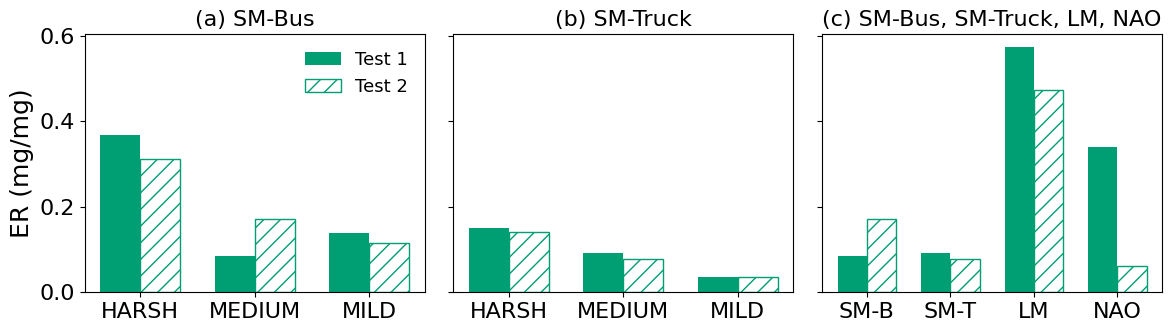

In [117]:
# --- Define the experiments to be plotted in each subplot --- #
groups = {
    "SM-Bus": ["HARSH HDV1", "MEDIUM HDV1", "MILD HDV1"],
    "SM-Truck": ["HARSH HDV2", "MEDIUM HDV2", "MILD HDV2"],
    "Medium Braking": ["MEDIUM HDV1", "MEDIUM HDV2", "MEDIUM LDV1", "MEDIUM LDV2"]
}

# --- Mapping for x-axis labels for subplot C (Medium Braking) --- #
vehicle_map = {"MEDIUM HDV1": "SM-B", "MEDIUM HDV2": "SM-T",
               "MEDIUM LDV1": "LM", "MEDIUM LDV2": "NAO"}

# --- Function to get the emission factor (EF) values for Original and Repeat runs --- #
def get_ef(groups):
    return (
        [df_results.loc[df_results.Experiment == f"{g} - Original", "EF (mg/mg)"].iloc[0] for g in groups],
        [df_results.loc[df_results.Experiment == f"{g} - Repeat",   "EF (mg/mg)"].iloc[0] for g in groups]
    )

# --- Plot setup --- #
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
bar_w, color = 0.35, "#009E73"

# --- Loop through each subplot --- #
for ax, (title, g) in zip(axs, groups.items()):
    ef_o, ef_r = get_ef(g)  # Original and Repeat EF values
    x = np.arange(len(g))    # X-axis positions

    # Plot Original bars (solid)
    ax.bar(x - bar_w/2, ef_o, bar_w, color=color, label="Test 1")
    # Plot Repeat bars (hatched)
    ax.bar(x + bar_w/2, ef_r, bar_w, facecolor="none", edgecolor=color, hatch="//", label="Test 2")

    # Set x-ticks at center
    ax.set_xticks(x)
    # X-tick labels: severity for SM-Bus/SM-Truck, vehicle abbreviations for Medium Braking
    ax.set_xticklabels([vehicle_map[s] if title=="Medium Braking" else s.split()[0] for s in g])

    # --- Titles with (a), (b), (c) --- #
    if title == "SM-Bus":
        ax.set_title("(a) SM-Bus", fontsize=16)
    elif title == "SM-Truck":
        ax.set_title("(b) SM-Truck", fontsize=16)
    else:
        ax.set_title("(c) SM-Bus, SM-Truck, LM, NAO", fontsize=16)

    ax.grid(False)

# Y-axis label
axs[0].set_ylabel("ER (mg/mg)", fontsize=18)

# Legend only once
axs[0].legend(frameon=False, loc="upper right")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

#### **SLIDING EMISSION FACTOR PLOT**

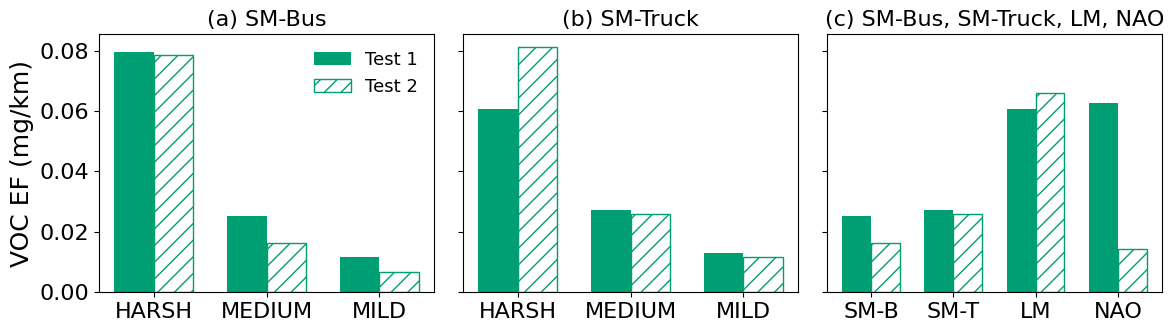

In [118]:
#We plot the laboratory sliding emission factor plots
# --- Define the experiments to be plotted in each subplot --- #
groups = {
    "SM-Bus": ["HARSH HDV1", "MEDIUM HDV1", "MILD HDV1"],
    "SM-Truck": ["HARSH HDV2", "MEDIUM HDV2", "MILD HDV2"],
    "Medium Braking": ["MEDIUM HDV1", "MEDIUM HDV2", "MEDIUM LDV1", "MEDIUM LDV2"]
}

# --- Mapping for x-axis labels for subplot C (Medium Braking) --- #
vehicle_map = {"MEDIUM HDV1": "SM-B", "MEDIUM HDV2": "SM-T",
               "MEDIUM LDV1": "LM", "MEDIUM LDV2": "NAO"}

# --- Function to get the emission factor (EF) values for Original and Repeat runs --- #
def get_ef(groups):
    return (
        [df_results_EF.loc[
            df_results_EF.Experiment == f"{g} - Original",
            "VOC EF (mg/km)"
        ].iloc[0] for g in groups],

        [df_results_EF.loc[
            df_results_EF.Experiment == f"{g} - Repeat",
            "VOC EF (mg/km)"
        ].iloc[0] for g in groups]
    )

# --- Plot setup --- #
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
bar_w, color = 0.35, "#009E73"

# --- Loop through each subplot --- #
for ax, (title, g) in zip(axs, groups.items()):
    ef_o, ef_r = get_ef(g)  # Original and Repeat EF values
    x = np.arange(len(g))    # X-axis positions

    # Plot Original bars (solid)
    ax.bar(x - bar_w/2, ef_o, bar_w, color=color, label="Test 1")

    # Plot Repeat bars (hatched)
    ax.bar(x + bar_w/2, ef_r, bar_w,
           facecolor="none", edgecolor=color,
           hatch="//", label="Test 2")

    # Set x-ticks at center
    ax.set_xticks(x)

    # X-tick labels: severity for SM-Bus/SM-Truck,
    # vehicle abbreviations for Medium Braking
    ax.set_xticklabels([
        vehicle_map[s] if title == "Medium Braking"
        else s.split()[0]
        for s in g
    ])

    # --- Titles with (a), (b), (c) --- #
    if title == "SM-Bus":
        ax.set_title("(a) SM-Bus", fontsize=16)

    elif title == "SM-Truck":
        ax.set_title("(b) SM-Truck", fontsize=16)

    else:
        ax.set_title("(c) SM-Bus, SM-Truck, LM, NAO", fontsize=16)

    ax.grid(False)

# Y-axis label
axs[0].set_ylabel("VOC EF (mg/km)", fontsize=18)

# Legend only once
axs[0].legend(frameon=False, loc="upper right")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.9])

plt.show()

#### **SLIDING ER & EF TO REALISTIC EMISSION FACTOR PLOT**

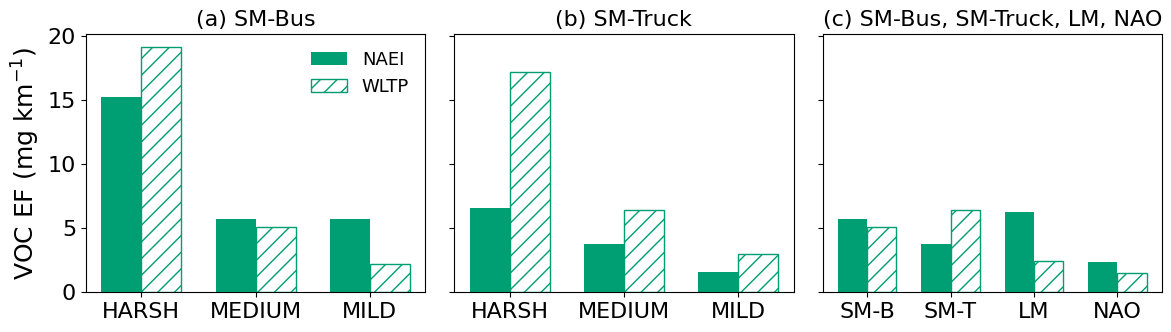

In [119]:
# Here we plot EF following the approach from NAEI and WLTP
# --- Define the experiments to be plotted in each subplot --- #
groups = {
    "SM-Bus": ["HARSH HDV1", "MEDIUM HDV1", "MILD HDV1"],
    "SM-Truck": ["HARSH HDV2", "MEDIUM HDV2", "MILD HDV2"],
    "Medium Braking": ["MEDIUM HDV1", "MEDIUM HDV2", "MEDIUM LDV1", "MEDIUM LDV2"]
}

# --- Mapping for x-axis labels for subplot C --- #
vehicle_map = {
    "MEDIUM HDV1": "SM-B",
    "MEDIUM HDV2": "SM-T",
    "MEDIUM LDV1": "LM",
    "MEDIUM LDV2": "NAO"
}

# --- Function to retrieve average values --- #
def get_av_values(groups):

    naie = []
    wltp = []

    for g in groups:

        # Average NAIE VOC EF (mg/km)
        naie.append(
            df_results.loc[
                df_results["Experiment"].str.startswith(g),
                "av EF (mg/km)"
            ].iloc[0]
        )

        # Average WLTP VOC EF (mg/km)
        wltp.append(
            df_results_EF.loc[
                df_results_EF["Experiment"].str.startswith(g),
                "av VOC EF driving (mg/km)"
            ].iloc[0]
        )

    return naie, wltp


# --- Plot setup --- #
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

bar_w = 0.35
color = "#009E73"

# --- Loop through each subplot --- #
for ax, (title, g) in zip(axs, groups.items()):

    naie, wltp = get_av_values(g)

    x = np.arange(len(g))

    # NAIE bars (solid)
    ax.bar(
        x - bar_w/2,
        naie,
        width=bar_w,
        color=color,
        label="NAEI"
    )

    # WLTP bars (hatched)
    ax.bar(
        x + bar_w/2,
        wltp,
        width=bar_w,
        facecolor="none",
        edgecolor=color,
        hatch="//",
        label="WLTP"
    )

    # X-axis labels
    ax.set_xticks(x)

    if title == "Medium Braking":
        ax.set_xticklabels([vehicle_map[s] for s in g])
    else:
        ax.set_xticklabels([s.split()[0] for s in g])

    # Subplot titles (same as original)
    if title == "SM-Bus":
        ax.set_title("(a) SM-Bus", fontsize=16)

    elif title == "SM-Truck":
        ax.set_title("(b) SM-Truck", fontsize=16)

    else:
        ax.set_title("(c) SM-Bus, SM-Truck, LM, NAO", fontsize=16)

    ax.grid(False)

# --- Y-axis label --- #
axs[0].set_ylabel("VOC EF (mg km$^{-1}$)", fontsize=18)

# --- Legend (only once) --- #
axs[0].legend(
    frameon=False,
    loc="upper right"
)

# --- Layout --- #
plt.tight_layout(rect=[0, 0, 1, 0.9])

plt.show()

# **MASS SPECTRUM**

In [120]:
#VMR_HDV_df

In [121]:
# time ranges
datasets = [

    # MILD HDV1
    {"label": "MILD HDV1 - Original", "voc_zero": "2025-02-24 11:11:00"},
    {"label": "MILD HDV1 - Repeat",   "voc_zero": "2025-02-27 10:19:00"},

    # MILD HDV2
    {"label": "MILD HDV2 - Original", "voc_zero": "2025-02-24 16:52:00"},
    {"label": "MILD HDV2 - Repeat",   "voc_zero": "2025-02-27 16:04:00"},

    # MEDIUM HDV1
    {"label": "MEDIUM HDV1 - Original", "voc_zero": "2025-02-11 11:28:00"},
    {"label": "MEDIUM HDV1 - Repeat",   "voc_zero": "2025-02-19 10:34:00"},
    {"label": "MEDIUM HDV1 - Repeat 2", "voc_zero": "2025-02-06 10:24:00"},  # added new data

    # MEDIUM HDV2
    {"label": "MEDIUM HDV2 - Original", "voc_zero": "2025-02-12 11:06:00"},
    {"label": "MEDIUM HDV2 - Repeat",   "voc_zero": "2025-02-13 11:57:00"},
    {"label": "MEDIUM HDV2 - Repeat 2", "voc_zero": "2025-02-18 10:53:15"},  # New data

    # MEDIUM LDV1
    {"label": "MEDIUM LDV1 - Original", "voc_zero": "2025-03-10 11:46:00"},
    {"label": "MEDIUM LDV1 - Repeat",   "voc_zero": "2025-03-11 10:34:00"},
    # MEDIUM LDV2
    {"label": "MEDIUM LDV2 - Original", "voc_zero": "2025-03-31 10:14:50"},
    {"label": "MEDIUM LDV2 - Repeat",   "voc_zero": "2025-04-01 10:25:05"},

    # HARSH HDV1
    {"label": "HARSH HDV1 - Original", "voc_zero": "2025-02-25 09:42:50"},
    {"label": "HARSH HDV1 - Repeat",   "voc_zero": "2025-03-04 10:06:00"},

    # HARSH HDV2
    {"label": "HARSH HDV2 - Original", "voc_zero": "2025-02-25 15:25:00"},
    {"label": "HARSH HDV2 - Repeat",   "voc_zero": "2025-03-04 16:05:00"},

]


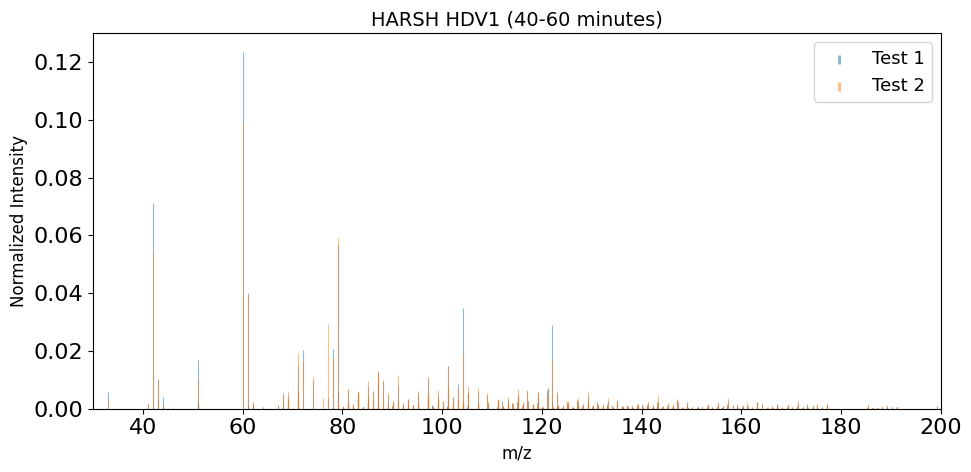

In [122]:

# Atomic weights
aw = {"C":12.011,"H":1.008,"O":15.999,"S":32.06,"N":14.007,"Si":28.085}

def molar_mass(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula.replace('+',''))
    return sum(aw[e]* (int(n) if n else 1) for e,n in tokens if e in aw)

# Helper function to process one experiment
def process_spectrum(voc_zero):
    df = VMR_HDV_df.loc[voc_zero + pd.Timedelta(minutes=40) : voc_zero + pd.Timedelta(minutes=60)]
    compound_cols = [c for c in df.columns if not c.startswith("m/Q")]
    agg = df[compound_cols].sum()
    norm = agg / agg.sum()
    spec = pd.DataFrame({
        "compound": norm.index.str.replace('+',''),
        "norm_intensity": norm.values,
    })
    spec["molar_mass"] = spec["compound"].apply(molar_mass)
    return spec.sort_values("molar_mass")

# HARSH HDV1 - Original
voc_zero_original = pd.to_datetime("2025-02-25 09:42:50")
spec_original = process_spectrum(voc_zero_original)

# HARSH HDV1 - Repeat
voc_zero_repeat = pd.to_datetime("2025-03-04 10:06:00")
spec_repeat = process_spectrum(voc_zero_repeat)

# Plot both spectra with same thin stick format
plt.figure(figsize=(10,5))

# Original in blue
markerline, stemlines, baseline = plt.stem(
    spec_original["molar_mass"], spec_original["norm_intensity"],
    linefmt="C0-", markerfmt=" ", basefmt=" ", label="Test 1"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)

# Repeat in red
markerline, stemlines, baseline = plt.stem(
    spec_repeat["molar_mass"], spec_repeat["norm_intensity"],
    linefmt="C1-", markerfmt=" ", basefmt=" ", label="Test 2"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)

#plt.yscale("log")
plt.xlabel("m/z", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.title("HARSH HDV1 (40-60 minutes)", fontsize=14)
plt.legend()
plt.xlim(30,200)
plt.ylim(0.00)
plt.grid(False)
plt.tight_layout()
plt.show()




## **NORMALISED SIGNAL**

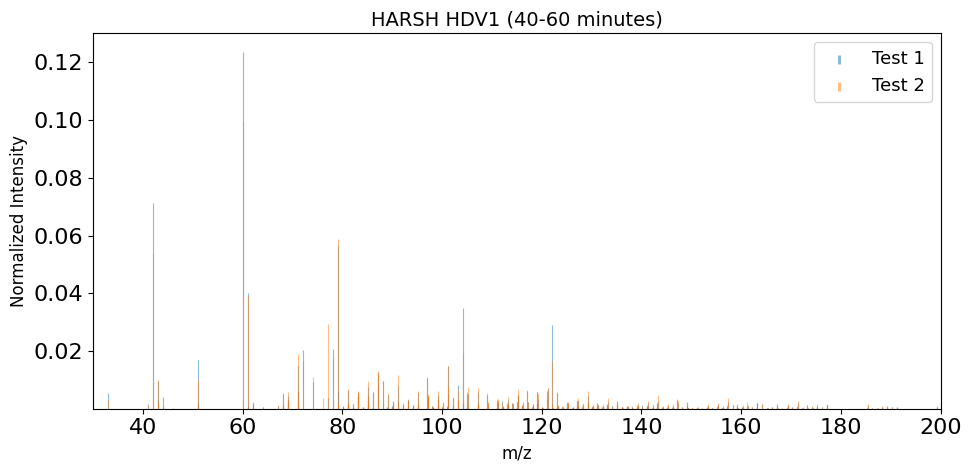

In [123]:
# Atomic weights
aw = {"C":12.011,"H":1.008,"O":15.999,"S":32.06,"N":14.007,"Si":28.085}

def molar_mass(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula.replace('+',''))
    return sum(aw[e]* (int(n) if n else 1) for e,n in tokens if e in aw)

# Helper function to process one experiment
def process_spectrum(voc_zero):
    df = VMR_HDV_df.loc[voc_zero + pd.Timedelta(minutes=40) : voc_zero + pd.Timedelta(minutes=60)]
    compound_cols = [c for c in df.columns if not c.startswith("m/Q")]
    agg = df[compound_cols].sum()
    norm = agg / agg.sum()
    spec = pd.DataFrame({
        "compound": norm.index.str.replace('+',''),
        "norm_intensity": norm.values,
    })
    spec["molar_mass"] = spec["compound"].apply(molar_mass)
    return spec.sort_values("molar_mass")

# HARSH HDV1 - Original
voc_zero_original = pd.to_datetime("2025-02-25 09:42:50")
spec_original = process_spectrum(voc_zero_original)

# HARSH HDV1 - Repeat
voc_zero_repeat = pd.to_datetime("2025-03-04 10:06:00")
spec_repeat = process_spectrum(voc_zero_repeat)

# Plot both spectra with same thin stick format
plt.figure(figsize=(10,5))

# Original in blue
markerline, stemlines, baseline = plt.stem(
    spec_original["molar_mass"], spec_original["norm_intensity"],
    linefmt="C0-", markerfmt=" ", basefmt=" ", label="Test 1"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)

# Repeat in red
markerline, stemlines, baseline = plt.stem(
    spec_repeat["molar_mass"], spec_repeat["norm_intensity"],
    linefmt="C1-", markerfmt=" ", basefmt=" ", label="Test 2"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)
#plt.yscale("log")
plt.xlabel("m/z", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.title("HARSH HDV1 (40-60 minutes)", fontsize=14)
plt.legend()
plt.xlim(30,200)
plt.ylim(bottom=0.0001)
plt.grid(False)
plt.tight_layout()
plt.show()




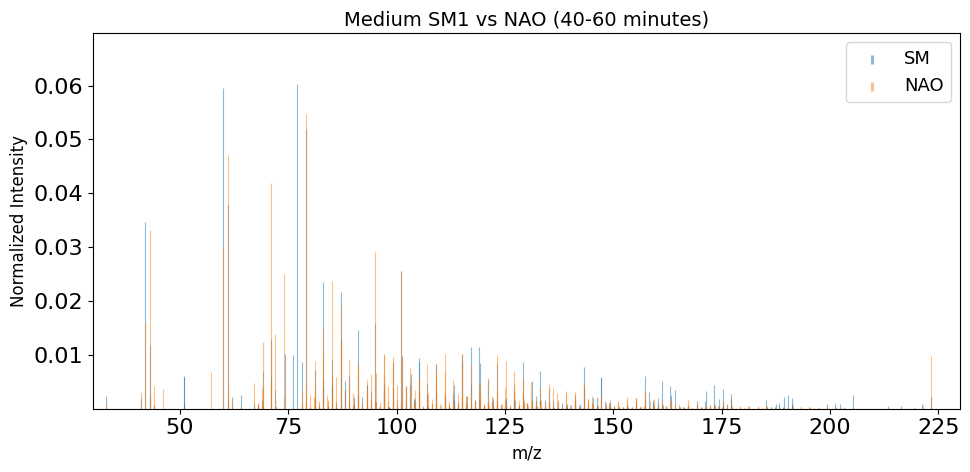

In [124]:
#NAO VS LM
# Atomic weights
aw = {"C":12.011,"H":1.008,"O":15.999,"S":32.06,"N":14.007,"Si":28.085}

def molar_mass(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula.replace('+',''))
    return sum(aw[e]* (int(n) if n else 1) for e,n in tokens if e in aw)

# Helper function to process one experiment
def process_spectrum(voc_zero):
    df = VMR_HDV_df.loc[voc_zero + pd.Timedelta(minutes=40) : voc_zero + pd.Timedelta(minutes=60)]
    compound_cols = [c for c in df.columns if not c.startswith("m/Q")]
    agg = df[compound_cols].sum()
    norm = agg / agg.sum()
    spec = pd.DataFrame({
        "compound": norm.index.str.replace('+',''),
        "norm_intensity": norm.values,
    })
    spec["molar_mass"] = spec["compound"].apply(molar_mass)
    return spec.sort_values("molar_mass")

# MEDIUM HDV1 (SM) - Original
voc_zero_original = pd.to_datetime("2025-02-11 11:28:00")
spec_original = process_spectrum(voc_zero_original)

# MEDIUM LDV LDV2 (NAO) - Original
voc_zero_repeat = pd.to_datetime("2025-03-31 10:14:50")
spec_repeat = process_spectrum(voc_zero_repeat)

# Plot both spectra with same thin stick format
plt.figure(figsize=(10,5))

# Original in blue
markerline, stemlines, baseline = plt.stem(
    spec_original["molar_mass"], spec_original["norm_intensity"],
    linefmt="C0-", markerfmt=" ", basefmt=" ", label="SM"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)

# Repeat in red
markerline, stemlines, baseline = plt.stem(
    spec_repeat["molar_mass"], spec_repeat["norm_intensity"],
    linefmt="C1-", markerfmt=" ", basefmt=" ", label="NAO"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)
#plt.yscale("log")
plt.xlabel("m/z", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.title("Medium SM1 vs NAO (40-60 minutes)", fontsize=14)
plt.legend()
plt.xlim(30,230)
plt.ylim(bottom=0.0001)
plt.grid(False)
plt.tight_layout()
plt.show()




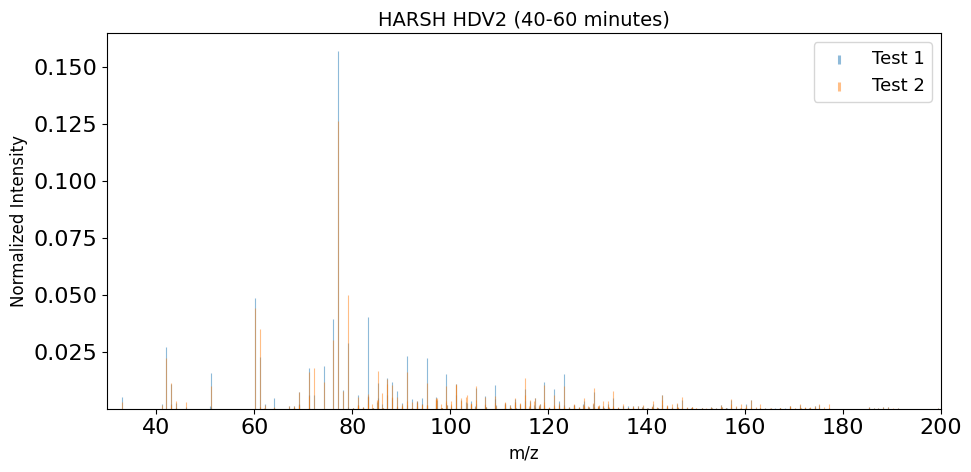

In [125]:
# Atomic weights
aw = {"C":12.011,"H":1.008,"O":15.999,"S":32.06,"N":14.007,"Si":28.085}

def molar_mass(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula.replace('+',''))
    return sum(aw[e]* (int(n) if n else 1) for e,n in tokens if e in aw)

# Helper function to process one experiment
def process_spectrum(voc_zero):
    df = VMR_HDV_df.loc[voc_zero + pd.Timedelta(minutes=1) : voc_zero + pd.Timedelta(minutes=20)]
    compound_cols = [c for c in df.columns if not c.startswith("m/Q")]
    agg = df[compound_cols].sum()
    norm = agg / agg.sum()
    spec = pd.DataFrame({
        "compound": norm.index.str.replace('+',''),
        "norm_intensity": norm.values,
    })
    spec["molar_mass"] = spec["compound"].apply(molar_mass)
    return spec.sort_values("molar_mass")

# HARSH HDV1 - Original
voc_zero_original = pd.to_datetime("2025-02-25 15:25:00")
spec_original = process_spectrum(voc_zero_original)

# HARSH HDV1 - Repeat
voc_zero_repeat = pd.to_datetime("2025-03-04 16:05:00")
spec_repeat = process_spectrum(voc_zero_repeat)

# Plot both spectra with same thin stick format
plt.figure(figsize=(10,5))

# Original in blue
markerline, stemlines, baseline = plt.stem(
    spec_original["molar_mass"], spec_original["norm_intensity"],
    linefmt="C0-", markerfmt=" ", basefmt=" ", label="Test 1"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)

# Repeat in red
markerline, stemlines, baseline = plt.stem(
    spec_repeat["molar_mass"], spec_repeat["norm_intensity"],
    linefmt="C1-", markerfmt=" ", basefmt=" ", label="Test 2"
)
plt.setp(stemlines, linewidth=0.8, alpha=0.5)
#plt.yscale("log")
plt.xlabel("m/z", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.title("HARSH HDV2 (40-60 minutes)", fontsize=14)
plt.legend()
plt.xlim(30,200)
plt.ylim(bottom=0.0001)
plt.grid(False)
plt.tight_layout()
plt.show()


# **PEAK LIST**

In [126]:
# Define the VOC zero times used to identify the 40–60 min braking window.

datasets_peaklist = [
    {"vehicle": "HDV1", "label": "Medium", "voc_zero": "2025-02-11 11:28:00"},
    {"vehicle": "HDV2", "label": "Medium", "voc_zero": "2025-02-12 11:06:00"},
    {"vehicle": "LDV2", "label": "Medium", "voc_zero": "2025-03-31 10:14:50"},
    {"vehicle": "LDV1", "label": "Medium", "voc_zero": "2025-03-10 11:46:00"}
]

VMR_mg.index = pd.to_datetime(VMR_mg.index)

In [127]:
# Identify the top 200 compounds and calculate their mean signal
# during the 40–60 min braking period for the selected vehicles.

def build_peak_table(vehicles, dropna="all"):
    datasets = [
        d for d in datasets_peaklist
        if d["vehicle"] in vehicles
    ]

    top_compounds = set()

    for dataset in datasets:
        voc_zero = pd.to_datetime(dataset["voc_zero"])

        signal = VMR_mg.loc[
            voc_zero + pd.Timedelta(minutes=40):
            voc_zero + pd.Timedelta(minutes=60)
        ]

        signal = signal.where(signal >= 0)
        top_compounds.update(
            signal.mean().sort_values(ascending=False).head(200).index
        )

    table = pd.DataFrame(index=sorted(top_compounds))

    for dataset in datasets:
        vehicle = dataset["vehicle"]
        voc_zero = pd.to_datetime(dataset["voc_zero"])

        signal = VMR_mg.loc[
            voc_zero + pd.Timedelta(minutes=40):
            voc_zero + pd.Timedelta(minutes=60)
        ]

        signal = signal.where(signal >= 0)
        signal = signal[
            table.index.intersection(signal.columns)
        ]

        table[vehicle] = signal.mean()

    # Ensure both vehicle columns are present
    for vehicle in vehicles:
        if vehicle not in table.columns:
            table[vehicle] = pd.NA

    # Remove compounds according to the selected rule
    table = table.dropna(how=dropna)

    # Sort by the first vehicle
    table = table.sort_values(vehicles[0], ascending=False)

    return table.reset_index().rename(columns={"index": "Compound"})

In [128]:
# Create the HDV and LDV peak lists and calculate protonated formulas and m/z.

hdv = build_peak_table(["HDV1", "HDV2"], dropna="all")
ldv = build_peak_table(["LDV1", "LDV2"], dropna="any")

atomic_masses = {
    "C": 12.0000,
    "H": 1.007825,
    "O": 15.994915,
    "N": 14.003074,
    "S": 31.972071,
    "Si": 27.976927
}

PROTON_MASS = 1.007276  # H+

def compute_neutral_mass(formula):
    mass = 0.0

    for element, count in re.findall(r'([A-Z][a-z]?)(\d*)', str(formula)):
        if element not in atomic_masses:
            return None

        count = int(count) if count else 1
        mass += atomic_masses[element] * count

    return mass

def protonated_display(formula):
    return r"\ce{" + str(formula) + "H+}"

def add_mass_columns(table):
    table["Protonated"] = table["Compound"].apply(protonated_display)
    table["m/z"] = (
        table["Compound"].apply(compute_neutral_mass) + PROTON_MASS
    )

    table[["m/z"] + [c for c in table.columns if c in ["HDV1", "HDV2", "LDV1", "LDV2"]]] = \
        table[["m/z"] + [c for c in table.columns if c in ["HDV1", "HDV2", "LDV1", "LDV2"]]].round(4)

    return table.drop(columns=["Compound"])

hdv = add_mass_columns(hdv)
ldv = add_mass_columns(ldv)

# Rename LDV columns before combining
ldv = ldv.rename(columns={
    "Protonated": "Protonated_LDV",
    "m/z": "m/z_LDV"
})

In [129]:
# Combine HDV and LDV peak lists row-by-row to create the final table.

hdv = hdv.reset_index(drop=True)
ldv = ldv.reset_index(drop=True)

combined = pd.concat([hdv, ldv], axis=1)

display(combined)

# Export LaTeX table
latex_table = combined.to_latex(
    index=False,
    escape=False,
    float_format="%.4f"
)

with open("combined.tex", "w") as f:
    f.write(latex_table)

,HDV1,HDV2,Protonated,m/z,LDV2,LDV1,Protonated_LDV,m/z_LDV
0,0.0016,0.0011,\ce{C3H8O2H+},77.0597,0.0034,0.0048,\ce{C2H6O3H+},79.0390
1,0.0014,0.0008,\ce{C5H4NH+},79.0416,0.0023,0.0024,\ce{C2H4O2H+},61.0284
2,0.0012,0.0021,\ce{C2H5NOH+},60.0444,0.0014,0.0020,\ce{C2H5NOH+},60.0444
3,0.0009,0.0008,\ce{C5H8O2H+},101.0597,0.0021,0.0018,\ce{C3H6N3OH+},101.0584
4,0.0008,0.0005,\ce{C2H4O2H+},61.0284,0.0013,0.0015,\ce{C2H4N3OH+},87.0427
...,...,...,...,...,...,...,...,...
215,0.0000,0.0001,\ce{C6H9NO2H+},128.0706,NaN,NaN,NaN,NaN
216,0.0000,0.0001,\ce{C2H7N3OSH+},122.0383,NaN,NaN,NaN,NaN
217,0.0000,0.0001,\ce{C11H18OH+},167.1430,NaN,NaN,NaN,NaN
218,0.0000,0.0001,\ce{C6H7NH+},94.0651,NaN,NaN,NaN,NaN
